In [1]:
from pathlib import Path 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt


In [2]:
import sys

print("Python:")
print(sys.version)

print("\nExe?:")
print(sys.executable)

print("\nLibrerias:")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

Python:
3.13.9 (tags/v3.13.9:8183fa5, Oct 14 2025, 14:09:13) [MSC v.1944 64 bit (AMD64)]

Exe?:
c:\Users\JoLui\AppData\Local\Programs\Python\Python313\python.exe

Librerias:
NumPy: 2.3.5
Pandas: 3.0.3


In [6]:
# Busqueda de Vuelos en la carpeta RAW Data
DATA_PATH = Path("../Data/Raw Data")

files = sorted(DATA_PATH.glob("*.csv"))

print(f"Archivos : {len(files)}")

for file in files:
    print(file.name)

Archivos : 63
10_standardized.csv
11_standardized.csv
12_standardized.csv
13_standardized.csv
14_standardized.csv
15_standardized.csv
16_standardized.csv
17_standardized.csv
18_standardized.csv
19_standardized.csv
1_standardized.csv
20_standardized.csv
21_standardized.csv
22_standardized.csv
23_standardized.csv
24_standardized.csv
25_standardized.csv
26_standardized.csv
27_standardized.csv
28_standardized.csv
29_standardized.csv
2_standardized.csv
30_standardized.csv
31_standardized.csv
32_standardized.csv
33_standardized.csv
34_standardized.csv
35_standardized.csv
36_standardized.csv
37_standardized.csv
38_standardized.csv
39_standardized.csv
3_standardized.csv
4_standardized.csv
5_standardized.csv
6_standardized.csv
7_standardized.csv
8_standardized.csv
9_standardized.csv
altus1_standardized.csv
altus2_standardized.csv
altus3_standardized.csv
altus4_standardized.csv
altus5_standardized.csv
altus6_standardized.csv
altus7_standardized.csv
custom1_standardized.csv
custom2_standardized.c

In [7]:
#Validación de los esquemas/estructuras de los archivos de vuelos
schemas = {}

for file in files:
    df_temp = pd.read_csv(file)
    schemas[file.name] = list(df_temp.columns)
unique_schemas = set(tuple(columns) for columns in schemas.values())

print(f"Numero de estructuras diferentes: {len(unique_schemas)}")

Numero de estructuras diferentes: 2


In [8]:
#Identificacion del numero de columnas de cada  vuelo 
for i, schema in enumerate(unique_schemas, start=1):
    print(f"\nEstructura {i}:")
    for column in schema:
        print("  -", column)


Estructura 1:
  - t
  - h
  - P
  - T
  - ρ
  - a
  - Vx
  - Ax
  - Ay
  - Az
  - At

Estructura 2:
  - time
  - baro_altitude
  - accl_x
  - accl_y
  - accl_z
  - gps_altitude
  - gyro_roll
  - gyro_pitch
  - gyro_yaw


In [9]:
#Identificacion de los archivos que pertenecen a cada estructura
structure_1_files = []
structure_2_files = []

for file in files:

    df_temp = pd.read_csv(file)

    columns = set(df_temp.columns)

    if {
        "t", "h", "P", "T", "ρ",
        "a", "Vx", "Ax", "Ay", "Az", "At"
    }.issubset(columns):

        structure_1_files.append(file)

    elif {
        "time", "baro_altitude",
        "accl_x", "accl_y", "accl_z",
        "gps_altitude",
        "gyro_roll", "gyro_pitch", "gyro_yaw"
    }.issubset(columns):

        structure_2_files.append(file)


print("Estructura 1:", len(structure_1_files))
print("Estructura 2:", len(structure_2_files))

Estructura 1: 1
Estructura 2: 62


In [11]:
print("\n ESTRUCTURA 1")

for file in structure_1_files:
    print(file.name)


print("\nESTRUCTURA 2 ")

for file in structure_2_files:
    print(file.name)


 ESTRUCTURA 1
FlightReport2-limpios.xlsx - Hoja 1.csv

ESTRUCTURA 2 
10_standardized.csv
11_standardized.csv
12_standardized.csv
13_standardized.csv
14_standardized.csv
15_standardized.csv
16_standardized.csv
17_standardized.csv
18_standardized.csv
19_standardized.csv
1_standardized.csv
20_standardized.csv
21_standardized.csv
22_standardized.csv
23_standardized.csv
24_standardized.csv
25_standardized.csv
26_standardized.csv
27_standardized.csv
28_standardized.csv
29_standardized.csv
2_standardized.csv
30_standardized.csv
31_standardized.csv
32_standardized.csv
33_standardized.csv
34_standardized.csv
35_standardized.csv
36_standardized.csv
37_standardized.csv
38_standardized.csv
39_standardized.csv
3_standardized.csv
4_standardized.csv
5_standardized.csv
6_standardized.csv
7_standardized.csv
8_standardized.csv
9_standardized.csv
altus1_standardized.csv
altus2_standardized.csv
altus3_standardized.csv
altus4_standardized.csv
altus5_standardized.csv
altus6_standardized.csv
altus7_standard

In [13]:
# Analizar vuelo de la estructura 2

test_file = DATA_PATH / "1_standardized.csv"

df_test = pd.read_csv(test_file)

print(df_test.shape)
print(df_test.columns.tolist())

display(df_test.head())
df_test.describe()
print(df_test.isna().sum())

(2506, 9)
['time', 'baro_altitude', 'accl_x', 'accl_y', 'accl_z', 'gps_altitude', 'gyro_roll', 'gyro_pitch', 'gyro_yaw']


,time,baro_altitude,accl_x,accl_y,accl_z,gps_altitude,gyro_roll,gyro_pitch,gyro_yaw
0,0.00,0.000000,-9.108643,-1.843430,1.533449,0.0,0.0,0.0,0.0
1,0.02,-0.094183,-9.108643,-1.843430,1.380134,0.0,0.0,0.0,0.0
2,0.04,-0.257556,-9.162898,-1.680667,1.456944,0.0,0.0,0.0,0.0
3,0.06,-0.192634,-9.108643,-1.734922,1.380134,0.0,0.0,0.0,0.0
4,0.08,-0.126797,-9.108643,-1.734922,1.380134,0.0,0.0,0.0,0.0


time             0
baro_altitude    0
accl_x           0
accl_y           0
accl_z           0
gps_altitude     0
gyro_roll        0
gyro_pitch       0
gyro_yaw         0
dtype: int64


In [14]:
df_test[[
    "accl_x",
    "accl_y",
    "accl_z"
]].describe()


,accl_x,accl_y,accl_z
count,2506.000000,2506.000000,2506.000000
mean,-9.103184,-1.610230,-1.610445
std,13.705120,7.591484,12.300033
min,-222.078194,-138.365179,-157.032960
25%,-11.440058,-3.524098,-2.913583
50%,-9.108643,-2.277161,-0.996696
75%,-5.205070,-0.270967,0.690067
max,206.626054,118.304462,156.956150


In [15]:
#Primeros 20 vuelos con Estructura 2
print("primeras 20 mediciones:")
display(
    df_test[
        [
            "time",
            "baro_altitude",
            "accl_x",
            "accl_y",
            "accl_z"
        ]
    ].head(20)
)

primeras 20 mediciones:


,time,baro_altitude,accl_x,accl_y,accl_z
0,0.00,0.000000,-9.108643,-1.843430,1.533449
1,0.02,-0.094183,-9.108643,-1.843430,1.380134
2,0.04,-0.257556,-9.162898,-1.680667,1.456944
3,0.06,-0.192634,-9.108643,-1.734922,1.380134
4,0.08,-0.126797,-9.108643,-1.734922,1.380134
5,0.10,-0.191719,-9.162898,-1.680667,1.380134
6,0.12,-0.216103,-9.108643,-1.843430,1.380134
7,0.14,-0.110338,-9.108643,-1.843430,1.533449
8,0.16,-0.170383,-9.108643,-1.843430,1.456944
9,0.18,-0.106985,-9.000134,-1.843430,1.456944


In [16]:
#Determinacion de la frecuencia de muestreo
dt = df_test["time"].diff()

print("Δt promedio:", dt.mean())
print("Δt desviación estándar:", dt.std())
print("Frecuencia aproximada:", 1 / dt.mean(), "Hz")

Δt promedio: 0.020000399201596807
Δt desviación estándar: 1.9980029950103258e-05
Frecuencia aproximada: 49.99900201592782 Hz


In [17]:
#Sampling de los vuelos 
sampling_summary = []

for file in structure_2_files:

    df = pd.read_csv(file)

    dt = df["time"].diff()

    dt_mean = dt.mean()
    dt_std = dt.std()

    sampling_summary.append({
        "flight": file.stem,
        "samples": len(df),
        "duration_s": df["time"].iloc[-1] - df["time"].iloc[0],
        "dt_mean": dt_mean,
        "dt_std": dt_std,
        "frequency_hz": 1 / dt_mean,
        "missing_values": df.isna().sum().sum()
    })

sampling_summary = pd.DataFrame(sampling_summary)

sampling_summary

,flight,samples,duration_s,dt_mean,dt_std,frequency_hz,missing_values
0,10_standardized,3229,64.561,0.020000,1.760083e-05,49.999226,0
1,11_standardized,816,16.300,0.020000,8.055274e-16,50.000000,0
2,12_standardized,2568,51.341,0.020000,1.973727e-05,49.999026,0
3,13_standardized,2988,59.741,0.020000,1.829711e-05,49.999163,0
4,14_standardized,3742,74.820,0.020000,2.312486e-05,50.000000,0
...,...,...,...,...,...,...,...
57,flightsketch7_standardized,3543,70.841,0.020000,1.680257e-05,49.999294,0
58,flightsketch8_standardized,2506,50.101,0.020000,1.998003e-05,49.999002,0
59,LAD4_standardized,637,63.400,0.099686,7.930516e-03,10.031546,0
60,LAD5_standardized,59,5.800,0.100000,2.694642e-16,10.000000,0


In [ ]:
#Resumen del sampling hecho previamente
sampling_summary["frequency_hz"].describe()


count    62.000000
mean     42.971097
std      13.468115
min      10.000000
25%      49.999002
50%      49.999167
75%      50.000844
max      50.003365
Name: frequency_hz, dtype: float64

In [22]:
sampling_summary[
    [
        "flight",
        "samples",
        "duration_s",
        "frequency_hz",
        "missing_values"
    ]
]

,flight,samples,duration_s,frequency_hz,missing_values
0,10_standardized,3229,64.561,49.999226,0
1,11_standardized,816,16.300,50.000000,0
2,12_standardized,2568,51.341,49.999026,0
3,13_standardized,2988,59.741,49.999163,0
4,14_standardized,3742,74.820,50.000000,0
...,...,...,...,...,...
57,flightsketch7_standardized,3543,70.841,49.999294,0
58,flightsketch8_standardized,2506,50.101,49.999002,0
59,LAD4_standardized,637,63.400,10.031546,0
60,LAD5_standardized,59,5.800,10.000000,0


In [23]:
flight1 = pd.read_csv(
    DATA_PATH / "FlightReport2-limpios.xlsx - Hoja 1.csv"
)

print(flight1.shape)

display(flight1.head())

display(flight1.describe())

(704, 11)


,t,h,P,T,ρ,a,Vx,Ax,Ay,Az,At
0,0.00,6.1,100.869,14.960,1.224,340.27,0.112,1.615,9.013,0.000,9.156
1,0.05,7.0,100.860,14.955,1.224,340.27,4.142,7.068,46.620,-4.901,47.407
2,0.10,8.2,100.850,14.947,1.224,340.26,9.801,6.279,196.642,-7.943,196.902
3,0.15,9.8,100.832,14.936,1.224,340.25,16.441,5.095,185.921,-3.028,186.016
4,0.20,11.6,100.801,14.925,1.224,340.25,22.310,5.303,186.510,0.675,186.586


,t,h,P,T,ρ,a,Vx,Ax,Ay,Az,At
count,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.00000
mean,17.575000,213.401037,98.413784,13.612896,1.200187,339.471747,18.730544,7.304710,4.036803,0.497161,14.21148
std,10.168579,126.263368,1.473772,0.820690,0.014631,0.485547,23.095966,9.203261,23.895606,7.508240,24.07951
min,0.000000,2.100000,96.312000,12.456000,1.180000,338.790000,0.007000,0.022000,-82.613000,-72.625000,0.53100
25%,8.787500,102.175000,97.078250,12.845000,1.186000,339.020000,8.130000,1.571000,-2.555000,-2.203000,5.47025
50%,17.575000,218.050000,98.367500,13.583000,1.200000,339.455000,8.157000,5.249000,-0.036000,0.122000,9.41400
75%,26.362500,331.600000,99.703500,14.335500,1.213000,339.900000,8.246500,9.457500,4.730750,3.433500,14.24825
max,35.150000,391.400000,100.869000,14.986000,1.225000,340.280000,99.541000,93.865000,196.642000,70.056000,196.90200


In [24]:
print(flight1.isna().sum())

t     0
h     0
P     0
T     0
ρ     0
a     0
Vx    0
Ax    0
Ay    0
Az    0
At    0
dtype: int64


In [25]:
flight1[
    ["t", "h", "P", "T", "ρ", "a",
     "Vx", "Ax", "Ay", "Az", "At"]
].head(20)

,t,h,P,T,ρ,a,Vx,Ax,Ay,Az,At
0,0.00,6.1,100.869,14.960,1.224,340.27,0.112,1.615,9.013,0.000,9.156
1,0.05,7.0,100.860,14.955,1.224,340.27,4.142,7.068,46.620,-4.901,47.407
2,0.10,8.2,100.850,14.947,1.224,340.26,9.801,6.279,196.642,-7.943,196.902
3,0.15,9.8,100.832,14.936,1.224,340.25,16.441,5.095,185.921,-3.028,186.016
4,0.20,11.6,100.801,14.925,1.224,340.25,22.310,5.303,186.510,0.675,186.586
5,0.25,13.7,100.784,14.911,1.223,340.24,27.104,5.052,192.566,1.629,192.639
6,0.30,15.2,100.751,14.901,1.223,340.23,33.188,6.207,189.674,0.316,189.776
7,0.35,17.1,100.729,14.889,1.223,340.23,39.170,5.166,184.902,-0.100,184.974
8,0.40,18.9,100.695,14.877,1.223,340.22,45.613,4.707,180.618,3.846,180.721
9,0.45,21.3,100.640,14.862,1.222,340.21,49.829,5.748,180.855,3.581,180.982


In [31]:
#Prueba para estandarización de vuelos a 20 Hz (Uso del vuelo 10_standardized.csv)
import pandas as pd
from pathlib import Path

DATA_PATH = Path("C:\\TensorFlow\\RocketNeuralNetworkFlightComputer\\Data\\Raw Data") 

file_test = DATA_PATH / "10_standardized.csv"

df_50 = pd.read_csv(file_test)

print("Dimensiones:", df_50.shape)
print("\nColumnas:")
print(df_50.columns.tolist())

print("\nPrimeras filas:")
display(df_50.head())

print("\nInformación:")
print(df_50.info())

Dimensiones: (3229, 9)

Columnas:
['time', 'baro_altitude', 'accl_x', 'accl_y', 'accl_z', 'gps_altitude', 'gyro_roll', 'gyro_pitch', 'gyro_yaw']

Primeras filas:


,time,baro_altitude,accl_x,accl_y,accl_z,gps_altitude,gyro_roll,gyro_pitch,gyro_yaw
0,0.00,0.000000,-9.433865,-0.433730,-0.920191,0.0,0.0,0.0,0.0
1,0.02,-0.022555,-9.433865,-0.217018,-0.996696,0.0,0.0,0.0,0.0
2,0.04,-0.066751,-9.325661,-0.325222,-0.920191,0.0,0.0,0.0,0.0
3,0.06,-0.089306,-9.488119,-0.379476,-0.920191,0.0,0.0,0.0,0.0
4,0.08,-0.109423,-9.433865,-0.325222,-0.996696,0.0,0.0,0.0,0.0



Información:
<class 'pandas.DataFrame'>
RangeIndex: 3229 entries, 0 to 3228
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time           3229 non-null   float64
 1   baro_altitude  3229 non-null   float64
 2   accl_x         3229 non-null   float64
 3   accl_y         3229 non-null   float64
 4   accl_z         3229 non-null   float64
 5   gps_altitude   3229 non-null   float64
 6   gyro_roll      3229 non-null   float64
 7   gyro_pitch     3229 non-null   float64
 8   gyro_yaw       3229 non-null   float64
dtypes: float64(9)
memory usage: 227.2 KB
None


In [32]:
#Determinación de la frecuencia de muestreo del vuelo 10_standardized.csv
dt = df_50["time"].diff()

print("Δt promedio:", dt.mean())
print("Δt desviación estándar:", dt.std())
print("Frecuencia:", 1 / dt.mean(), "Hz")

Δt promedio: 0.020000309789343244
Δt desviación estándar: 1.7600833595233118e-05
Frecuencia: 49.99922553863788 Hz


In [33]:
#Muestreo de las unidades de vuelo 10_standardized.csv
display(df_50.describe())

,time,baro_altitude,accl_x,accl_y,accl_z,gps_altitude,gyro_roll,gyro_pitch,gyro_yaw
count,3229.000000,3229.000000,3229.000000,3229.000000,3229.000000,3229.0,3229.0,3229.0,3229.0
mean,32.280453,109.597254,-9.278722,-2.139995,-1.731119,0.0,0.0,0.0,0.0
std,18.645956,73.517353,18.287787,5.701416,8.581143,0.0,0.0,0.0,0.0
min,0.000000,-1.055827,-183.854141,-77.206754,-157.032960,0.0,0.0,0.0,0.0
25%,16.140000,42.013327,-10.409834,-3.741115,-2.837078,0.0,0.0,0.0,0.0
50%,32.280000,112.673282,-9.271406,-2.873654,-1.456944,0.0,0.0,0.0,0.0
75%,48.421000,174.931426,-7.698943,-1.301191,-0.459943,0.0,0.0,0.0,0.0
max,64.561000,227.375618,221.969686,103.557019,156.956150,0.0,0.0,0.0,0.0


In [34]:
# Verificación de la  existencia y versión de SciPy
import scipy

print("SciPy:", scipy.__version__)

SciPy: 1.18.0


In [64]:
#Normalizacion a 20 HZ ,utilizando la libreria SCipy se realiza el filtrado necesario antes de reducir la frecuencia.
import numpy as np
import pandas as pd
from scipy.signal import resample_poly

# RESAMPLING: 50 Hz -> 20 Hz
FS_ORIGINAL = 50
FS_TARGET = 20
# continua mediante resample_poly
TIME_COLUMN = "time"

# Copia del dataframe original
df_20 = pd.DataFrame()

# Número de muestras objetivo
n_original = len(df_50)

n_target = int(np.ceil(n_original * FS_TARGET / FS_ORIGINAL))

print("Muestras originales:", n_original)
print("Muestras esperadas a 20 Hz:", n_target)
# Nueva base temporal
df_20["time"] = np.arange(n_target) / FS_TARGET
# Resampling de las demás variables
signal_columns = [
    "baro_altitude",
    "accl_x",
    "accl_y",
    "accl_z",
    "gps_altitude",
    "gyro_roll",
    "gyro_pitch",
    "gyro_yaw"
]

for column in signal_columns:

    signal = df_50[column].to_numpy()

    resampled = resample_poly(
        signal,
        up=2,
        down=5
    )

    # Ajustar longitud por seguridad
    resampled = resampled[:n_target]

    df_20[column] = resampled

for column in accel_columns:
    df_20_ms2[column] = df_20_ms2[column] * G_TO_MS2
print("\nNuevo dataframe:")
print(df_20.shape)

display(df_20.head(10))

Muestras originales: 3229
Muestras esperadas a 20 Hz: 1292

Nuevo dataframe:
(1292, 9)


,time,baro_altitude,accl_x,accl_y,accl_z,gps_altitude,gyro_roll,gyro_pitch,gyro_yaw
0,0.00,-0.003769,-6.598550,-0.241220,-0.666238,0.0,0.0,0.0,0.0
1,0.05,-0.076606,-10.105013,-0.338132,-1.011596,0.0,0.0,0.0,0.0
2,0.10,-0.126135,-9.109881,-0.345419,-0.896149,0.0,0.0,0.0,0.0
3,0.15,-0.217442,-9.636053,-0.282976,-0.891976,0.0,0.0,0.0,0.0
4,0.20,-0.327506,-9.274306,-0.312216,-0.898237,0.0,0.0,0.0,0.0
5,0.25,-0.164664,-9.528001,-0.410902,-0.894256,0.0,0.0,0.0,0.0
6,0.30,-0.158496,-9.306838,-0.397669,-0.907953,0.0,0.0,0.0,0.0
7,0.35,-0.192128,-9.405325,-0.329770,-0.947291,0.0,0.0,0.0,0.0
8,0.40,0.012741,-9.380326,-0.348000,-0.910116,0.0,0.0,0.0,0.0
9,0.45,0.092102,-9.378948,-0.314379,-0.924028,0.0,0.0,0.0,0.0


In [68]:
dt_20 = df_20["time"].diff()

print("Δt promedio:", dt_20.mean())
print("Δt desviación estándar:", dt_20.std())
print("Frecuencia:", 1 / dt_20.mean(), "Hz")

df_20_ms2 = df_20.copy()

Δt promedio: 0.049999999999999996
Δt desviación estándar: 2.6215560279575534e-15
Frecuencia: 20.0 Hz


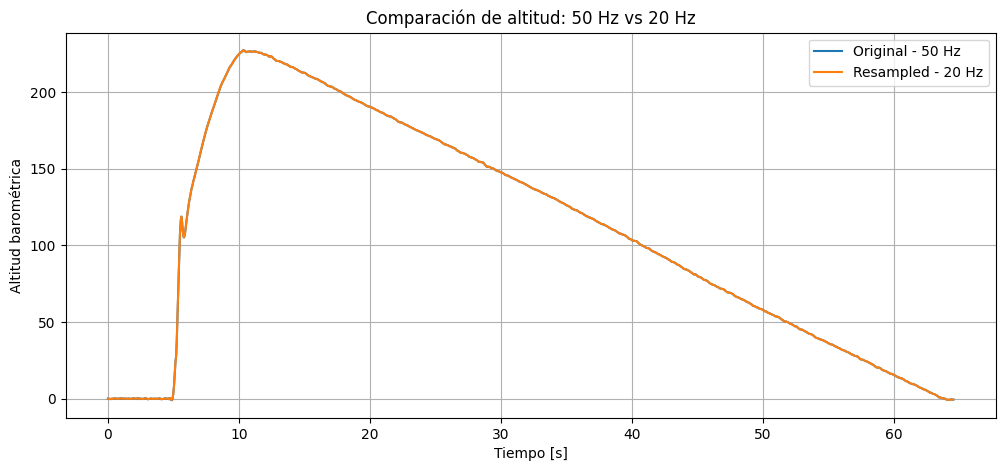

In [52]:
#Ahora,antes de continuar a hacer la normalización de los demás vuelos, haremos una representacion grafica de las variables de interes para ver si el filtrado y el resampling se hicieron correctamente.
#Comoaración de la altitud barométrica entre el vuelo original a 50 Hz y el vuelo resampleado a 20 Hz
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    df_50["time"],
    df_50["baro_altitude"],
    label="Original - 50 Hz"
)

plt.plot(
    df_20["time"],
    df_20["baro_altitude"],
    label="Resampled - 20 Hz"
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Altitud barométrica")
plt.title("Comparación de altitud: 50 Hz vs 20 Hz")
plt.legend()
plt.grid(True)

plt.show()

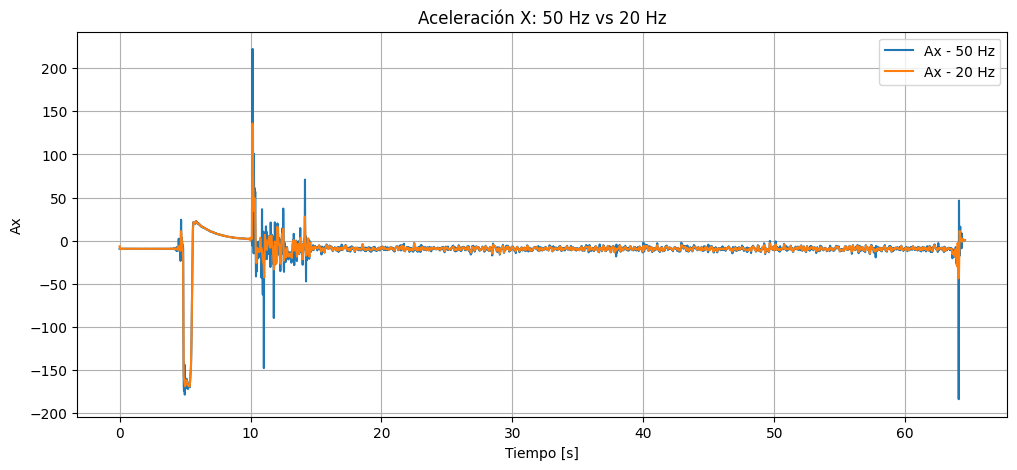

In [53]:
#Comparación de la aceleración en el eje X entre el vuelo original a 50 Hz y el vuelo resampleado a 20 Hz
plt.figure(figsize=(12, 5))

plt.plot(
    df_50["time"],
    df_50["accl_x"],
    label="Ax - 50 Hz"
)

plt.plot(
    df_20["time"],
    df_20["accl_x"],
    label="Ax - 20 Hz"
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Ax")
plt.title("Aceleración X: 50 Hz vs 20 Hz")
plt.legend()
plt.grid(True)

plt.show()

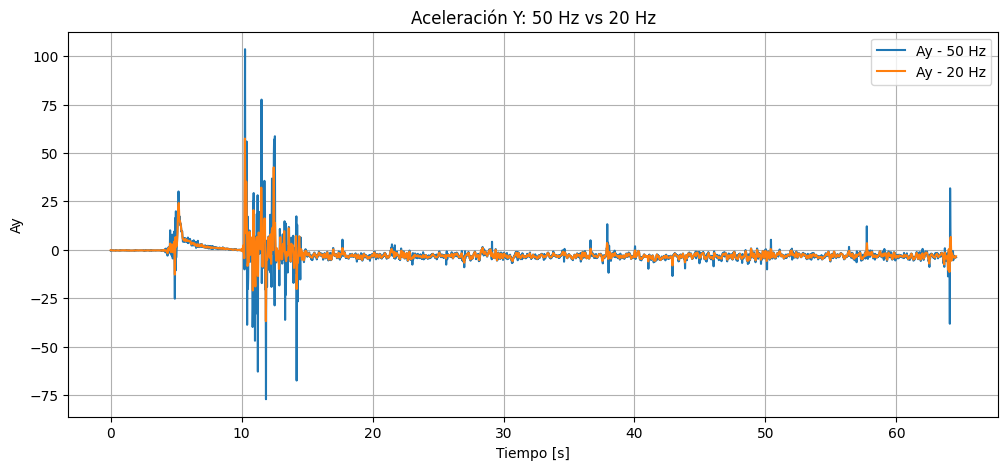

In [54]:
#comparación de la aceleración en el eje Y  entre el vuelo original a 50 Hz y el vuelo resampleado a 20 Hz
plt.figure(figsize=(12, 5))

plt.plot(
    df_50["time"],
    df_50["accl_y"],
    label="Ay - 50 Hz"
)

plt.plot(
    df_20["time"],
    df_20["accl_y"],
    label="Ay - 20 Hz"
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Ay")
plt.title("Aceleración Y: 50 Hz vs 20 Hz")
plt.legend()
plt.grid(True)

plt.show()

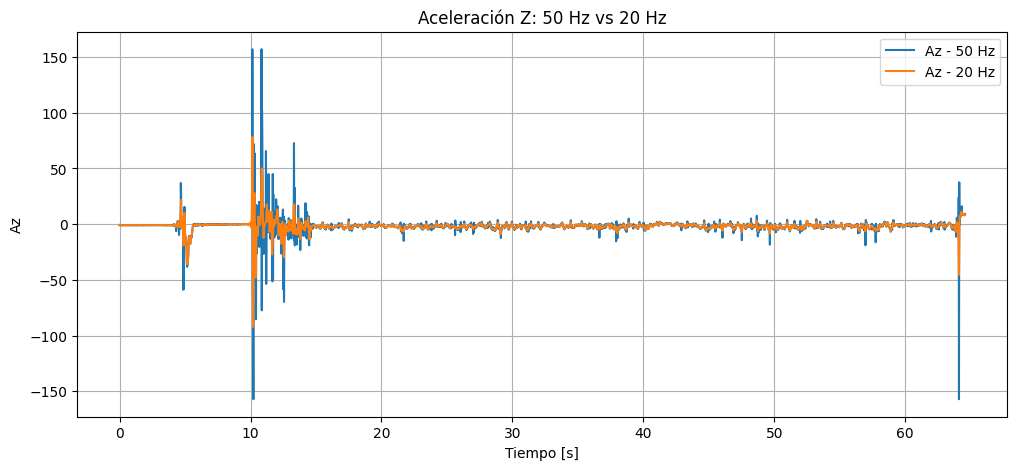

In [55]:
#Comparación de la aceleración en el eje Z entre el vuelo original a 50 Hz y el vuelo resampleado a 20 Hz
plt.figure(figsize=(12, 5))

plt.plot(
    df_50["time"],
    df_50["accl_z"],
    label="Az - 50 Hz"
)

plt.plot(
    df_20["time"],
    df_20["accl_z"],
    label="Az - 20 Hz"
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Az")
plt.title("Aceleración Z: 50 Hz vs 20 Hz")
plt.legend()
plt.grid(True)

plt.show()

In [56]:
#Para finalizar el análisis vamos a revisar que FILTROS son necesarios para validar la veracidad de los datos obtenidos con la conversión a 20 HZ
#Calculo de la Aceleración Total (At) a partir de las componentes Ax, Ay y Az
df_20["At"] = np.sqrt(
    df_20["accl_x"]**2 +
    df_20["accl_y"]**2 +
    df_20["accl_z"]**2
)
display(df_20["At"].describe())

count    1292.000000
mean       12.550717
std        16.708000
min         1.569697
25%         9.236142
50%        10.125352
75%        11.378416
max       171.985092
Name: At, dtype: float64

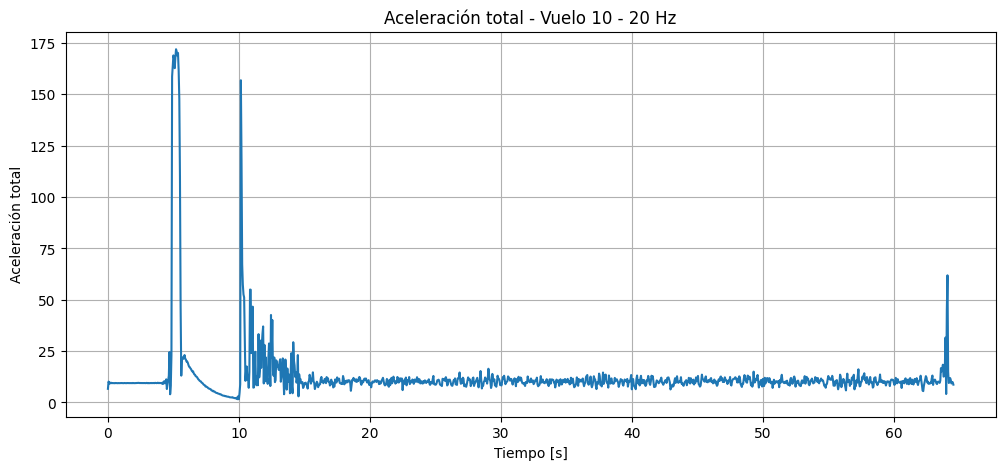

In [57]:
#Grafica de la aceleración total (At) del vuelo 10 resampleado a 20 Hz
plt.figure(figsize=(12,5))

plt.plot(df_20["time"], df_20["At"])

plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración total")
plt.title("Aceleración total - Vuelo 10 - 20 Hz")
plt.grid(True)

plt.show()

In [58]:
#Identificación del pico máximo de aceleración
idx_max = df_20["At"].idxmax()

print("Máxima aceleración total:")
print("At =", df_20.loc[idx_max, "At"])
print("Tiempo =", df_20.loc[idx_max, "time"])

print("\nValores correspondientes:")
display(
    df_20.loc[
        idx_max,
        ["time", "accl_x", "accl_y", "accl_z", "At"]
    ]
)

Máxima aceleración total:
At = 171.985091979335
Tiempo = 5.2

Valores correspondientes:


time        5.200000
accl_x   -166.423610
accl_y     24.140722
accl_z    -36.045518
At        171.985092
Name: 104, dtype: float64

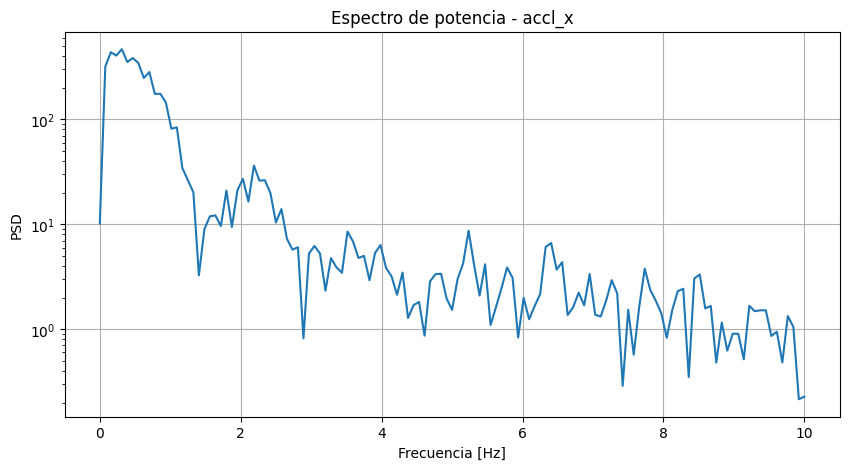

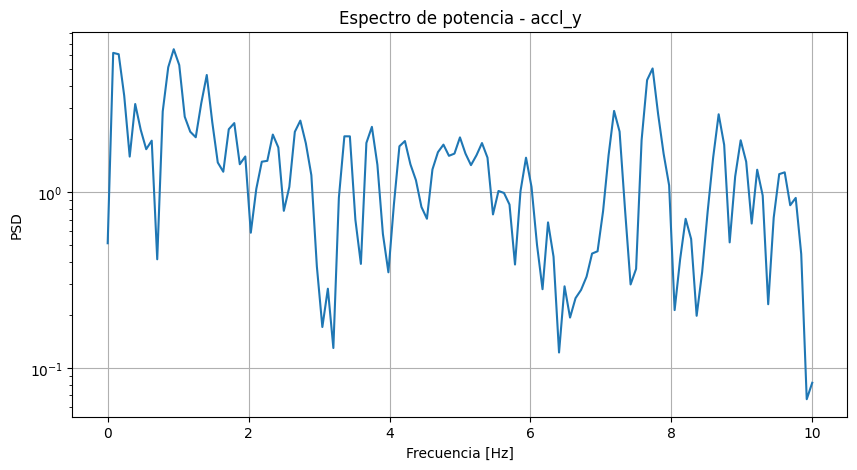

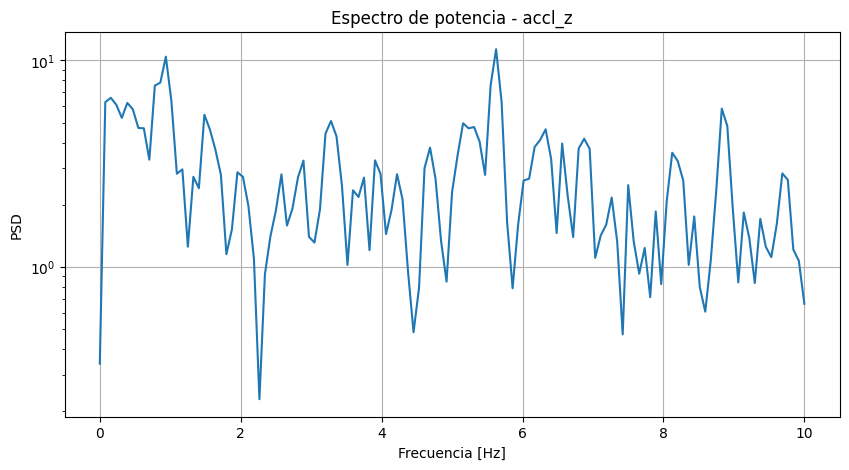

In [59]:
#Analisis del espectro de la señal de aceleración total (At) para determinar la presencia de ruido y la necesidad de aplicar filtros adicionales
from scipy.signal import welch

fs = 20  # Hz

signals = [
    "accl_x",
    "accl_y",
    "accl_z"
]

for signal in signals:

    frequencies, power = welch(
        df_20[signal].values,
        fs=fs,
        nperseg=min(256, len(df_20))
    )

    plt.figure(figsize=(10, 5))

    plt.semilogy(
        frequencies,
        power
    )

    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("PSD")
    plt.title(f"Espectro de potencia - {signal}")
    plt.grid(True)

    plt.show()

In [69]:
#Comprobacion de Unidades 

df_20_clean = df_20.copy()

# Magnitud de la aceleración
df_20_clean["At"] = np.sqrt(
    df_20_clean["accl_x"]**2 +
    df_20_clean["accl_y"]**2 +
    df_20_clean["accl_z"]**2
)

print("Aceleración total:")
print(df_20_clean["At"].describe())

print("\nAceleración máxima:")
idx_max = df_20_clean["At"].idxmax()

print("At =", df_20_clean.loc[idx_max, "At"], "m/s²")
print("At =", df_20_clean.loc[idx_max, "At"] / 9.80665, "G")
print("Tiempo =", df_20_clean.loc[idx_max, "time"], "s")

print("\nValores en el máximo:")
display(
    df_20_clean.loc[
        idx_max,
        ["time", "accl_x", "accl_y", "accl_z", "At"]
    ]
)

Aceleración total:
count    1292.000000
mean       12.550717
std        16.708000
min         1.569697
25%         9.236142
50%        10.125352
75%        11.378416
max       171.985092
Name: At, dtype: float64

Aceleración máxima:
At = 171.985091979335 m/s²
At = 17.537598668182817 G
Tiempo = 5.2 s

Valores en el máximo:


time        5.200000
accl_x   -166.423610
accl_y     24.140722
accl_z    -36.045518
At        171.985092
Name: 104, dtype: float64

In [70]:
#Validacion de la existencia de un Outlier 
idx_max = df_20_clean["At"].idxmax()

display(
    df_20_clean.loc[
        idx_max,
        ["time", "accl_x", "accl_y", "accl_z", "At"]
    ]
)

time        5.200000
accl_x   -166.423610
accl_y     24.140722
accl_z    -36.045518
At        171.985092
Name: 104, dtype: float64

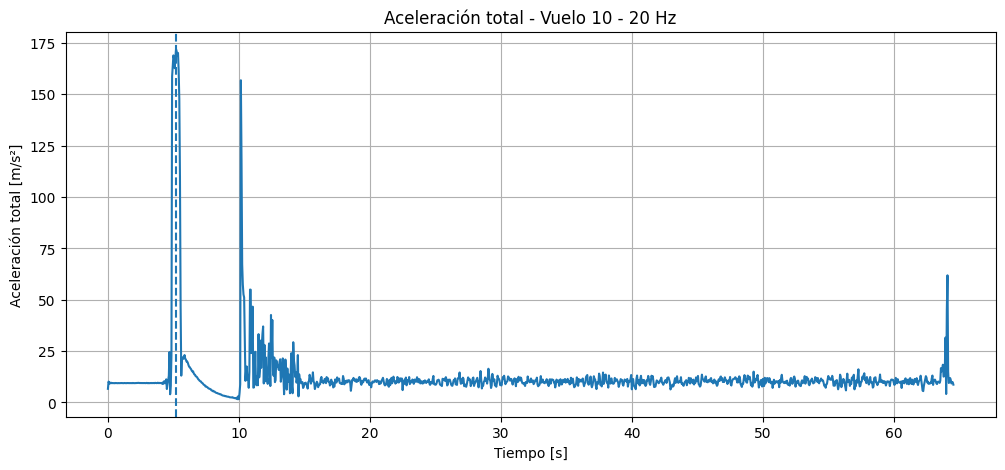

In [71]:
#Hacermos esta grafica porque queremos verificar en que fase del vuelo se dan los outliers calculados en el paso anterior
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    df_20_clean["time"],
    df_20_clean["At"]
)

plt.axvline(
    df_20_clean.loc[idx_max, "time"],
    linestyle="--"
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración total [m/s²]")
plt.title("Aceleración total - Vuelo 10 - 20 Hz")
plt.grid(True)

plt.show()

In [72]:
# Ventana alrededor de la máxima aceleración

ventana = df_20_clean[
    (df_20_clean["time"] >= 4.5) &
    (df_20_clean["time"] <= 6.5)
]

display(
    ventana[
        ["time", "accl_x", "accl_y", "accl_z", "At"]
    ]
)

,time,accl_x,accl_y,accl_z,At
90,4.50,-6.297166,1.330880,-1.129200,6.534572
91,4.55,-7.873892,3.196970,-2.756526,8.934048
92,4.60,-10.427043,-1.206689,-2.389122,10.765093
93,4.65,-11.624328,-0.592680,5.739289,12.977508
94,4.70,11.098858,2.734322,21.700851,24.527293
95,4.75,1.042387,-1.309838,-3.615679,3.984393
96,4.80,-5.485247,-0.224545,6.218223,8.294857
97,4.85,-18.873252,4.132198,-12.426627,22.971629
98,4.90,-157.040033,-12.830651,-19.087548,158.715254
99,4.95,-163.396563,6.534155,10.085317,163.837863


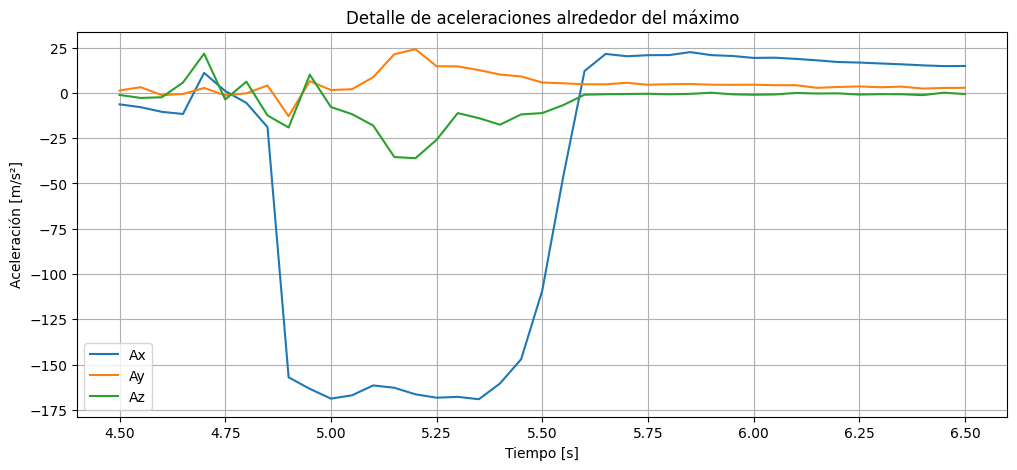

In [73]:
plt.figure(figsize=(12, 5))

plt.plot(
    ventana["time"],
    ventana["accl_x"],
    label="Ax"
)

plt.plot(
    ventana["time"],
    ventana["accl_y"],
    label="Ay"
)

plt.plot(
    ventana["time"],
    ventana["accl_z"],
    label="Az"
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración [m/s²]")
plt.title("Detalle de aceleraciones alrededor del máximo")
plt.grid(True)
plt.legend()

plt.show()

In [2]:
print([x for x in globals() if not x.startswith("_")])

['In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'FS_ORIGINAL', 'FS_TARGET', 'tolerance']


In [3]:
import numpy as np
import pandas as pd
from pathlib import Path

# Buscar archivos CSV
files = sorted(Path(".").glob("*_standardized.csv"))

print("Archivos encontrados:", len(files))
print(files[:10])

Archivos encontrados: 0
[]


In [4]:
import os

print("Carpeta actual:")
print(os.getcwd())

print("\nArchivos disponibles:")
print(os.listdir())

Carpeta actual:
c:\TensorFlow\RocketNeuralNetworkFlightComputer\Notebooks

Archivos disponibles:
['01_EDA.ipynb']


In [5]:
from pathlib import Path

# Carpeta principal del proyecto
project_path = Path(r"c:\TensorFlow\RocketNeuralNetworkFlightComputer")

# Buscar todos los CSV dentro del proyecto
csv_files = list(project_path.rglob("*.csv"))

print("CSV encontrados:", len(csv_files))

for f in csv_files[:20]:
    print(f)

CSV encontrados: 64
c:\TensorFlow\RocketNeuralNetworkFlightComputer\Test\datos_aapl.csv
c:\TensorFlow\RocketNeuralNetworkFlightComputer\Data\Raw Data\10_standardized.csv
c:\TensorFlow\RocketNeuralNetworkFlightComputer\Data\Raw Data\11_standardized.csv
c:\TensorFlow\RocketNeuralNetworkFlightComputer\Data\Raw Data\12_standardized.csv
c:\TensorFlow\RocketNeuralNetworkFlightComputer\Data\Raw Data\13_standardized.csv
c:\TensorFlow\RocketNeuralNetworkFlightComputer\Data\Raw Data\14_standardized.csv
c:\TensorFlow\RocketNeuralNetworkFlightComputer\Data\Raw Data\15_standardized.csv
c:\TensorFlow\RocketNeuralNetworkFlightComputer\Data\Raw Data\16_standardized.csv
c:\TensorFlow\RocketNeuralNetworkFlightComputer\Data\Raw Data\17_standardized.csv
c:\TensorFlow\RocketNeuralNetworkFlightComputer\Data\Raw Data\18_standardized.csv
c:\TensorFlow\RocketNeuralNetworkFlightComputer\Data\Raw Data\19_standardized.csv
c:\TensorFlow\RocketNeuralNetworkFlightComputer\Data\Raw Data\1_standardized.csv
c:\TensorFl

In [7]:
import numpy as np
import pandas as pd
from pathlib import Path

# Carpeta donde están los vuelos
data_path = Path(
    r"c:\TensorFlow\RocketNeuralNetworkFlightComputer\Data\Raw Data"
)

# Buscar solamente vuelos estandarizados
flight_files = sorted(data_path.glob("*_standardized.csv"))

print("Vuelos encontrados:", len(flight_files))

Vuelos encontrados: 62


In [8]:
flight_info = []

for file in flight_files:

    df = pd.read_csv(file)

    # Calcular intervalo de tiempo
    dt = df["time"].diff()

    # Frecuencia promedio
    frequency_hz = 1 / dt.mean()

    # Duración
    duration_s = df["time"].iloc[-1] - df["time"].iloc[0]

    # Valores faltantes
    missing_values = df.isna().sum().sum()

    flight_info.append({
        "flight": file.stem,
        "samples": len(df),
        "duration_s": duration_s,
        "frequency_hz": frequency_hz,
        "missing_values": missing_values
    })

df_flight_info = pd.DataFrame(flight_info)

display(df_flight_info)

,flight,samples,duration_s,frequency_hz,missing_values
0,10_standardized,3229,64.561,49.999226,0
1,11_standardized,816,16.300,50.000000,0
2,12_standardized,2568,51.341,49.999026,0
3,13_standardized,2988,59.741,49.999163,0
4,14_standardized,3742,74.820,50.000000,0
...,...,...,...,...,...
57,flightsketch7_standardized,3543,70.841,49.999294,0
58,flightsketch8_standardized,2506,50.101,49.999002,0
59,LAD4_standardized,637,63.400,10.031546,0
60,LAD5_standardized,59,5.800,10.000000,0


In [9]:
FS_ORIGINAL = 50
FS_TARGET = 20

# Tolerancia para identificar vuelos de aproximadamente 50 Hz
tolerance = 2

df_50_list = df_flight_info[
    (df_flight_info["frequency_hz"] >= FS_ORIGINAL - tolerance) &
    (df_flight_info["frequency_hz"] <= FS_ORIGINAL + tolerance)
].copy()

print("Vuelos de aproximadamente 50 Hz:", len(df_50_list))

print("\nVuelos seleccionados:")
display(df_50_list)

Vuelos de aproximadamente 50 Hz: 48

Vuelos seleccionados:


,flight,samples,duration_s,frequency_hz,missing_values
0,10_standardized,3229,64.561,49.999226,0
1,11_standardized,816,16.300,50.000000,0
2,12_standardized,2568,51.341,49.999026,0
3,13_standardized,2988,59.741,49.999163,0
4,14_standardized,3742,74.820,50.000000,0
5,15_standardized,2663,53.241,49.999061,0
6,16_standardized,3358,67.141,49.999255,0
7,17_standardized,3453,69.041,49.999276,0
8,18_standardized,2506,50.101,49.999002,0
9,19_standardized,2506,50.101,49.999002,0


In [10]:
excluded_flights = df_flight_info[
    ~df_flight_info["flight"].isin(df_50_list["flight"])
].copy()

print("Vuelos excluidos:", len(excluded_flights))

display(excluded_flights)

Vuelos excluidos: 14


,flight,samples,duration_s,frequency_hz,missing_values
39,altus1_standardized,6630,291.260,22.759734,0
40,altus2_standardized,2184,77.750,28.077170,0
41,altus3_standardized,9511,425.240,22.363842,0
42,altus4_standardized,3132,116.030,26.984401,0
43,altus5_standardized,2186,97.440,22.424056,0
44,altus6_standardized,14141,811.340,17.427959,0
45,altus7_standardized,8738,332.620,26.267212,0
46,custom1_standardized,4557,235.102,19.378823,0
47,custom2_standardized,6023,313.526,19.207338,0
48,custom3_standardized,3169,164.520,19.256018,0


In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.signal import resample_poly

# ============================================================
# CONFIGURACIÓN
# ============================================================

data_path = Path(
    r"c:\TensorFlow\RocketNeuralNetworkFlightComputer\Data\Raw Data"
)

output_path = Path(
    r"c:\TensorFlow\RocketNeuralNetworkFlightComputer\Data\Processed Data\20Hz"
)

output_path.mkdir(parents=True, exist_ok=True)

FS_ORIGINAL = 50
FS_TARGET = 20

# Variables que vamos a conservar
signal_columns = [
    "baro_altitude",
    "accl_x",
    "accl_y",
    "accl_z",
    "gps_altitude",
    "gyro_roll",
    "gyro_pitch",
    "gyro_yaw"
]

In [12]:
# ============================================================
# CONVERSIÓN 50 Hz → 20 Hz
# ============================================================

processed_flights = []

for _, row in df_50_list.iterrows():

    input_file = data_path / (row["flight"] + ".csv")

    df_50 = pd.read_csv(input_file)

    n_original = len(df_50)

    # Número esperado de muestras
    n_target = int(
        np.ceil(
            n_original * FS_TARGET / FS_ORIGINAL
        )
    )

    df_20 = pd.DataFrame()

    # --------------------------------------------------------
    # Nueva base temporal
    # --------------------------------------------------------

    df_20["time"] = np.arange(n_target) / FS_TARGET

    # --------------------------------------------------------
    # Resampling de las señales
    # --------------------------------------------------------

    for column in signal_columns:

        signal = df_50[column].to_numpy()

        resampled = resample_poly(
            signal,
            up=2,
            down=5
        )

        # Ajustar longitud
        resampled = resampled[:n_target]

        df_20[column] = resampled

    # Identificador del vuelo
    df_20["flight_id"] = row["flight"]

    # --------------------------------------------------------
    # Guardar
    # --------------------------------------------------------

    output_file = output_path / (
        row["flight"] + "_20Hz.csv"
    )

    df_20.to_csv(
        output_file,
        index=False
    )

    processed_flights.append({
        "flight_id": row["flight"],
        "samples_original": n_original,
        "samples_20Hz": len(df_20),
        "duration_original_s": df_50["time"].iloc[-1],
        "duration_20Hz_s": df_20["time"].iloc[-1],
        "output_file": str(output_file)
    })

print("Vuelos procesados:", len(processed_flights))

Vuelos procesados: 48


In [13]:
df_processed_info = pd.DataFrame(processed_flights)

display(df_processed_info)

,flight_id,samples_original,samples_20Hz,duration_original_s,duration_20Hz_s,output_file
0,10_standardized,3229,1292,64.561,64.55,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
1,11_standardized,816,327,16.300,16.30,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
2,12_standardized,2568,1028,51.341,51.35,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
3,13_standardized,2988,1196,59.741,59.75,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
4,14_standardized,3742,1497,74.820,74.80,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
5,15_standardized,2663,1066,53.241,53.25,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
6,16_standardized,3358,1344,67.141,67.15,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
7,17_standardized,3453,1382,69.041,69.05,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
8,18_standardized,2506,1003,50.101,50.10,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
9,19_standardized,2506,1003,50.101,50.10,c:\TensorFlow\RocketNeuralNetworkFlightCompute...


In [14]:
# Verificar frecuencia de los vuelos procesados

frequencies_20 = []

for flight_id in df_processed_info["flight_id"]:

    file = output_path / (
        flight_id + "_20Hz.csv"
    )

    df = pd.read_csv(file)

    dt = df["time"].diff().dropna()

    frequency = 1 / dt.mean()

    frequencies_20.append({
        "flight_id": flight_id,
        "frequency_hz": frequency,
        "samples": len(df),
        "missing_values": df.isna().sum().sum()
    })

df_check_20 = pd.DataFrame(frequencies_20)

display(df_check_20)

,flight_id,frequency_hz,samples,missing_values
0,10_standardized,20.0,1292,0
1,11_standardized,20.0,327,0
2,12_standardized,20.0,1028,0
3,13_standardized,20.0,1196,0
4,14_standardized,20.0,1497,0
5,15_standardized,20.0,1066,0
6,16_standardized,20.0,1344,0
7,17_standardized,20.0,1382,0
8,18_standardized,20.0,1003,0
9,19_standardized,20.0,1003,0


In [15]:
import numpy as np
import pandas as pd

# Lista para almacenar la información
flight_stats = []

for _, row in df_processed_info.iterrows():

    flight_id = row["flight_id"]

    file = output_path / (
        flight_id + "_20Hz.csv"
    )

    df = pd.read_csv(file)

    # ==========================================
    # Calcular aceleración total
    # ==========================================

    df["At"] = np.sqrt(
        df["accl_x"]**2 +
        df["accl_y"]**2 +
        df["accl_z"]**2
    )

    # ==========================================
    # Estadísticas del vuelo
    # ==========================================

    flight_stats.append({
        "flight_id": flight_id,

        "duration_s":
            df["time"].iloc[-1],

        "altitude_baro_max_m":
            df["baro_altitude"].max(),

        "altitude_gps_max_m":
            df["gps_altitude"].max(),

        "Ax_min":
            df["accl_x"].min(),

        "Ax_max":
            df["accl_x"].max(),

        "Ay_min":
            df["accl_y"].min(),

        "Ay_max":
            df["accl_y"].max(),

        "Az_min":
            df["accl_z"].min(),

        "Az_max":
            df["accl_z"].max(),

        "At_max":
            df["At"].max()
    })

df_flight_stats = pd.DataFrame(flight_stats)

display(df_flight_stats)

,flight_id,duration_s,altitude_baro_max_m,altitude_gps_max_m,Ax_min,Ax_max,Ay_min,Ay_max,Az_min,Az_max,At_max
0,10_standardized,64.55,227.276867,0.0,-169.127456,135.926388,-36.877150,57.420621,-92.158920,78.278353,171.985092
1,11_standardized,16.30,254.725508,0.0,-155.448118,63.974707,-132.259908,97.869234,-129.131464,145.481117,203.798028
2,12_standardized,51.35,261.587878,0.0,-126.511387,140.282488,-70.269590,76.952030,-157.812830,86.782017,169.344612
3,13_standardized,59.75,263.156671,0.0,-132.527068,90.270921,-72.690948,152.399547,-84.339232,89.175328,182.707057
4,14_standardized,74.80,269.514285,0.0,-111.966845,146.724703,-92.618072,54.670739,-118.037196,45.723282,153.825541
5,15_standardized,53.25,271.307671,0.0,-41.149648,79.141198,-55.018548,61.426242,-146.789702,162.367453,180.824667
6,16_standardized,67.15,276.145463,0.0,-178.585296,63.936465,-21.676325,65.675322,-45.050014,21.742849,179.030361
7,17_standardized,69.05,291.122539,0.0,-53.200171,54.742844,-23.691692,17.209803,-100.269012,166.102804,166.531993
8,18_standardized,50.10,289.153940,0.0,-252.525599,99.681992,-135.416626,131.584198,-118.839346,76.334502,266.798492
9,19_standardized,50.10,294.733198,0.0,-60.108331,117.082703,-87.111286,94.287553,-81.505575,91.102998,131.206530


In [16]:
df_flight_stats_sorted = df_flight_stats.sort_values(
    by="At_max",
    ascending=False
)

display(df_flight_stats_sorted)

,flight_id,duration_s,altitude_baro_max_m,altitude_gps_max_m,Ax_min,Ax_max,Ay_min,Ay_max,Az_min,Az_max,At_max
8,18_standardized,50.10,289.153940,0.0,-252.525599,99.681992,-135.416626,131.584198,-118.839346,76.334502,266.798492
46,flightsketch7_standardized,70.85,859.336205,0.0,-176.491882,116.462844,-196.017603,97.991088,-139.384461,156.548707,243.327431
31,39_standardized,190.30,1975.329127,0.0,-237.834204,219.040909,-39.507648,107.222278,-98.588012,69.647825,242.444770
15,24_standardized,99.60,371.381907,0.0,-222.943704,49.178189,-60.777813,31.273473,-54.153227,25.751853,224.797758
14,23_standardized,99.60,371.381907,0.0,-222.943704,49.178189,-60.777813,31.273473,-54.153227,25.751853,224.797758
42,flightsketch3_standardized,101.45,887.303935,0.0,-128.052259,128.083954,-76.173392,77.653478,-160.585202,60.013608,219.078735
24,32_standardized,101.45,887.303935,0.0,-128.052259,128.083954,-76.173392,77.653478,-160.585202,60.013608,219.078735
10,1_standardized,50.10,108.392732,0.0,-151.504941,60.940551,-59.236859,75.678544,-155.366733,55.188981,218.405775
20,29_standardized,78.35,834.789357,0.0,-207.461163,161.557370,-32.062995,28.403176,-64.934035,46.810940,211.805935
22,30_standardized,168.60,878.500929,0.0,-183.186751,92.539025,-118.036524,66.950133,-141.435222,143.261001,207.259675


In [18]:
df_flight_stats_sorted = df_flight_stats.sort_values(
    by="At_max",
    ascending=False
)
display(df_flight_stats_sorted)
display(df_flight_stats_sorted.to_string(index=False))

,flight_id,duration_s,altitude_baro_max_m,altitude_gps_max_m,Ax_min,Ax_max,Ay_min,Ay_max,Az_min,Az_max,At_max
8,18_standardized,50.10,289.153940,0.0,-252.525599,99.681992,-135.416626,131.584198,-118.839346,76.334502,266.798492
46,flightsketch7_standardized,70.85,859.336205,0.0,-176.491882,116.462844,-196.017603,97.991088,-139.384461,156.548707,243.327431
31,39_standardized,190.30,1975.329127,0.0,-237.834204,219.040909,-39.507648,107.222278,-98.588012,69.647825,242.444770
15,24_standardized,99.60,371.381907,0.0,-222.943704,49.178189,-60.777813,31.273473,-54.153227,25.751853,224.797758
14,23_standardized,99.60,371.381907,0.0,-222.943704,49.178189,-60.777813,31.273473,-54.153227,25.751853,224.797758
42,flightsketch3_standardized,101.45,887.303935,0.0,-128.052259,128.083954,-76.173392,77.653478,-160.585202,60.013608,219.078735
24,32_standardized,101.45,887.303935,0.0,-128.052259,128.083954,-76.173392,77.653478,-160.585202,60.013608,219.078735
10,1_standardized,50.10,108.392732,0.0,-151.504941,60.940551,-59.236859,75.678544,-155.366733,55.188981,218.405775
20,29_standardized,78.35,834.789357,0.0,-207.461163,161.557370,-32.062995,28.403176,-64.934035,46.810940,211.805935
22,30_standardized,168.60,878.500929,0.0,-183.186751,92.539025,-118.036524,66.950133,-141.435222,143.261001,207.259675


'                         flight_id  duration_s  altitude_baro_max_m  altitude_gps_max_m      Ax_min     Ax_max      Ay_min     Ay_max      Az_min     Az_max     At_max\n                   18_standardized       50.10           289.153940                 0.0 -252.525599  99.681992 -135.416626 131.584198 -118.839346  76.334502 266.798492\n        flightsketch7_standardized       70.85           859.336205                 0.0 -176.491882 116.462844 -196.017603  97.991088 -139.384461 156.548707 243.327431\n                   39_standardized      190.30          1975.329127                 0.0 -237.834204 219.040909  -39.507648 107.222278  -98.588012  69.647825 242.444770\n                   24_standardized       99.60           371.381907                 0.0 -222.943704  49.178189  -60.777813  31.273473  -54.153227  25.751853 224.797758\n                   23_standardized       99.60           371.381907                 0.0 -222.943704  49.178189  -60.777813  31.273473  -54.153227  25.7518

In [20]:
print(df_20.columns.tolist())

['time', 'baro_altitude', 'accl_x', 'accl_y', 'accl_z', 'gps_altitude', 'gyro_roll', 'gyro_pitch', 'gyro_yaw', 'flight_id']


In [21]:
df_20["At"] = np.sqrt(
    df_20["accl_x"]**2 +
    df_20["accl_y"]**2 +
    df_20["accl_z"]**2
)

print(df_20.columns.tolist())

['time', 'baro_altitude', 'accl_x', 'accl_y', 'accl_z', 'gps_altitude', 'gyro_roll', 'gyro_pitch', 'gyro_yaw', 'flight_id', 'At']


In [22]:
display(
    df_20[
        [
            "time",
            "accl_x",
            "accl_y",
            "accl_z",
            "At"
        ]
    ].head(10)
)

,time,accl_x,accl_y,accl_z,At
0,0.00,5.774909,-2.052841,1.196150,6.244558
1,0.05,8.838793,-3.139674,1.820612,9.554917
2,0.10,7.849298,-2.869627,1.616770,8.512355
3,0.15,8.393281,-3.098566,1.841019,9.134419
4,0.20,8.068724,-2.889566,1.725580,8.742512
5,0.25,8.292917,-2.979760,1.698941,8.974288
6,0.30,8.123168,-2.953050,1.646673,8.798744
7,0.35,8.234400,-2.956091,1.682119,8.909171
8,0.40,8.156101,-2.997875,1.717469,8.857705
9,0.45,8.133796,-2.968074,1.722448,8.828076


In [23]:
print(df_20["At"].describe())

count    1003.000000
mean       17.903637
std        20.148913
min         1.237609
25%         8.938268
50%         9.262242
75%        19.070429
max       131.206530
Name: At, dtype: float64


In [24]:
# ============================================
# CARACTERIZACIÓN DEL VUELO DE REFERENCIA
# ============================================

print("===== INFORMACIÓN GENERAL =====")

print("Duración del vuelo:")
print(f"{df_20['time'].iloc[-1]:.2f} s")

print("\nNúmero de muestras:")
print(len(df_20))

print("\nFrecuencia de muestreo:")
dt = df_20["time"].diff().mean()
print(f"{1/dt:.2f} Hz")


# ============================================
# ALTITUD
# ============================================

print("\n===== ALTITUD =====")

altitud_inicial = df_20["baro_altitude"].iloc[0]
altitud_maxima = df_20["baro_altitude"].max()

idx_apogeo = df_20["baro_altitude"].idxmax()
tiempo_apogeo = df_20.loc[idx_apogeo, "time"]

print(f"Altitud inicial: {altitud_inicial:.2f} m")
print(f"Altitud máxima: {altitud_maxima:.2f} m")
print(f"Tiempo del apogeo: {tiempo_apogeo:.2f} s")


# ============================================
# ACELERACIÓN
# ============================================

print("\n===== ACELERACIÓN =====")

idx_at_max = df_20["At"].idxmax()

print(f"At máxima: {df_20.loc[idx_at_max, 'At']:.2f} m/s²")
print(f"At máxima: {df_20.loc[idx_at_max, 'At']/9.80665:.2f} G")
print(f"Tiempo At máxima: {df_20.loc[idx_at_max, 'time']:.2f} s")


# ============================================
# CONDICIONES INICIALES
# ============================================

print("\n===== CONDICIONES INICIALES =====")

display(
    df_20.loc[
        :10,
        [
            "time",
            "baro_altitude",
            "accl_x",
            "accl_y",
            "accl_z",
            "At",
            "gyro_roll",
            "gyro_pitch",
            "gyro_yaw"
        ]
    ]
)

===== INFORMACIÓN GENERAL =====
Duración del vuelo:
50.10 s

Número de muestras:
1003

Frecuencia de muestreo:
20.00 Hz

===== ALTITUD =====
Altitud inicial: -0.05 m
Altitud máxima: 294.73 m
Tiempo del apogeo: 13.40 s

===== ACELERACIÓN =====
At máxima: 131.21 m/s²
At máxima: 13.38 G
Tiempo At máxima: 13.25 s

===== CONDICIONES INICIALES =====


,time,baro_altitude,accl_x,accl_y,accl_z,At,gyro_roll,gyro_pitch,gyro_yaw
0,0.00,-0.046598,5.774909,-2.052841,1.196150,6.244558,0.0,0.0,0.0
1,0.05,-0.036277,8.838793,-3.139674,1.820612,9.554917,0.0,0.0,0.0
2,0.10,-0.055252,7.849298,-2.869627,1.616770,8.512355,0.0,0.0,0.0
3,0.15,-0.100941,8.393281,-3.098566,1.841019,9.134419,0.0,0.0,0.0
4,0.20,0.016273,8.068724,-2.889566,1.725580,8.742512,0.0,0.0,0.0
5,0.25,0.010739,8.292917,-2.979760,1.698941,8.974288,0.0,0.0,0.0
6,0.30,0.020108,8.123168,-2.953050,1.646673,8.798744,0.0,0.0,0.0
7,0.35,-0.111906,8.234400,-2.956091,1.682119,8.909171,0.0,0.0,0.0
8,0.40,-0.294826,8.156101,-2.997875,1.717469,8.857705,0.0,0.0,0.0
9,0.45,-0.190825,8.133796,-2.968074,1.722448,8.828076,0.0,0.0,0.0


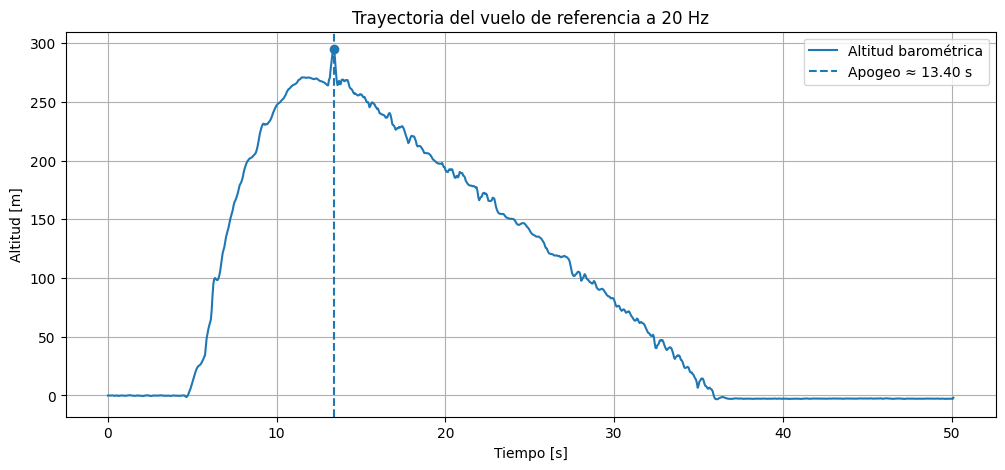

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

plt.plot(
    df_20["time"],
    df_20["baro_altitude"],
    label="Altitud barométrica"
)

plt.axvline(
    tiempo_apogeo,
    linestyle="--",
    label=f"Apogeo ≈ {tiempo_apogeo:.2f} s"
)

plt.scatter(
    tiempo_apogeo,
    altitud_maxima,
    zorder=5
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Altitud [m]")
plt.title("Trayectoria del vuelo de referencia a 20 Hz")

plt.grid(True)
plt.legend()

plt.show()

In [28]:
print(df_20.columns.tolist())
display(df_20.describe())

['time', 'baro_altitude', 'accl_x', 'accl_y', 'accl_z', 'gps_altitude', 'gyro_roll', 'gyro_pitch', 'gyro_yaw', 'flight_id', 'At']


,time,baro_altitude,accl_x,accl_y,accl_z,gps_altitude,gyro_roll,gyro_pitch,gyro_yaw,At
count,1003.000000,1003.000000,1003.000000,1003.000000,1003.000000,1003.0,1003.0,1003.0,1003.0,1003.000000
mean,25.050000,95.171905,7.402790,-2.413048,-1.087150,0.0,0.0,0.0,0.0,17.903637
std,14.484273,100.145491,16.446414,14.177900,13.909484,0.0,0.0,0.0,0.0,20.148913
min,0.000000,-3.185053,-60.108331,-87.111286,-81.505575,0.0,0.0,0.0,0.0,1.237609
25%,12.525000,-2.553332,-1.546503,-3.208627,-5.936404,0.0,0.0,0.0,0.0,8.938268
50%,25.050000,64.973883,6.282888,-2.952109,-3.287877,0.0,0.0,0.0,0.0,9.262242
75%,37.575000,189.493086,8.188816,2.978130,3.591172,0.0,0.0,0.0,0.0,19.070429
max,50.100000,294.733198,117.082703,94.287553,91.102998,0.0,0.0,0.0,0.0,131.206530


In [29]:
import numpy as np
import pandas as pd

# Copia del vuelo a 20 Hz
df_isa = df_20.copy()

# Altitud utilizada para el modelo atmosférico
h = df_isa["baro_altitude"]

# Constantes ISA
T0 = 288.15       # K
P0 = 101325.0     # Pa
L = 0.0065        # K/m
R = 287.05        # J/(kg·K)
g = 9.80665        # m/s²
gamma = 1.4

# Temperatura ISA
df_isa["T"] = T0 - L * h

# Presión ISA
df_isa["P"] = P0 * (df_isa["T"] / T0) ** (g / (R * L))

# Densidad del aire
df_isa["rho"] = df_isa["P"] / (R * df_isa["T"])

# Velocidad del sonido
df_isa["a"] = np.sqrt(gamma * R * df_isa["T"])

display(df_isa.head(10))

,time,baro_altitude,accl_x,accl_y,accl_z,gps_altitude,gyro_roll,gyro_pitch,gyro_yaw,flight_id,At,T,P,rho,a
0,0.00,-0.046598,5.774909,-2.052841,1.196150,0.0,0.0,0.0,0.0,flightsketch8_standardized,6.244558,288.150303,101325.559794,1.225018,340.292466
1,0.05,-0.036277,8.838793,-3.139674,1.820612,0.0,0.0,0.0,0.0,flightsketch8_standardized,9.554917,288.150236,101325.435801,1.225017,340.292426
2,0.10,-0.055252,7.849298,-2.869627,1.616770,0.0,0.0,0.0,0.0,flightsketch8_standardized,8.512355,288.150359,101325.663763,1.225019,340.292499
3,0.15,-0.100941,8.393281,-3.098566,1.841019,0.0,0.0,0.0,0.0,flightsketch8_standardized,9.134419,288.150656,101326.212635,1.225024,340.292674
4,0.20,0.016273,8.068724,-2.889566,1.725580,0.0,0.0,0.0,0.0,flightsketch8_standardized,8.742512,288.149894,101324.804505,1.225010,340.292224
5,0.25,0.010739,8.292917,-2.979760,1.698941,0.0,0.0,0.0,0.0,flightsketch8_standardized,8.974288,288.149930,101324.870991,1.225011,340.292246
6,0.30,0.020108,8.123168,-2.953050,1.646673,0.0,0.0,0.0,0.0,flightsketch8_standardized,8.798744,288.149869,101324.758438,1.225010,340.292210
7,0.35,-0.111906,8.234400,-2.956091,1.682119,0.0,0.0,0.0,0.0,flightsketch8_standardized,8.909171,288.150727,101326.344358,1.225025,340.292716
8,0.40,-0.294826,8.156101,-2.997875,1.717469,0.0,0.0,0.0,0.0,flightsketch8_standardized,8.857705,288.151916,101328.541874,1.225047,340.293418
9,0.45,-0.190825,8.133796,-2.968074,1.722448,0.0,0.0,0.0,0.0,flightsketch8_standardized,8.828076,288.151240,101327.292452,1.225035,340.293019


In [30]:
df_isa[["time", "baro_altitude", "T", "P", "rho", "a"]].describe()

,time,baro_altitude,T,P,rho,a
count,1003.000000,1003.000000,1003.000000,1003.000000,1003.000000,1003.000000
mean,25.050000,95.171905,287.531383,100192.616375,1.213902,339.926593
std,14.484273,100.145491,0.650946,1189.458928,0.011676,0.384885
min,0.000000,-3.185053,286.234234,97834.024617,1.190723,339.159183
25%,12.525000,-2.553332,286.918295,99069.179782,1.202881,339.564214
50%,25.050000,64.973883,287.727670,100546.881996,1.217389,340.042819
75%,37.575000,189.493086,288.166597,101355.677624,1.225313,340.302087
max,50.100000,294.733198,288.170703,101363.268742,1.225387,340.304511


In [31]:
display(
    df_isa[
        ["time", "baro_altitude", "T", "P", "rho", "a"]
    ].head(20)
)

,time,baro_altitude,T,P,rho,a
0,0.00,-0.046598,288.150303,101325.559794,1.225018,340.292466
1,0.05,-0.036277,288.150236,101325.435801,1.225017,340.292426
2,0.10,-0.055252,288.150359,101325.663763,1.225019,340.292499
3,0.15,-0.100941,288.150656,101326.212635,1.225024,340.292674
4,0.20,0.016273,288.149894,101324.804505,1.225010,340.292224
5,0.25,0.010739,288.149930,101324.870991,1.225011,340.292246
6,0.30,0.020108,288.149869,101324.758438,1.225010,340.292210
7,0.35,-0.111906,288.150727,101326.344358,1.225025,340.292716
8,0.40,-0.294826,288.151916,101328.541874,1.225047,340.293418
9,0.45,-0.190825,288.151240,101327.292452,1.225035,340.293019


In [34]:
print("Columnas de df_20:")
print(df_20.columns.tolist())

print("\nColumnas de df_model:")
print(df_model.columns.tolist() if "df_model" in globals() else "df_model todavía no existe")

Columnas de df_20:
['time', 'baro_altitude', 'accl_x', 'accl_y', 'accl_z', 'gps_altitude', 'gyro_roll', 'gyro_pitch', 'gyro_yaw', 'flight_id', 'At']

Columnas de df_model:
['time', 'baro_altitude', 'accl_x', 'accl_y', 'accl_z', 'gps_altitude', 'gyro_roll', 'gyro_pitch', 'gyro_yaw', 'flight_id', 'At', 'apogee']


In [35]:
print("\n¿Existen las variables ISA?")

for col in ["T", "P", "rho", "a"]:
    print(col, "→", col in df_20.columns)


¿Existen las variables ISA?
T → False
P → False
rho → False
a → False


In [36]:
import numpy as np

def isa_atmosphere(h):
    """
    Modelo ISA para la troposfera.
    
    h : altitud [m]
    
    Retorna:
    T   : temperatura [K]
    P   : presión [Pa]
    rho : densidad [kg/m³]
    a   : velocidad del sonido [m/s]
    """
    
    # Constantes ISA
    T0 = 288.15          # K
    P0 = 101325.0        # Pa
    L = 0.0065           # K/m
    R = 287.05           # J/(kg·K)
    gamma = 1.4
    g = 9.80665          # m/s²
    
    # Limitar a troposfera
    h = np.asarray(h)
    h = np.clip(h, 0, 11000)
    
    # Temperatura
    T = T0 - L * h
    
    # Presión
    P = P0 * (T / T0) ** (g / (R * L))
    
    # Densidad
    rho = P / (R * T)
    
    # Velocidad del sonido
    a = np.sqrt(gamma * R * T)
    
    return T, P, rho, a

In [37]:
T, P, rho, a = isa_atmosphere(
    df_20["baro_altitude"]
)

df_20["T"] = T
df_20["P"] = P
df_20["rho"] = rho
df_20["a"] = a

print(df_20.columns.tolist())

['time', 'baro_altitude', 'accl_x', 'accl_y', 'accl_z', 'gps_altitude', 'gyro_roll', 'gyro_pitch', 'gyro_yaw', 'flight_id', 'At', 'T', 'P', 'rho', 'a']


In [38]:
display(
    df_20[
        [
            "time",
            "baro_altitude",
            "T",
            "P",
            "rho",
            "a"
        ]
    ].head(20)
)

,time,baro_altitude,T,P,rho,a
0,0.00,-0.046598,288.150000,101325.000000,1.225012,340.292287
1,0.05,-0.036277,288.150000,101325.000000,1.225012,340.292287
2,0.10,-0.055252,288.150000,101325.000000,1.225012,340.292287
3,0.15,-0.100941,288.150000,101325.000000,1.225012,340.292287
4,0.20,0.016273,288.149894,101324.804505,1.225010,340.292224
5,0.25,0.010739,288.149930,101324.870991,1.225011,340.292246
6,0.30,0.020108,288.149869,101324.758438,1.225010,340.292210
7,0.35,-0.111906,288.150000,101325.000000,1.225012,340.292287
8,0.40,-0.294826,288.150000,101325.000000,1.225012,340.292287
9,0.45,-0.190825,288.150000,101325.000000,1.225012,340.292287


In [39]:
# DATASET PARA LA RED NEURONAL

df_model = df_20.copy()

# Apogeo de cada vuelo
apogee_by_flight = (
    df_model
    .groupby("flight_id")["baro_altitude"]
    .max()
    .rename("apogee")
)

# Añadir el apogeo a cada muestra
df_model = df_model.merge(
    apogee_by_flight,
    on="flight_id",
    how="left"
)

print("Número de vuelos:", df_model["flight_id"].nunique())

print("Número total de muestras:", len(df_model))

print("\nVariables:")
print(df_model.columns.tolist())

Número de vuelos: 1
Número total de muestras: 1003

Variables:
['time', 'baro_altitude', 'accl_x', 'accl_y', 'accl_z', 'gps_altitude', 'gyro_roll', 'gyro_pitch', 'gyro_yaw', 'flight_id', 'At', 'T', 'P', 'rho', 'a', 'apogee']


In [40]:
display(
    df_model[
        [
            "flight_id",
            "time",
            "baro_altitude",
            "accl_x",
            "accl_y",
            "accl_z",
            "At",
            "T",
            "P",
            "rho",
            "a",
            "apogee"
        ]
    ].head(20)
)

,flight_id,time,baro_altitude,accl_x,accl_y,accl_z,At,T,P,rho,a,apogee
0,flightsketch8_standardized,0.00,-0.046598,5.774909,-2.052841,1.196150,6.244558,288.150000,101325.000000,1.225012,340.292287,294.733198
1,flightsketch8_standardized,0.05,-0.036277,8.838793,-3.139674,1.820612,9.554917,288.150000,101325.000000,1.225012,340.292287,294.733198
2,flightsketch8_standardized,0.10,-0.055252,7.849298,-2.869627,1.616770,8.512355,288.150000,101325.000000,1.225012,340.292287,294.733198
3,flightsketch8_standardized,0.15,-0.100941,8.393281,-3.098566,1.841019,9.134419,288.150000,101325.000000,1.225012,340.292287,294.733198
4,flightsketch8_standardized,0.20,0.016273,8.068724,-2.889566,1.725580,8.742512,288.149894,101324.804505,1.225010,340.292224,294.733198
5,flightsketch8_standardized,0.25,0.010739,8.292917,-2.979760,1.698941,8.974288,288.149930,101324.870991,1.225011,340.292246,294.733198
6,flightsketch8_standardized,0.30,0.020108,8.123168,-2.953050,1.646673,8.798744,288.149869,101324.758438,1.225010,340.292210,294.733198
7,flightsketch8_standardized,0.35,-0.111906,8.234400,-2.956091,1.682119,8.909171,288.150000,101325.000000,1.225012,340.292287,294.733198
8,flightsketch8_standardized,0.40,-0.294826,8.156101,-2.997875,1.717469,8.857705,288.150000,101325.000000,1.225012,340.292287,294.733198
9,flightsketch8_standardized,0.45,-0.190825,8.133796,-2.968074,1.722448,8.828076,288.150000,101325.000000,1.225012,340.292287,294.733198


In [41]:
print(df_20.columns.tolist())

['time', 'baro_altitude', 'accl_x', 'accl_y', 'accl_z', 'gps_altitude', 'gyro_roll', 'gyro_pitch', 'gyro_yaw', 'flight_id', 'At', 'T', 'P', 'rho', 'a']


In [42]:
display(
    df_model[
        ["time", "baro_altitude", "T", "P", "rho", "a", "apogee"]
    ].head(10)
)

,time,baro_altitude,T,P,rho,a,apogee
0,0.00,-0.046598,288.150000,101325.000000,1.225012,340.292287,294.733198
1,0.05,-0.036277,288.150000,101325.000000,1.225012,340.292287,294.733198
2,0.10,-0.055252,288.150000,101325.000000,1.225012,340.292287,294.733198
3,0.15,-0.100941,288.150000,101325.000000,1.225012,340.292287,294.733198
4,0.20,0.016273,288.149894,101324.804505,1.225010,340.292224,294.733198
5,0.25,0.010739,288.149930,101324.870991,1.225011,340.292246,294.733198
6,0.30,0.020108,288.149869,101324.758438,1.225010,340.292210,294.733198
7,0.35,-0.111906,288.150000,101325.000000,1.225012,340.292287,294.733198
8,0.40,-0.294826,288.150000,101325.000000,1.225012,340.292287,294.733198
9,0.45,-0.190825,288.150000,101325.000000,1.225012,340.292287,294.733198


In [43]:
# VALIDACIÓN DEL DATASET PARA LA ANN

print("Número de vuelos:", df_model["flight_id"].nunique())
print("Número total de muestras:", len(df_model))

# Comprobar cuántos apogeos diferentes tiene cada vuelo
apogee_check = (
    df_model
    .groupby("flight_id")["apogee"]
    .nunique()
)

print("\nValores únicos de apogeo por vuelo:")
print(apogee_check.value_counts())

# Mostrar resumen de cada vuelo
flight_summary = (
    df_model
    .groupby("flight_id")
    .agg(
        muestras=("time", "count"),
        duracion=("time", "max"),
        altitud_max=("baro_altitude", "max"),
        apogeo=("apogee", "first")
    )
    .sort_values("apogeo", ascending=False)
)

display(flight_summary)

Número de vuelos: 1
Número total de muestras: 1003

Valores únicos de apogeo por vuelo:
apogee
1    1
Name: count, dtype: int64


,muestras,duracion,altitud_max,apogeo
flight_id,,,,
flightsketch8_standardized,1003,50.1,294.733198,294.733198


In [44]:
print(df_20["flight_id"].unique())

<StringArray>
['flightsketch8_standardized']
Length: 1, dtype: str


In [45]:
print("Número de vuelos en df_20:", df_20["flight_id"].nunique())

Número de vuelos en df_20: 1


In [46]:
%whos

Variable                 Type           Data/Info
-------------------------------------------------
FS_ORIGINAL              int            50
FS_TARGET                int            20
L                        float          0.0065
P                        ndarray        1003: 1003 elems, type `float64`, 8024 bytes
P0                       float          101325.0
Path                     type           <class 'pathlib._local.Path'>
R                        float          287.05
T                        ndarray        1003: 1003 elems, type `float64`, 8024 bytes
T0                       float          288.15
a                        ndarray        1003: 1003 elems, type `float64`, 8024 bytes
altitud_inicial          float64        -0.0465978489249025
altitud_maxima           float64        294.73319827118877
apogee_by_flight         Series         Shape: (1,)
apogee_check             Series         Shape: (1,)
col                      str            a
column                   str      

In [47]:
print("===== processed_flights =====")
print(processed_flights)

print("\n===== df_processed_info =====")
display(df_processed_info)

print("\n===== df_50_list =====")
display(df_50_list.head())

===== processed_flights =====
[{'flight_id': '10_standardized', 'samples_original': 3229, 'samples_20Hz': 1292, 'duration_original_s': np.float64(64.56099999999999), 'duration_20Hz_s': np.float64(64.55), 'output_file': 'c:\\TensorFlow\\RocketNeuralNetworkFlightComputer\\Data\\Processed Data\\20Hz\\10_standardized_20Hz.csv'}, {'flight_id': '11_standardized', 'samples_original': 816, 'samples_20Hz': 327, 'duration_original_s': np.float64(16.3), 'duration_20Hz_s': np.float64(16.3), 'output_file': 'c:\\TensorFlow\\RocketNeuralNetworkFlightComputer\\Data\\Processed Data\\20Hz\\11_standardized_20Hz.csv'}, {'flight_id': '12_standardized', 'samples_original': 2568, 'samples_20Hz': 1028, 'duration_original_s': np.float64(51.341), 'duration_20Hz_s': np.float64(51.35), 'output_file': 'c:\\TensorFlow\\RocketNeuralNetworkFlightComputer\\Data\\Processed Data\\20Hz\\12_standardized_20Hz.csv'}, {'flight_id': '13_standardized', 'samples_original': 2988, 'samples_20Hz': 1196, 'duration_original_s': np.f

,flight_id,samples_original,samples_20Hz,duration_original_s,duration_20Hz_s,output_file
0,10_standardized,3229,1292,64.561,64.55,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
1,11_standardized,816,327,16.300,16.30,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
2,12_standardized,2568,1028,51.341,51.35,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
3,13_standardized,2988,1196,59.741,59.75,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
4,14_standardized,3742,1497,74.820,74.80,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
5,15_standardized,2663,1066,53.241,53.25,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
6,16_standardized,3358,1344,67.141,67.15,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
7,17_standardized,3453,1382,69.041,69.05,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
8,18_standardized,2506,1003,50.101,50.10,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
9,19_standardized,2506,1003,50.101,50.10,c:\TensorFlow\RocketNeuralNetworkFlightCompute...



===== df_50_list =====


,flight,samples,duration_s,frequency_hz,missing_values
0,10_standardized,3229,64.561,49.999226,0
1,11_standardized,816,16.300,50.000000,0
2,12_standardized,2568,51.341,49.999026,0
3,13_standardized,2988,59.741,49.999163,0
4,14_standardized,3742,74.820,50.000000,0


In [48]:
print("===== processed_flights =====")
print(processed_flights)

print("\n===== df_processed_info =====")
display(df_processed_info)

print("\n===== df_50_list =====")
display(df_50_list.head())

===== processed_flights =====
[{'flight_id': '10_standardized', 'samples_original': 3229, 'samples_20Hz': 1292, 'duration_original_s': np.float64(64.56099999999999), 'duration_20Hz_s': np.float64(64.55), 'output_file': 'c:\\TensorFlow\\RocketNeuralNetworkFlightComputer\\Data\\Processed Data\\20Hz\\10_standardized_20Hz.csv'}, {'flight_id': '11_standardized', 'samples_original': 816, 'samples_20Hz': 327, 'duration_original_s': np.float64(16.3), 'duration_20Hz_s': np.float64(16.3), 'output_file': 'c:\\TensorFlow\\RocketNeuralNetworkFlightComputer\\Data\\Processed Data\\20Hz\\11_standardized_20Hz.csv'}, {'flight_id': '12_standardized', 'samples_original': 2568, 'samples_20Hz': 1028, 'duration_original_s': np.float64(51.341), 'duration_20Hz_s': np.float64(51.35), 'output_file': 'c:\\TensorFlow\\RocketNeuralNetworkFlightComputer\\Data\\Processed Data\\20Hz\\12_standardized_20Hz.csv'}, {'flight_id': '13_standardized', 'samples_original': 2988, 'samples_20Hz': 1196, 'duration_original_s': np.f

,flight_id,samples_original,samples_20Hz,duration_original_s,duration_20Hz_s,output_file
0,10_standardized,3229,1292,64.561,64.55,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
1,11_standardized,816,327,16.300,16.30,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
2,12_standardized,2568,1028,51.341,51.35,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
3,13_standardized,2988,1196,59.741,59.75,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
4,14_standardized,3742,1497,74.820,74.80,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
5,15_standardized,2663,1066,53.241,53.25,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
6,16_standardized,3358,1344,67.141,67.15,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
7,17_standardized,3453,1382,69.041,69.05,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
8,18_standardized,2506,1003,50.101,50.10,c:\TensorFlow\RocketNeuralNetworkFlightCompute...
9,19_standardized,2506,1003,50.101,50.10,c:\TensorFlow\RocketNeuralNetworkFlightCompute...



===== df_50_list =====


,flight,samples,duration_s,frequency_hz,missing_values
0,10_standardized,3229,64.561,49.999226,0
1,11_standardized,816,16.300,50.000000,0
2,12_standardized,2568,51.341,49.999026,0
3,13_standardized,2988,59.741,49.999163,0
4,14_standardized,3742,74.820,50.000000,0


In [49]:
import pandas as pd
import numpy as np
from pathlib import Path

# ============================================================
# CONFIGURACIÓN
# ============================================================

FS_TARGET = 20

# Ruta donde están los archivos procesados a 20 Hz
output_path = Path(
    r"c:\TensorFlow\RocketNeuralNetworkFlightComputer\Data\Processed Data\20Hz"
)

# ============================================================
# FUNCIÓN ISA
# ============================================================

def isa_atmosphere(h):
    """
    Atmósfera ISA en la troposfera.
    
    h : altitud [m]
    
    Retorna:
        T   temperatura [K]
        P   presión [Pa]
        rho densidad [kg/m^3]
        a   velocidad del sonido [m/s]
    """

    T0 = 288.15
    P0 = 101325.0
    L = 0.0065
    R = 287.05
    g = 9.80665
    gamma = 1.4

    # Evitar problemas con altitudes negativas
    h = np.maximum(h, 0)

    # Temperatura
    T = T0 - L * h

    # Presión
    P = P0 * (T / T0) ** (g / (R * L))

    # Densidad
    rho = P / (R * T)

    # Velocidad del sonido
    a = np.sqrt(gamma * R * T)

    return T, P, rho, a


# ============================================================
# PROCESAR LOS 48 VUELOS
# ============================================================

flight_dfs = []

for flight in processed_flights:

    flight_id = flight["flight_id"]

    # Archivo procesado correspondiente
    file_path = Path(flight["output_file"])

    print(f"Procesando: {flight_id}")

    # Leer CSV
    df_flight = pd.read_csv(file_path)

    # --------------------------------------------------------
    # Asegurar nombres correctos
    # --------------------------------------------------------

    df_flight["flight_id"] = flight_id

    # --------------------------------------------------------
    # Calcular At
    # --------------------------------------------------------

    df_flight["At"] = np.sqrt(
        df_flight["accl_x"]**2 +
        df_flight["accl_y"]**2 +
        df_flight["accl_z"]**2
    )

    # --------------------------------------------------------
    # Calcular variables ISA
    # --------------------------------------------------------

    T, P, rho, a = isa_atmosphere(
        df_flight["baro_altitude"].values
    )

    df_flight["T"] = T
    df_flight["P"] = P
    df_flight["rho"] = rho
    df_flight["a"] = a

    # --------------------------------------------------------
    # Calcular apogeo real del vuelo
    # --------------------------------------------------------

    apogee = df_flight["baro_altitude"].max()

    df_flight["apogee"] = apogee

    # Guardar
    flight_dfs.append(df_flight)


# ============================================================
# UNIR TODOS LOS VUELOS
# ============================================================

df_model = pd.concat(
    flight_dfs,
    ignore_index=True
)


# ============================================================
# INFORMACIÓN FINAL
# ============================================================

print("\n========================================")
print("DATASET FINAL")
print("========================================")

print("Número de vuelos:",
      df_model["flight_id"].nunique())

print("Número total de muestras:",
      len(df_model))

print("\nVariables:")
print(df_model.columns.tolist())

print("\nValores faltantes:")
print(df_model.isna().sum())

print("\nPrimeras muestras:")

display(
    df_model[
        [
            "flight_id",
            "time",
            "baro_altitude",
            "accl_x",
            "accl_y",
            "accl_z",
            "At",
            "T",
            "P",
            "rho",
            "a",
            "apogee"
        ]
    ].head(10)
)

Procesando: 10_standardized
Procesando: 11_standardized
Procesando: 12_standardized
Procesando: 13_standardized
Procesando: 14_standardized
Procesando: 15_standardized
Procesando: 16_standardized
Procesando: 17_standardized
Procesando: 18_standardized
Procesando: 19_standardized
Procesando: 1_standardized
Procesando: 20_standardized
Procesando: 21_standardized
Procesando: 22_standardized
Procesando: 23_standardized
Procesando: 24_standardized
Procesando: 25_standardized
Procesando: 26_standardized
Procesando: 27_standardized
Procesando: 28_standardized
Procesando: 29_standardized
Procesando: 2_standardized
Procesando: 30_standardized
Procesando: 31_standardized
Procesando: 32_standardized
Procesando: 33_standardized
Procesando: 34_standardized
Procesando: 35_standardized
Procesando: 36_standardized
Procesando: 37_standardized
Procesando: 38_standardized
Procesando: 39_standardized
Procesando: 3_standardized
Procesando: 4_standardized
Procesando: 5_standardized
Procesando: 6_standardize

,flight_id,time,baro_altitude,accl_x,accl_y,accl_z,At,T,P,rho,a,apogee
0,10_standardized,0.00,-0.003769,-6.598550,-0.241220,-0.666238,6.636484,288.150000,101325.000000,1.225012,340.292287,227.276867
1,10_standardized,0.05,-0.076606,-10.105013,-0.338132,-1.011596,10.161149,288.150000,101325.000000,1.225012,340.292287,227.276867
2,10_standardized,0.10,-0.126135,-9.109881,-0.345419,-0.896149,9.160367,288.150000,101325.000000,1.225012,340.292287,227.276867
3,10_standardized,0.15,-0.217442,-9.636053,-0.282976,-0.891976,9.681385,288.150000,101325.000000,1.225012,340.292287,227.276867
4,10_standardized,0.20,-0.327506,-9.274306,-0.312216,-0.898237,9.322932,288.150000,101325.000000,1.225012,340.292287,227.276867
5,10_standardized,0.25,-0.164664,-9.528001,-0.410902,-0.894256,9.578692,288.150000,101325.000000,1.225012,340.292287,227.276867
6,10_standardized,0.30,-0.158496,-9.306838,-0.397669,-0.907953,9.359474,288.150000,101325.000000,1.225012,340.292287,227.276867
7,10_standardized,0.35,-0.192128,-9.405325,-0.329770,-0.947291,9.458660,288.150000,101325.000000,1.225012,340.292287,227.276867
8,10_standardized,0.40,0.012741,-9.380326,-0.348000,-0.910116,9.430796,288.149917,101324.846935,1.225011,340.292238,227.276867
9,10_standardized,0.45,0.092102,-9.378948,-0.314379,-0.924028,9.429598,288.149401,101323.893559,1.225001,340.291933,227.276867


In [50]:
# DISTRIBUCIÓN DE APOGEOS

apogee_by_flight = (
    df_model
    .groupby("flight_id")["apogee"]
    .first()
    .sort_values(ascending=False)
)

print("Número de vuelos:", len(apogee_by_flight))

print("\n===== ESTADÍSTICAS DE APOGEO =====")
print(apogee_by_flight.describe())

print("\n===== APOGEO POR VUELO =====")
display(
    apogee_by_flight.to_frame()
)

Número de vuelos: 48

===== ESTADÍSTICAS DE APOGEO =====
count      48.000000
mean      590.771184
std       455.358577
min       108.392732
25%       259.872285
50%       366.081286
75%       885.317407
max      1975.329127
Name: apogee, dtype: float64

===== APOGEO POR VUELO =====


,apogee
flight_id,
39_standardized,1975.329127
38_standardized,1500.095359
flightsketch6_standardized,1450.026703
37_standardized,1450.026703
36_standardized,1199.585046
flightsketch5_standardized,1199.585046
35_standardized,1181.335771
flightsketch2_standardized,1086.203016
34_standardized,1044.796373


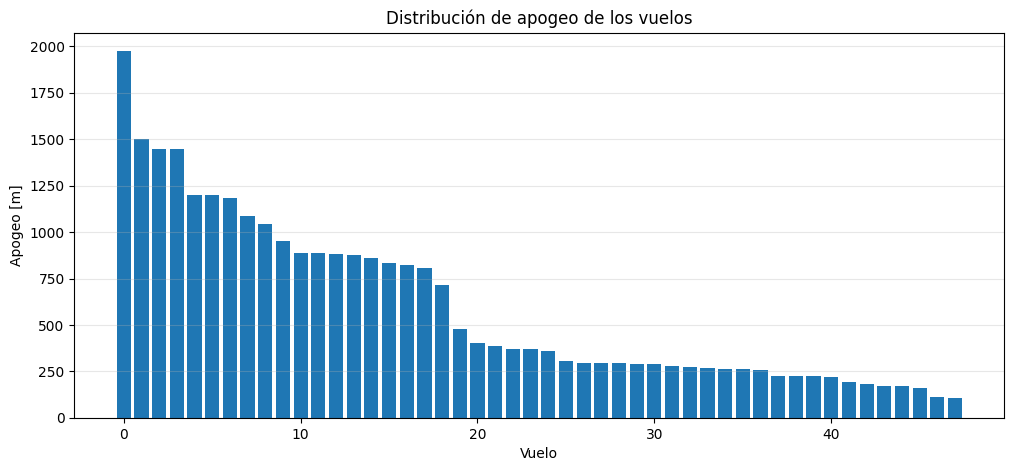

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.bar(
    range(len(apogee_by_flight)),
    apogee_by_flight.values
)

plt.xlabel("Vuelo")
plt.ylabel("Apogeo [m]")
plt.title("Distribución de apogeo de los vuelos")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [52]:
# COMPARAR APOGEOS ENTRE VUELOS

apogee_table = (
    df_model
    .groupby("flight_id")
    .agg(
        apogee=("apogee", "first"),
        samples=("time", "count"),
        duration_s=("time", "max")
    )
    .sort_values("apogee", ascending=False)
)

print("Número de vuelos:", len(apogee_table))

display(apogee_table)

Número de vuelos: 48


,apogee,samples,duration_s
flight_id,,,
39_standardized,1975.329127,3807,190.30
38_standardized,1500.095359,2340,116.95
flightsketch6_standardized,1450.026703,2676,133.75
37_standardized,1450.026703,2676,133.75
36_standardized,1199.585046,2132,106.55
flightsketch5_standardized,1199.585046,2132,106.55
35_standardized,1181.335771,2316,115.75
flightsketch2_standardized,1086.203016,2122,106.05
34_standardized,1044.796373,1935,96.70


In [ ]:
# BUSCAR APOGEOS MUY SIMILARES

apogees = apogee_table.reset_index()

pairs = []

for i in range(len(apogees)):
    
    for j in range(i + 1, len(apogees)):
        
        a1 = apogees.loc[i, "apogee"]
        a2 = apogees.loc[j, "apogee"]
        
        diferencia = abs(a1 - a2)
        
        if diferencia < 1.0:
            pairs.append({
                "flight_1": apogees.loc[i, "flight_id"],
                "flight_2": apogees.loc[j, "flight_id"],
                "apogee_1": a1,
                "apogee_2": a2,
                "diferencia_m": diferencia
            })

df_duplicate_candidates = pd.DataFrame(pairs)

print("Posibles pares replicados:")
display(df_duplicate_candidates)

Posibles pares replicados:


,flight_1,flight_2,apogee_1,apogee_2,diferencia_m
0,flightsketch6_standardized,37_standardized,1450.026703,1450.026703,0.0
1,36_standardized,flightsketch5_standardized,1199.585046,1199.585046,0.0
2,32_standardized,flightsketch3_standardized,887.303935,887.303935,0.0
3,23_standardized,24_standardized,371.381907,371.381907,0.0
4,19_standardized,flightsketch8_standardized,294.733198,294.733198,0.0
5,10_standardized,9_standardized,227.276867,227.276867,0.0
6,e1_replicated_failure_standardized,4_standardized,168.906492,168.906492,0.0


In [54]:
#ELIMINAR VUELOS DUPLICADOS

duplicate_pairs = [
    ("flightsketch6_standardized", "37_standardized"),
    ("36_standardized", "flightsketch5_standardized"),
    ("32_standardized", "flightsketch3_standardized"),
    ("23_standardized", "24_standardized"),
    ("19_standardized", "flightsketch8_standardized"),
    ("10_standardized", "9_standardized"),
    ("e1_replicated_failure_standardized", "4_standardized")
]

# Conservamos el primer vuelo de cada par
flights_to_remove = [pair[1] for pair in duplicate_pairs]

print("Vuelos que serán eliminados por duplicación:")
for flight in flights_to_remove:
    print(" -", flight)

# Crear dataset sin duplicados
df_ml = df_model[
    ~df_model["flight_id"].isin(flights_to_remove)
].copy()

print("\n========================================")
print("DATASET SIN DUPLICADOS")
print("========================================")

print("Número de vuelos:", df_ml["flight_id"].nunique())
print("Número de muestras:", len(df_ml))

print("\nVuelos:")
print(df_ml["flight_id"].unique())

Vuelos que serán eliminados por duplicación:
 - 37_standardized
 - flightsketch5_standardized
 - flightsketch3_standardized
 - 24_standardized
 - flightsketch8_standardized
 - 9_standardized
 - 4_standardized

DATASET SIN DUPLICADOS
Número de vuelos: 41
Número de muestras: 64906

Vuelos:
<StringArray>
[                   '10_standardized',                    '11_standardized',
                    '12_standardized',                    '13_standardized',
                    '14_standardized',                    '15_standardized',
                    '16_standardized',                    '17_standardized',
                    '18_standardized',                    '19_standardized',
                     '1_standardized',                    '20_standardized',
                    '21_standardized',                    '22_standardized',
                    '23_standardized',                    '25_standardized',
                    '26_standardized',                    '27_standardized',
    

In [55]:
#RESUMEN DE LOS VUELOS


flight_summary_ml = (
    df_ml
    .groupby("flight_id")
    .agg(
        samples=("time", "count"),
        duration_s=("time", "max"),
        apogee=("apogee", "first")
    )
    .sort_values("apogee", ascending=False)
)

display(flight_summary_ml)

,samples,duration_s,apogee
flight_id,,,
39_standardized,3807,190.30,1975.329127
38_standardized,2340,116.95,1500.095359
flightsketch6_standardized,2676,133.75,1450.026703
36_standardized,2132,106.55,1199.585046
35_standardized,2316,115.75,1181.335771
flightsketch2_standardized,2122,106.05,1086.203016
34_standardized,1935,96.70,1044.796373
33_standardized,1672,83.55,953.813303
32_standardized,2030,101.45,887.303935


In [56]:
# COMPROBAR DURACIÓN

print("Duración mínima:",
      flight_summary_ml["duration_s"].min(), "s")

print("Duración máxima:",
      flight_summary_ml["duration_s"].max(), "s")

short_flights = flight_summary_ml[
    flight_summary_ml["duration_s"] < 12
]

print("\nVuelos con menos de 12 segundos:")

if len(short_flights) == 0:
    print("Ninguno")
else:
    display(short_flights)

Duración mínima: 16.3 s
Duración máxima: 190.3 s

Vuelos con menos de 12 segundos:
Ninguno


In [57]:
# FUNCIÓN PARA EXTRAER CARACTERÍSTICAS

import numpy as np
import pandas as pd

def extract_features_at_time(flight_df, horizon):
    
    # Datos disponibles solamente hasta el instante seleccionado
    data = flight_df[
        flight_df["time"] <= horizon
    ].copy()
    
    # Si no hay suficientes datos, devolver None
    if len(data) < 2:
        return None
    
    # Última muestra disponible
    last = data.iloc[-1]
    
    # ----------------------------------------
    # Tiempo real disponible
    # ----------------------------------------
    current_time = last["time"]
    
    # ----------------------------------------
    # Altitud
    # ----------------------------------------
    altitude_current = last["baro_altitude"]
    altitude_max = data["baro_altitude"].max()
    
    # ----------------------------------------
    # Velocidad vertical estimada
    # usando diferencia hacia atrás
    # ----------------------------------------
    dt_local = data["time"].iloc[-1] - data["time"].iloc[-2]
    
    if dt_local > 0:
        vertical_velocity = (
            data["baro_altitude"].iloc[-1]
            - data["baro_altitude"].iloc[-2]
        ) / dt_local
    else:
        vertical_velocity = 0.0
    
    # ----------------------------------------
    # Aceleración
    # ----------------------------------------
    At_current = last["At"]
    At_max = data["At"].max()
    At_mean = data["At"].mean()
    At_std = data["At"].std()
    
    # ----------------------------------------
    # Componentes de aceleración
    # ----------------------------------------
    accl_x_mean = data["accl_x"].mean()
    accl_y_mean = data["accl_y"].mean()
    accl_z_mean = data["accl_z"].mean()
    
    accl_x_std = data["accl_x"].std()
    accl_y_std = data["accl_y"].std()
    accl_z_std = data["accl_z"].std()
    
    # ----------------------------------------
    # Giroscopio
    # ----------------------------------------
    gyro_roll = last["gyro_roll"]
    gyro_pitch = last["gyro_pitch"]
    gyro_yaw = last["gyro_yaw"]
    
    # ----------------------------------------
    # VARIABLES ISA
    # ----------------------------------------
    T_current = last["T"]
    P_current = last["P"]
    rho_current = last["rho"]
    a_current = last["a"]
    
    # ----------------------------------------
    # Crear diccionario
    # ----------------------------------------
    features = {
        
        "time": current_time,
        
        "baro_altitude": altitude_current,
        "baro_altitude_max": altitude_max,
        "vertical_velocity": vertical_velocity,
        
        "At": At_current,
        "At_max": At_max,
        "At_mean": At_mean,
        "At_std": At_std,
        
        "accl_x_mean": accl_x_mean,
        "accl_y_mean": accl_y_mean,
        "accl_z_mean": accl_z_mean,
        
        "accl_x_std": accl_x_std,
        "accl_y_std": accl_y_std,
        "accl_z_std": accl_z_std,
        
        "gyro_roll": gyro_roll,
        "gyro_pitch": gyro_pitch,
        "gyro_yaw": gyro_yaw,
        
        "T": T_current,
        "P": P_current,
        "rho": rho_current,
        "a": a_current,
        
        "flight_id": last["flight_id"],
        "apogee": last["apogee"]
    }
    
    return features

In [58]:
#  CREAR DATASETS POR HORIZONTE


horizons = [2, 4, 6, 8, 10, 12]

datasets = {}

for horizon in horizons:
    
    rows = []
    
    for flight_id, flight_df in df_ml.groupby("flight_id"):
        
        features = extract_features_at_time(
            flight_df,
            horizon
        )
        
        if features is not None:
            rows.append(features)
    
    datasets[horizon] = pd.DataFrame(rows)

    print(
        f"{horizon:2d} s → "
        f"{len(datasets[horizon])} vuelos"
    )

 2 s → 41 vuelos
 4 s → 41 vuelos
 6 s → 41 vuelos
 8 s → 41 vuelos
10 s → 41 vuelos
12 s → 41 vuelos


In [59]:
df_6s = datasets[6]

print("Shape:", df_6s.shape)

display(
    df_6s[
        [
            "flight_id",
            "time",
            "baro_altitude",
            "baro_altitude_max",
            "vertical_velocity",
            "At",
            "At_max",
            "T",
            "P",
            "rho",
            "a",
            "apogee"
        ]
    ].head(10)
)

Shape: (41, 23)


,flight_id,time,baro_altitude,baro_altitude_max,vertical_velocity,At,At_max,T,P,rho,a,apogee
0,10_standardized,6.0,115.720951,118.787681,71.430820,19.898452,171.985092,287.397814,99942.513791,1.211460,339.847847,227.276867
1,11_standardized,6.0,83.154493,83.154493,23.837535,10.561783,122.260154,287.609496,100330.022228,1.215263,339.972981,254.725508
2,12_standardized,6.0,84.564838,84.564838,61.599925,9.156884,128.991887,287.600329,100313.215360,1.215098,339.967563,261.587878
3,13_standardized,6.0,54.006966,54.006966,51.521158,29.054813,68.267229,287.798955,100677.879672,1.218673,340.084939,263.156671
4,14_standardized,6.0,51.203741,51.203741,55.947590,32.274455,153.825541,287.817176,100711.385819,1.219002,340.095705,269.514285
5,15_standardized,6.0,175.452033,175.452033,69.652907,2.031634,161.626065,287.009562,99234.923472,1.204511,339.618216,271.307671
6,16_standardized,6.0,108.777418,108.777418,71.749016,27.766683,179.030361,287.442947,100025.033093,1.212270,339.874531,276.145463
7,17_standardized,6.0,168.154471,168.154471,36.514894,12.948673,166.531993,287.056996,99321.154159,1.205358,339.646279,291.122539
8,18_standardized,6.0,74.726332,74.726332,72.197409,19.656474,118.049146,287.664279,100430.506857,1.216248,340.005358,289.153940
9,19_standardized,6.0,59.392417,59.392417,60.376937,20.063246,125.588436,287.763949,100613.534259,1.218043,340.064256,294.733198


In [70]:
# CREAR DATASET 
vuelos_eliminar = [
    "37_standardized",
    "flightsketch5_standardized",
    "flightsketch3_standardized",
    "24_standardized",
    "flightsketch8_standardized",
    "9_standardized",
    "4_standardized"
]

df_ml = df_flight_stats[
    ~df_flight_stats["flight_id"].isin(vuelos_eliminar)
].copy()

print("DATASET")

print("Número de vuelos:", len(df_ml))
print("Número de columnas:", len(df_ml.columns))
print("Shape:", df_ml.shape)

print("\nVuelos:")
print(df_ml["flight_id"].tolist())

print("\nPrimeras filas:")
display(df_ml.head())

DATASET
Número de vuelos: 41
Número de columnas: 11
Shape: (41, 11)

Vuelos:
['10_standardized', '11_standardized', '12_standardized', '13_standardized', '14_standardized', '15_standardized', '16_standardized', '17_standardized', '18_standardized', '19_standardized', '1_standardized', '20_standardized', '21_standardized', '22_standardized', '23_standardized', '25_standardized', '26_standardized', '27_standardized', '28_standardized', '29_standardized', '2_standardized', '30_standardized', '31_standardized', '32_standardized', '33_standardized', '34_standardized', '35_standardized', '36_standardized', '38_standardized', '39_standardized', '3_standardized', '5_standardized', '6_standardized', '7_standardized', '8_standardized', 'e1_replicated_failure_standardized', 'flightsketch1_standardized', 'flightsketch2_standardized', 'flightsketch4_standardized', 'flightsketch6_standardized', 'flightsketch7_standardized']

Primeras filas:


,flight_id,duration_s,altitude_baro_max_m,altitude_gps_max_m,Ax_min,Ax_max,Ay_min,Ay_max,Az_min,Az_max,At_max
0,10_standardized,64.55,227.276867,0.0,-169.127456,135.926388,-36.877150,57.420621,-92.158920,78.278353,171.985092
1,11_standardized,16.30,254.725508,0.0,-155.448118,63.974707,-132.259908,97.869234,-129.131464,145.481117,203.798028
2,12_standardized,51.35,261.587878,0.0,-126.511387,140.282488,-70.269590,76.952030,-157.812830,86.782017,169.344612
3,13_standardized,59.75,263.156671,0.0,-132.527068,90.270921,-72.690948,152.399547,-84.339232,89.175328,182.707057
4,14_standardized,74.80,269.514285,0.0,-111.966845,146.724703,-92.618072,54.670739,-118.037196,45.723282,153.825541


In [ ]:
#verificacion de tamaño del dataset
print("VERIFICACION ")

print("Filas:", len(df_ml))
print("Vuelos unicos:", df_ml["flight_id"].nunique())

duplicados = df_ml["flight_id"].duplicated().sum()

print("Filas duplicadas:", duplicados)

VERIFICACIÓN 
Filas: 41
Vuelos únicos: 41
Filas duplicadas: 0


In [ ]:
#Verificacion de las variables del dataset

print("\nVariables del dataset :")

for i, col in enumerate(df_ml.columns, 1):
    print(f"{i:2d}. {col}")


Variables del dataset :
 1. flight_id
 2. duration_s
 3. altitude_baro_max_m
 4. altitude_gps_max_m
 5. Ax_min
 6. Ax_max
 7. Ay_min
 8. Ay_max
 9. Az_min
10. Az_max
11. At_max


In [ ]:
# Validación de los DataFrames que tengan la variable apogee

for nombre, objeto in globals().items():
    if hasattr(objeto, "columns"):
        if "apogee" in objeto.columns:
            print(
                nombre,
                "->",
                objeto.shape,
                "->",
                objeto.columns.tolist()
            )

df_model -> (77035, 16) -> ['time', 'baro_altitude', 'accl_x', 'accl_y', 'accl_z', 'gps_altitude', 'gyro_roll', 'gyro_pitch', 'gyro_yaw', 'flight_id', 'At', 'T', 'P', 'rho', 'a', 'apogee']
df_flight -> (1003, 16) -> ['time', 'baro_altitude', 'accl_x', 'accl_y', 'accl_z', 'gps_altitude', 'gyro_roll', 'gyro_pitch', 'gyro_yaw', 'flight_id', 'At', 'T', 'P', 'rho', 'a', 'apogee']
apogee_table -> (48, 3) -> ['apogee', 'samples', 'duration_s']
apogees -> (48, 4) -> ['flight_id', 'apogee', 'samples', 'duration_s']
flight_summary_ml -> (41, 3) -> ['samples', 'duration_s', 'apogee']
short_flights -> (0, 3) -> ['samples', 'duration_s', 'apogee']
flight_df -> (1418, 16) -> ['time', 'baro_altitude', 'accl_x', 'accl_y', 'accl_z', 'gps_altitude', 'gyro_roll', 'gyro_pitch', 'gyro_yaw', 'flight_id', 'At', 'T', 'P', 'rho', 'a', 'apogee']
df_6s -> (41, 23) -> ['time', 'baro_altitude', 'baro_altitude_max', 'vertical_velocity', 'At', 'At_max', 'At_mean', 'At_std', 'accl_x_mean', 'accl_y_mean', 'accl_z_mean

In [76]:
# REVISIÓN DEL DATASET df_6s
print("DATASET Final : df_6s")
print("Shape:", df_6s.shape)

print("\nVariables:")

for i, col in enumerate(df_6s.columns, 1):
    print(f"{i:2d}. {col}")

print("\nValores faltantes:")
print(df_6s.isnull().sum())

print("\nNúmero de vuelos:")
print(df_6s["flight_id"].nunique())

print("\nNúmero de filas:")
print(len(df_6s))

print("\n¿Hay flight_id repetidos?")
print(df_6s["flight_id"].duplicated().sum())

DATASET Final : df_6s
Shape: (41, 23)

Variables:
 1. time
 2. baro_altitude
 3. baro_altitude_max
 4. vertical_velocity
 5. At
 6. At_max
 7. At_mean
 8. At_std
 9. accl_x_mean
10. accl_y_mean
11. accl_z_mean
12. accl_x_std
13. accl_y_std
14. accl_z_std
15. gyro_roll
16. gyro_pitch
17. gyro_yaw
18. T
19. P
20. rho
21. a
22. flight_id
23. apogee

Valores faltantes:
time                 0
baro_altitude        0
baro_altitude_max    0
vertical_velocity    0
At                   0
At_max               0
At_mean              0
At_std               0
accl_x_mean          0
accl_y_mean          0
accl_z_mean          0
accl_x_std           0
accl_y_std           0
accl_z_std           0
gyro_roll            0
gyro_pitch           0
gyro_yaw             0
T                    0
P                    0
rho                  0
a                    0
flight_id            0
apogee               0
dtype: int64

Número de vuelos:
41

Número de filas:
41

¿Hay flight_id repetidos?
0


In [77]:
display(
    df_6s.describe().T
)

,count,mean,std,min,25%,50%,75%,max
time,41.0,6.000000,0.000000,6.000000,6.000000,6.000000,6.000000,6.000000
baro_altitude,41.0,103.030916,72.054366,-41.310446,59.392417,83.154493,128.554226,328.852418
baro_altitude_max,41.0,108.301806,71.783411,20.435724,65.616498,84.564838,128.554226,376.053817
vertical_velocity,41.0,84.268658,105.917885,-348.220215,52.407953,72.197409,139.440981,277.086415
At,41.0,43.120089,44.493983,2.020156,12.948673,26.557416,46.973753,201.658052
At_max,41.0,149.300446,47.424547,43.185770,118.049146,148.056800,183.802917,242.444770
At_mean,41.0,29.741654,10.508257,14.638048,22.041718,26.775436,36.981539,59.088826
At_std,41.0,39.525458,17.280814,7.259444,29.959509,36.842010,50.368266,84.884312
accl_x_mean,41.0,-10.505497,20.668187,-52.742170,-23.373635,-15.723709,-3.107970,45.407206
accl_y_mean,41.0,-3.219104,13.864841,-35.611514,-10.402060,-2.316010,1.174157,38.622882


In [78]:
# CORRELACIÓN CON APOGEO

corr = (
    df_6s
    .drop(columns=["flight_id"])
    .corr()["apogee"]
    .sort_values(ascending=False)
)

display(corr)

apogee               1.000000
At_mean              0.870204
At_std               0.781352
At                   0.643471
vertical_velocity    0.560914
accl_x_std           0.545001
baro_altitude        0.542273
baro_altitude_max    0.524620
At_max               0.416910
accl_y_std           0.344484
accl_z_std           0.258766
accl_y_mean          0.040527
accl_z_mean          0.007388
accl_x_mean         -0.069475
P                   -0.544317
rho                 -0.544393
T                   -0.544636
a                   -0.544673
time                      NaN
gyro_roll                 NaN
gyro_pitch                NaN
gyro_yaw                  NaN
Name: apogee, dtype: float64

In [80]:

# VARIABLES PARA PREDICCION A CONSIDERAR A 6 SEGUNDOS DEL VUELO

features_6s = [
    'baro_altitude',
    'baro_altitude_max',
    'vertical_velocity',
    'At',
    'At_max',
    'At_mean',
    'At_std',
    'accl_x_mean',
    'accl_y_mean',
    'accl_z_mean',
    'accl_x_std',
    'accl_y_std',
    'accl_z_std',
    'T',
    'P',
    'rho',
    'a'
]

target = 'apogee'

print("VARIABLES ")

print("\nVariables predictoras:")
for i, col in enumerate(features_6s, 1):
    print(f"{i:2d}. {col}")

print("\nVariable objetivo:")
print(target)

# Crear X e y
X = df_6s[features_6s].copy()
y = df_6s[target].copy()

print("\nShape X:", X.shape)
print("Shape y:", y.shape)

print("\n¿Hay valores NaN?")
print(X.isna().sum().sum())

print("\n¿Hay valores infinitos?")
print(np.isinf(X).sum().sum())

print("\nEstadísticas de X:")
display(X.describe().T)

print("\nEstadísticas de y:")
display(y.describe())

VARIABLES 

Variables predictoras:
 1. baro_altitude
 2. baro_altitude_max
 3. vertical_velocity
 4. At
 5. At_max
 6. At_mean
 7. At_std
 8. accl_x_mean
 9. accl_y_mean
10. accl_z_mean
11. accl_x_std
12. accl_y_std
13. accl_z_std
14. T
15. P
16. rho
17. a

Variable objetivo:
apogee

Shape X: (41, 17)
Shape y: (41,)

¿Hay valores NaN?
0

¿Hay valores infinitos?
0

Estadísticas de X:


,count,mean,std,min,25%,50%,75%,max
baro_altitude,41.0,103.030916,72.054366,-41.310446,59.392417,83.154493,128.554226,328.852418
baro_altitude_max,41.0,108.301806,71.783411,20.435724,65.616498,84.564838,128.554226,376.053817
vertical_velocity,41.0,84.268658,105.917885,-348.220215,52.407953,72.197409,139.440981,277.086415
At,41.0,43.120089,44.493983,2.020156,12.948673,26.557416,46.973753,201.658052
At_max,41.0,149.300446,47.424547,43.185770,118.049146,148.056800,183.802917,242.444770
At_mean,41.0,29.741654,10.508257,14.638048,22.041718,26.775436,36.981539,59.088826
At_std,41.0,39.525458,17.280814,7.259444,29.959509,36.842010,50.368266,84.884312
accl_x_mean,41.0,-10.505497,20.668187,-52.742170,-23.373635,-15.723709,-3.107970,45.407206
accl_y_mean,41.0,-3.219104,13.864841,-35.611514,-10.402060,-2.316010,1.174157,38.622882
accl_z_mean,41.0,0.925341,11.907745,-27.224319,-3.157127,0.595991,6.505567,26.994490



Estadísticas de y:


count      41.000000
mean      579.458602
std       449.930448
min       108.392732
25%       261.587878
50%       360.780665
75%       878.500929
max      1975.329127
Name: apogee, dtype: float64

In [ ]:
#ANTES DE DESARROLLAR EL MODELO,VERIFICAREMOS LA IMPORTANCIA DE LAS VARIABLES DE ENTRADA
#PARA LA PREDICCION DEL APOGEO,ESTO CON EL FIN DE 
#NO SOBRECARGAR EL MODELO CON VARIABLES QUE NO APORTEN INFORMACION RELEVANTE O REDUNDANTE


In [82]:
# MATRIZ DE CORRELACIÓN DE VARIABLES X

import pandas as pd
import numpy as np

corr_X = X.corr()

print("MATRIZ DE CORRELACIÓN")

display(corr_X.round(2))

MATRIZ DE CORRELACIÓN


,baro_altitude,baro_altitude_max,vertical_velocity,At,At_max,At_mean,At_std,accl_x_mean,accl_y_mean,accl_z_mean,accl_x_std,accl_y_std,accl_z_std,T,P,rho,a
baro_altitude,1.00,0.96,0.75,0.03,0.53,0.71,0.62,-0.16,0.40,0.11,0.32,0.23,0.55,-1.00,-1.00,-1.00,-1.00
baro_altitude_max,0.96,1.00,0.58,0.10,0.51,0.74,0.62,-0.18,0.49,0.13,0.31,0.33,0.54,-0.98,-0.98,-0.98,-0.98
vertical_velocity,0.75,0.58,1.00,0.04,0.41,0.54,0.45,-0.09,0.15,0.01,0.37,0.02,0.27,-0.71,-0.72,-0.71,-0.71
At,0.03,0.10,0.04,1.00,0.23,0.44,0.41,-0.20,0.04,-0.01,0.48,0.06,-0.09,-0.06,-0.05,-0.05,-0.06
At_max,0.53,0.51,0.41,0.23,1.00,0.56,0.76,-0.04,0.10,0.00,0.59,0.10,0.34,-0.53,-0.54,-0.54,-0.53
At_mean,0.71,0.74,0.54,0.44,0.56,1.00,0.89,-0.04,0.26,0.01,0.60,0.45,0.39,-0.73,-0.73,-0.73,-0.73
At_std,0.62,0.62,0.45,0.41,0.76,0.89,1.00,-0.04,0.05,0.00,0.69,0.35,0.42,-0.63,-0.63,-0.63,-0.63
accl_x_mean,-0.16,-0.18,-0.09,-0.20,-0.04,-0.04,-0.04,1.00,-0.15,-0.12,-0.15,0.01,0.06,0.17,0.17,0.17,0.17
accl_y_mean,0.40,0.49,0.15,0.04,0.10,0.26,0.05,-0.15,1.00,0.15,0.22,-0.18,0.08,-0.43,-0.43,-0.43,-0.43
accl_z_mean,0.11,0.13,0.01,-0.01,0.00,0.01,0.00,-0.12,0.15,1.00,-0.05,-0.01,0.09,-0.12,-0.12,-0.12,-0.12


In [83]:
# DETECCION DE VARIABLES MUY CORRELACIONADAS

threshold = 0.90

corr_pairs = (
    corr_X
    .where(np.triu(np.ones(corr_X.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=lambda x: abs(x), ascending=False)
)

print("PARES CON |CORRELACION| >= 0.90")

for (var1, var2), corr in corr_pairs.items():
    if abs(corr) >= threshold:
        print(f"{var1:25s} <-> {var2:25s} : {corr:.4f}")

PARES CON |CORRELACION| >= 0.90
T                         <-> a                         : 1.0000
P                         <-> rho                       : 1.0000
T                         <-> rho                       : 1.0000
rho                       <-> a                         : 1.0000
T                         <-> P                         : 1.0000
P                         <-> a                         : 1.0000
baro_altitude             <-> P                         : -0.9964
baro_altitude             <-> rho                       : -0.9963
baro_altitude             <-> T                         : -0.9962
baro_altitude             <-> a                         : -0.9962
baro_altitude_max         <-> a                         : -0.9776
baro_altitude_max         <-> T                         : -0.9775
baro_altitude_max         <-> rho                       : -0.9770
baro_altitude_max         <-> P                         : -0.9769
baro_altitude             <-> baro_altitude_max   

In [84]:
# REDUCCION DE VARIABLES POR REDUNDANCIA

variables_eliminar = [
    'T',
    'rho',
    'a'
]

variables_conservadas = [
    col for col in X.columns
    if col not in variables_eliminar
]

X_reducida = X[variables_conservadas].copy()

print("DATASET REDUCIDO")

print("\nVariables originales:", X.shape[1])
print("Variables después de reducción:", X_reducida.shape[1])

print("\nVariables eliminadas:")
for var in variables_eliminar:
    print(" -", var)

print("\nVariables conservadas:")
for i, var in enumerate(X_reducida.columns, 1):
    print(f"{i:2d}. {var}")

print("\nShape X_reducida:", X_reducida.shape)
print("Shape y:", y.shape)

DATASET REDUCIDO

Variables originales: 17
Variables después de reducción: 14

Variables eliminadas:
 - T
 - rho
 - a

Variables conservadas:
 1. baro_altitude
 2. baro_altitude_max
 3. vertical_velocity
 4. At
 5. At_max
 6. At_mean
 7. At_std
 8. accl_x_mean
 9. accl_y_mean
10. accl_z_mean
11. accl_x_std
12. accl_y_std
13. accl_z_std
14. P

Shape X_reducida: (41, 14)
Shape y: (41,)


In [85]:
# CORRELACION DE LAS VARIABLES CON EL APOGEO

correlacion_apogee = X_reducida.copy()
correlacion_apogee['apogee'] = y

corr_apogee = (
    correlacion_apogee
    .corr()['apogee']
    .drop('apogee')
    .sort_values(key=abs, ascending=False)
)

print("CORRELACION CON APOGEE")

for variable, valor in corr_apogee.items():
    print(f"{variable:20s} : {valor: .4f}")

CORRELACION CON APOGEE
At_mean              :  0.8702
At_std               :  0.7814
At                   :  0.6435
vertical_velocity    :  0.5609
accl_x_std           :  0.5450
P                    : -0.5443
baro_altitude        :  0.5423
baro_altitude_max    :  0.5246
At_max               :  0.4169
accl_y_std           :  0.3445
accl_z_std           :  0.2588
accl_x_mean          : -0.0695
accl_y_mean          :  0.0405
accl_z_mean          :  0.0074


In [86]:
# SELECCION PRELIMINAR DE VARIABLES

variables_eliminar = [
    'accl_x_mean',
    'accl_y_mean',
    'accl_z_mean'
]

variables_seleccionadas = [
    col for col in X_reducida.columns
    if col not in variables_eliminar
]

X_seleccionada = X_reducida[variables_seleccionadas].copy()

print("SELECCIÓN PRELIMINAR DE VARIABLES")
print("\nVariables eliminadas:")
for var in variables_eliminar:
    print(" -", var)

print("\nVariables seleccionadas:")

for i, var in enumerate(X_seleccionada.columns, 1):
    print(f"{i:2d}. {var}")

print("\nShape original:")
print(X_reducida.shape)

print("\nShape seleccionada:")
print(X_seleccionada.shape)

print("\nShape objetivo:")
print(y.shape)

print("\n¿Hay NaN?")
print(X_seleccionada.isna().sum().sum())

print("\n¿Hay infinitos?")
print(np.isinf(X_seleccionada).sum().sum())

SELECCIÓN PRELIMINAR DE VARIABLES

Variables eliminadas:
 - accl_x_mean
 - accl_y_mean
 - accl_z_mean

Variables seleccionadas:
 1. baro_altitude
 2. baro_altitude_max
 3. vertical_velocity
 4. At
 5. At_max
 6. At_mean
 7. At_std
 8. accl_x_std
 9. accl_y_std
10. accl_z_std
11. P

Shape original:
(41, 14)

Shape seleccionada:
(41, 11)

Shape objetivo:
(41,)

¿Hay NaN?
0

¿Hay infinitos?
0


In [87]:

# DATASET FINAL (ESTE ES EL BUENO)

X_final = X_seleccionada.copy()
y_final = y.copy()
print("DATASET FINAL (ESTE ES EL BUENO)")

print("\nNúmero de vuelos:", len(X_final))
print("Número de variables predictoras:", X_final.shape[1])

print("\nVariables X:")
for i, variable in enumerate(X_final.columns, 1):
    print(f"{i:2d}. {variable}")

print("\nVariable objetivo:")
print("apogee")

print("\nShape X:", X_final.shape)
print("Shape y:", y_final.shape)

print("\n¿NaN en X?", X_final.isna().sum().sum())
print("¿Infinitos en X?", np.isinf(X_final).sum().sum())
print("¿NaN en y?", y_final.isna().sum())
print("¿Infinitos en y?", np.isinf(y_final).sum())

DATASET FINAL (ESTE ES EL BUENO)

Número de vuelos: 41
Número de variables predictoras: 11

Variables X:
 1. baro_altitude
 2. baro_altitude_max
 3. vertical_velocity
 4. At
 5. At_max
 6. At_mean
 7. At_std
 8. accl_x_std
 9. accl_y_std
10. accl_z_std
11. P

Variable objetivo:
apogee

Shape X: (41, 11)
Shape y: (41,)

¿NaN en X? 0
¿Infinitos en X? 0
¿NaN en y? 0
¿Infinitos en y? 0


In [ ]:
#AHORA POR FIN TENEMOS NUESTRO DATASET COMPLETO 
#SIGUIENDO LA TRADICION DE ENTRENAMIENTOS DE ML 
#SE DICE QUE SEGUN EL NUMERO TOTAL DE VUELOS DISPONIBLES, SE DEBE DIVIDIR EL DATASET EN 3 PARTES
#ENTRENAMIENTO,VALIDACION Y PRUEBA
#PARA NUESTRO CASO, TENIENDO 41 VUELOS DISPONIBLES, SEGUIREMOS LA REGLA DE 60% ENTRENAMIENTO, 20% VALIDACION Y 20% PRUEBA
#ESTO CORRESPONDE A:
#25 VUELOS PARA ENTRENAMIENTO
#8 VUELOS PARA VALIDACION
#8 VUELOS PARA PRUEBA

In [89]:

# DIVISION 60% TRAIN / 20% VALIDATION / 20% TEST

from sklearn.model_selection import train_test_split

# Primera división:
# 60% entrenamiento
# 40% temporal (validación + prueba)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_final,
    y_final,
    test_size=0.40,
    random_state=42
)

# Segunda división:
# La mitad del 40% temporal será validación
# y la otra mitad será prueba

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("DIVISION 60% / 20% / 20%")
print("\nDataset completo:")
print("X:", X_final.shape)
print("y:", y_final.shape)

print("\nENTRENAMIENTO:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nVALIDACIÓN:")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\nPRUEBA:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

DIVISION 60% / 20% / 20%

Dataset completo:
X: (41, 11)
y: (41,)

ENTRENAMIENTO:
X_train: (24, 11)
y_train: (24,)

VALIDACIÓN:
X_val: (8, 11)
y_val: (8,)

PRUEBA:
X_test: (9, 11)
y_test: (9,)


In [90]:
# MODELO BASE — PREDICCIÓN CON LA MEDIA

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predicción base:
# utilizamos únicamente la media de los apogeos
# del conjunto de entrenamiento

baseline_value = y_train.mean()

y_val_baseline = np.full(len(y_val), baseline_value)

# Métricas sobre validación
mae_baseline = mean_absolute_error(y_val, y_val_baseline)

rmse_baseline = np.sqrt(
    mean_squared_error(y_val, y_val_baseline)
)

r2_baseline = r2_score(y_val, y_val_baseline)

print("MODELO BASE — PREDICCIÓN CON LA MEDIA")

print(f"\nMedia del apogeo en entrenamiento: {baseline_value:.2f} m")

print("\nResultados sobre VALIDACIÓN:")
print(f"MAE  : {mae_baseline:.2f} m")
print(f"RMSE : {rmse_baseline:.2f} m")
print(f"R²   : {r2_baseline:.4f}")

MODELO BASE — PREDICCIÓN CON LA MEDIA

Media del apogeo en entrenamiento: 494.65 m

Resultados sobre VALIDACIÓN:
MAE  : 422.49 m
RMSE : 500.92 m
R²   : -0.4984


In [ ]:
#PODRAN OBSERVAR QUE R_2 DA UN VALOR NEGATIVO, ESTO ES PORQUE EL MODELO BASE ES MUY MALO, 
# YA QUE NO CONSIDERA NINGUNA VARIABLE DE ENTRADA, SOLO LA MEDIA DE LOS APOGEOS 
# DEL CONJUNTO DE ENTRENAMIENTO,NO SE PREOCUPEN TIENE QUE IR MEJORANDO (O NO?)

In [93]:
#A CAUSA DE LA DIFERENCI A NUMERICA DE NUESTRAS VARIABLES DE ENTRADA, ES NECESARIO ESCALAR LOS DATOS 
# PARA QUE EL MODELO DE RED NEURONAL PUEDA ENTENDERLOS MEJOR

from sklearn.preprocessing import StandardScaler

# Crear escalador
scaler = StandardScaler()

# AJUSTAR SOLO con entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Transformar validación y prueba
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("ESCALAMIENTO")

print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled  :", X_val_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

print("\nMedia de X_train_scaled:")
print(X_train_scaled.mean(axis=0))

print("\nDesviación estándar de X_train_scaled:")
print(X_train_scaled.std(axis=0))

ESCALAMIENTO
X_train_scaled: (24, 11)
X_val_scaled  : (8, 11)
X_test_scaled : (9, 11)

Media de X_train_scaled:
[ 9.25185854e-18 -2.22044605e-16  9.25185854e-18 -9.25185854e-18
 -1.11022302e-16 -3.14563190e-16 -4.02455846e-16  7.40148683e-17
  9.25185854e-17 -5.55111512e-17 -1.63734766e-14]

Desviación estándar de X_train_scaled:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
#ANTES DE APLICAR CUALQUIER MODELO LSTM ,UTILIZAREMOS MODELOS MÁS SENCILLOS COMO EL DE REGRESIÓN LINEAL 
# PARA TENER UNA IDEA DE LA PREDICCIÓN DEL APOGEO, Y PODER COMPARARLO CON EL MODELO BASE, 
# Y POSTERIORMENTE APLICAREMOS EL MODELO LSTM PARA VER SI PODEMOS MEJORAR LA PREDICCIÓN

In [94]:
# MODELO REGRESION LINEAL

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Crear modelo
modelo_lr = LinearRegression()

# Entrenamiento
modelo_lr.fit(X_train_scaled, y_train)

# Predicción sobre validación
y_val_pred_lr = modelo_lr.predict(X_val_scaled)

# Métricas
mae_lr = mean_absolute_error(y_val, y_val_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_val, y_val_pred_lr))
r2_lr = r2_score(y_val, y_val_pred_lr)
print("REGRESIÓN LINEAL")
print(f"MAE  : {mae_lr:.2f} m")
print(f"RMSE : {rmse_lr:.2f} m")
print(f"R²   : {r2_lr:.4f}")

REGRESIÓN LINEAL
MAE  : 179.66 m
RMSE : 212.15 m
R²   : 0.7312


In [ ]:
#DE LOS RESULTADOS OBSERVAMOS QUE EL MODELO DE REGRESIÓN LINEAL 
# YA TIENE UN MEJOR DESEMPEÑO QUE EL MODELO BASE,AHORA PROBEMOS CON UN MODELO MÁS COMPLEJO 
# COMO EL RANDOM FOREST, QUE ES UN MODELO DE ENSAMBLAJE BASADO EN ÁRBOLES DE DECISIÓN,

In [95]:
# MODELO RANDOM FOREST

from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

# Entrenamiento
modelo_rf.fit(X_train_scaled, y_train)

# Predicción sobre VALIDACIÓN
y_val_pred_rf = modelo_rf.predict(X_val_scaled)

# Métricas
mae_rf = mean_absolute_error(y_val, y_val_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))
r2_rf = r2_score(y_val, y_val_pred_rf)

print("RANDOM FOREST")

print(f"MAE  : {mae_rf:.2f} m")
print(f"RMSE : {rmse_rf:.2f} m")
print(f"R²   : {r2_rf:.4f}")

RANDOM FOREST
MAE  : 180.32 m
RMSE : 214.86 m
R²   : 0.7243


In [ ]:
#COMO PUEDEN VER DIO RESULTADOS SIMILARES AL MODELO DE REGRESIÓN LINEAL, 
# AHORA ANTES DE COMENZAR A TRABAJAR EN LA RED NEURONAL LSTM VAMOS A COMPROBAR 
# LA DISTRIBUCION DE CADA UNO DE LOS VUELOS EN NUESTRO DATASET

In [96]:
# PREPARACION PARA LSTM

samples_per_flight = df_model.groupby("flight_id").size()

print("MUESTRAS POR VUELO")

print(samples_per_flight)

print("\nEstadísticas:")
print(samples_per_flight.describe())

MUESTRAS POR VUELO
flight_id
10_standardized                       1292
11_standardized                        327
12_standardized                       1028
13_standardized                       1196
14_standardized                       1497
15_standardized                       1066
16_standardized                       1344
17_standardized                       1382
18_standardized                       1003
19_standardized                       1003
1_standardized                        1003
20_standardized                       1886
21_standardized                       1003
22_standardized                       1224
23_standardized                       1993
24_standardized                       1993
25_standardized                       1003
26_standardized                       1003
27_standardized                       1758
28_standardized                       1538
29_standardized                       1568
2_standardized                        1003
30_standardized          

In [ ]:
#AHORA SI SE VIENE LO CHIDO,EMPEZAMOS A TRABAJAR CON LA RED NEURONAL LSTM, 

In [97]:
# LSTM — IMPORTACIÓN DE LIBRERÍAS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)

TensorFlow: 2.21.0
NumPy: 2.3.5


In [104]:
# VARIABLES ORIGINALES DISPONIBLES PARA EL LSTM

print("VARIABLES DISPONIBLES EN df_model")

for i, col in enumerate(df_model.columns, 1):
    print(f"{i:2d}. {col}")

print("\nNúmero de variables:", len(df_model.columns))

VARIABLES DISPONIBLES EN df_model
 1. time
 2. baro_altitude
 3. accl_x
 4. accl_y
 5. accl_z
 6. gps_altitude
 7. gyro_roll
 8. gyro_pitch
 9. gyro_yaw
10. flight_id
11. At
12. T
13. P
14. rho
15. a
16. apogee

Número de variables: 16


In [105]:
# CORRELACIÓN DE VARIABLES ORIGINALES CON APOGEE

corr_originales = df_model.select_dtypes(
    include=np.number
).corr()["apogee"].sort_values(
    ascending=False
)
print("CORRELACIÓN CON APOGEE")
print(corr_originales)

CORRELACIÓN CON APOGEE
apogee           1.000000
baro_altitude    0.639585
time             0.413489
accl_y           0.146895
accl_x           0.093045
At               0.047261
accl_z           0.019026
a               -0.639667
T               -0.639702
P               -0.639783
rho             -0.639798
gps_altitude          NaN
gyro_roll             NaN
gyro_pitch            NaN
gyro_yaw              NaN
Name: apogee, dtype: float64


In [ ]:
#CON EL FIN DE ENCONTRAR LAS SERIES TEMPORALES MÁS RELEVANTES PARA LA PREDICCIÓN DEL APOGEO,
#VAMOS A REDUCIR POR AHORA LAS VARIABLES A 6,EN ESTE CASO SERIAN 
#1. baro_altitude
#2. accl_x
#3. accl_y
#4. accl_z
#5. At
#6. P

In [107]:
# CONSTRUCCIÓN DEL DATASET LSTM
# 6 segundos A 20 Hz


WINDOW_SIZE = 121

features_lstm = [
    "baro_altitude",
    "accl_x",
    "accl_y",
    "accl_z",
    "At",
    "P"
]

# Vuelos válidos
valid_flights = df_6s["flight_id"].tolist()

X_sequences = []
y_sequences = []
flight_ids_lstm = []

for flight_id in valid_flights:

    # Seleccionar vuelo
    flight_data = df_model[
        df_model["flight_id"] == flight_id
    ].sort_values("time")

    # Tomar los primeros 121 puntos
    window = flight_data.iloc[:WINDOW_SIZE]

    # Verificar tamaño
    if len(window) == WINDOW_SIZE:

        X_seq = window[features_lstm].values

        # Apogeo correspondiente al vuelo
        y_value = window["apogee"].iloc[0]

        X_sequences.append(X_seq)
        y_sequences.append(y_value)
        flight_ids_lstm.append(flight_id)

# Convertir a NumPy
X_LSTM = np.array(X_sequences, dtype=np.float32)
y_LSTM = np.array(y_sequences, dtype=np.float32)

print("DATASET PARA LSTM")

print("\nNúmero de vuelos:", len(flight_ids_lstm))

print("X_LSTM:", X_LSTM.shape)
print("y_LSTM:", y_LSTM.shape)

print("\nVariables de entrada:")
for i, feature in enumerate(features_lstm, 1):
    print(f"{i}. {feature}")

print("\nPrimer vuelo:")
print(flight_ids_lstm[0])

print("\nPrimeras 3 muestras:")
print(X_LSTM[0][:3])

print("\nApogeo primer vuelo:")
print(y_LSTM[0])

DATASET PARA LSTM

Número de vuelos: 41
X_LSTM: (41, 121, 6)
y_LSTM: (41,)

Variables de entrada:
1. baro_altitude
2. accl_x
3. accl_y
4. accl_z
5. At
6. P

Primer vuelo:
10_standardized

Primeras 3 muestras:
[[-3.7690061e-03 -6.5985503e+00 -2.4121988e-01 -6.6623783e-01
   6.6364846e+00  1.0132500e+05]
 [-7.6606058e-02 -1.0105014e+01 -3.3813217e-01 -1.0115964e+00
   1.0161149e+01  1.0132500e+05]
 [-1.2613498e-01 -9.1098804e+00 -3.4541938e-01 -8.9614862e-01
   9.1603670e+00  1.0132500e+05]]

Apogeo primer vuelo:
227.27687


In [115]:

print("VERIFICACIÓN DE VARIABLES LSTM")

print("X_LSTM:", X_LSTM.shape)
print("y_LSTM:", y_LSTM.shape)

print("\nX_train actual:", X_train.shape)
print("X_val actual:", X_val.shape)
print("X_test actual:", X_test.shape)

VERIFICACIÓN DE VARIABLES LSTM
X_LSTM: (41, 121, 6)
y_LSTM: (41,)

X_train actual: (24, 11)
X_val actual: (8, 11)
X_test actual: (9, 11)


In [116]:
from sklearn.model_selection import train_test_split
# DIVISIÓN ESPECÍFICA PARA LSTM

X_lstm_train, X_lstm_temp, y_lstm_train, y_lstm_temp = train_test_split(
    X_LSTM,
    y_LSTM,
    test_size=17,
    random_state=42
)

X_lstm_val, X_lstm_test, y_lstm_val, y_lstm_test = train_test_split(
    X_lstm_temp,
    y_lstm_temp,
    test_size=9,
    random_state=42
)

print("DIVISIÓN DATASET LSTM")

print("\nENTRENAMIENTO:")
print("X_lstm_train:", X_lstm_train.shape)
print("y_lstm_train:", y_lstm_train.shape)

print("\nVALIDACIÓN:")
print("X_lstm_val:", X_lstm_val.shape)
print("y_lstm_val:", y_lstm_val.shape)

print("\nPRUEBA:")
print("X_lstm_test:", X_lstm_test.shape)
print("y_lstm_test:", y_lstm_test.shape)

DIVISIÓN DATASET LSTM

ENTRENAMIENTO:
X_lstm_train: (24, 121, 6)
y_lstm_train: (24,)

VALIDACIÓN:
X_lstm_val: (8, 121, 6)
y_lstm_val: (8,)

PRUEBA:
X_lstm_test: (9, 121, 6)
y_lstm_test: (9,)


In [118]:
from sklearn.preprocessing import StandardScaler
# ESCALAMIENTO LSTM

n_features = X_lstm_train.shape[2]

scaler_lstm = StandardScaler()

# Convertir 3D → 2D
X_lstm_train_2d = X_lstm_train.reshape(-1, n_features)
X_lstm_val_2d = X_lstm_val.reshape(-1, n_features)
X_lstm_test_2d = X_lstm_test.reshape(-1, n_features)

# Ajustar SOLO con entrenamiento
scaler_lstm.fit(X_lstm_train_2d)

# Transformar
X_lstm_train_scaled = scaler_lstm.transform(X_lstm_train_2d)
X_lstm_val_scaled = scaler_lstm.transform(X_lstm_val_2d)
X_lstm_test_scaled = scaler_lstm.transform(X_lstm_test_2d)

# Regresar a 3D
X_lstm_train_scaled = X_lstm_train_scaled.reshape(
    X_lstm_train.shape
)

X_lstm_val_scaled = X_lstm_val_scaled.reshape(
    X_lstm_val.shape
)

X_lstm_test_scaled = X_lstm_test_scaled.reshape(
    X_lstm_test.shape
)

print("ESCALAMIENTO LSTM")

print("X_lstm_train_scaled:", X_lstm_train_scaled.shape)
print("X_lstm_val_scaled  :", X_lstm_val_scaled.shape)
print("X_lstm_test_scaled :", X_lstm_test_scaled.shape)

print("\nMedia:")
print(
    X_lstm_train_scaled
    .reshape(-1, n_features)
    .mean(axis=0)
)

print("\nDesviación estándar:")
print(
    X_lstm_train_scaled
    .reshape(-1, n_features)
    .std(axis=0)
)

ESCALAMIENTO LSTM
X_lstm_train_scaled: (24, 121, 6)
X_lstm_val_scaled  : (8, 121, 6)
X_lstm_test_scaled : (9, 121, 6)

Media:
[-2.8735021e-09 -2.0935516e-09 -1.3127800e-07 -9.3193833e-08
 -1.8062014e-08 -6.0355860e-06]

Desviación estándar:
[1.0000007  1.0000004  0.9999997  0.99999905 1.0000006  1.0000046 ]


In [ ]:
#YA UNA VEZ CON TODOS ESTOS DATOS CORREGIDOS,CON SU SECUENCIA TEMPORAL Y ESCALADOS 
#PROCEDEMOS A CONSTRUIR EL MODELO LSTM,QUE ES EL OBJETIVO FINAL DE ESTE PROYECTO,
#ESTE MODELO CUENTA CON La arquitectura propuesta tiene una capa recurrente LSTM de 32 unidades,
# seguida de una capa Dropout, una capa densa de 16 neuronas y una capa de salida densa de una neurona.
# La entrada consiste en secuencias de 121 pasos temporales con 6 variables por paso.
#Utiliza unidades recurrentes LSTM en la primera capa y neuronas densamente conectadas (Dense) 
# con activación ReLU en la capa intermedia y una neurona lineal en la salida para realizar la regresión del apogeo.

In [120]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

model_lstm = Sequential([
    
    Input(shape=(121, 6)),
    
    LSTM(32),
    
    Dropout(0.2),
    
    Dense(16, activation="relu"),
    
    Dense(1)
])

model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="mae")
    ]
)

model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,537 (21.63 KB)

 Trainable params: 5,537 (21.63 KB)

 Non-trainable params: 0 (0.00 B)

In [123]:
# CREACIÓN DEL MODELO LSTM

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense

# Dimensiones de entrada
n_timesteps = X_lstm_train_scaled.shape[1]
n_features = X_lstm_train_scaled.shape[2]

print("Timesteps:", n_timesteps)
print("Variables por timestep:", n_features)

# Crear modelo
model = Sequential([
    
    Input(shape=(n_timesteps, n_features)),
    
    # Capa LSTM
    LSTM(32),
    
    # Regularización
    Dropout(0.2),
    
    # Capa completamente conectada
    Dense(16, activation='relu'),
    
    # Salida: predicción del apogeo
    Dense(1)
])

# Compilar
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Mostrar arquitectura
model.summary()

Timesteps: 121
Variables por timestep: 6


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 32)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,537 (21.63 KB)

 Trainable params: 5,537 (21.63 KB)

 Non-trainable params: 0 (0.00 B)

In [124]:
# ENTRENAMIENTO DEL MODELO LSTM


from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_lstm_train_scaled,
    y_train,
    validation_data=(X_lstm_val_scaled, y_val),
    epochs=300,
    batch_size=4,
    callbacks=[early_stopping],
    verbose=1
)

print("\n" + "="*60)
print("ENTRENAMIENTO FINALIZADO")
print("="*60)

print("Épocas ejecutadas:", len(history.history['loss']))
print("Mejor loss entrenamiento:",
      min(history.history['loss']))

print("Mejor loss validación:",
      min(history.history['val_loss']))

Epoch 1/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - loss: 394847.1250 - mae: 494.4389 - val_loss: 780798.5000 - val_mae: 783.1426
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 394642.9688 - mae: 494.1703 - val_loss: 780491.0000 - val_mae: 782.9345
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 394433.3750 - mae: 493.9911 - val_loss: 780171.6875 - val_mae: 782.7181
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 394221.2500 - mae: 493.7813 - val_loss: 779808.8125 - val_mae: 782.4728
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 393904.2500 - mae: 493.4378 - val_loss: 779384.4375 - val_mae: 782.1807
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 393560.1562 - mae: 493.0911 - val_loss: 778844.1250 - val_mae: 781.8068
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 393186.6562 - mae: 492.6884 - val_loss: 778184.8125 - val_mae: 781.3559
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 392639.8750 - mae: 492.0453 - v

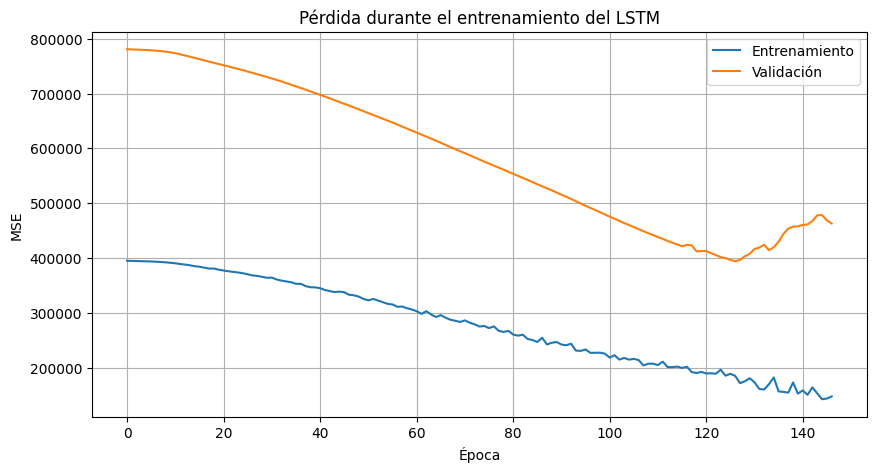

In [125]:
# CURVAS DE ENTRENAMIENTO DEL LSTM

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')

plt.xlabel('Época')
plt.ylabel('MSE')
plt.title('Pérdida durante el entrenamiento del LSTM')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#El modelo continúa aprendiendo cada vez mejor los 24 vuelos de entrenamiento, 
# pero después de aproximadamente la época 127 empieza a perder capacidad de generalización 
# sobre los 8 vuelos de validación.

In [127]:
# MEJOR ÉPOCA DEL ENTRENAMIENTO

import numpy as np

# Índice de la época con menor pérdida de validación
best_epoch = np.argmin(history.history['val_loss'])

# Valores correspondientes
best_val_loss = history.history['val_loss'][best_epoch]
best_train_loss = history.history['loss'][best_epoch]

# Convertir MSE a RMSE
best_val_rmse = np.sqrt(best_val_loss)
best_train_rmse = np.sqrt(best_train_loss)

print("MEJOR ÉPOCA DEL LSTM")

print(f"Mejor época: {best_epoch + 1}")

print(f"\nTraining:")
print(f"  MSE  : {best_train_loss:.2f}")
print(f"  RMSE : {best_train_rmse:.2f} m")

print(f"\nValidation:")
print(f"  MSE  : {best_val_loss:.2f}")
print(f"  RMSE : {best_val_rmse:.2f} m")

MEJOR ÉPOCA DEL LSTM
Mejor época: 127

Training:
  MSE  : 184915.31
  RMSE : 430.02 m

Validation:
  MSE  : 394046.94
  RMSE : 627.73 m


In [129]:
# PREDICCIONES LSTM SOBRE VALIDACIÓN

import numpy as np
import pandas as pd

# Predicciones
y_val_pred = model.predict(
    X_lstm_val_scaled,
    verbose=0
).flatten()

# Crear tabla de resultados
resultados_val = pd.DataFrame({
    'Apogeo_real_m': y_val.values,
    'Apogeo_predicho_m': y_val_pred
})

# Error absoluto
resultados_val['Error_absoluto_m'] = (
    np.abs(
        resultados_val['Apogeo_real_m'] -
        resultados_val['Apogeo_predicho_m']
    )
)

# Error porcentual
resultados_val['Error_porcentual'] = (
    resultados_val['Error_absoluto_m'] /
    resultados_val['Apogeo_real_m']
) * 100

print("PREDICCIONES LSTM — VALIDACIÓN")

display(resultados_val.round(2))

PREDICCIONES LSTM — VALIDACIÓN


,Apogeo_real_m,Apogeo_predicho_m,Error_absoluto_m,Error_porcentual
0,276.15,313.369995,37.23,13.48
1,403.91,311.839996,92.06,22.79
2,269.51,245.080002,24.44,9.07
3,1450.03,291.260010,1158.76,79.91
4,1181.34,316.670013,864.67,73.19
5,807.81,313.609985,494.20,61.18
6,1044.80,311.760010,733.03,70.16
7,834.79,315.200012,519.59,62.24


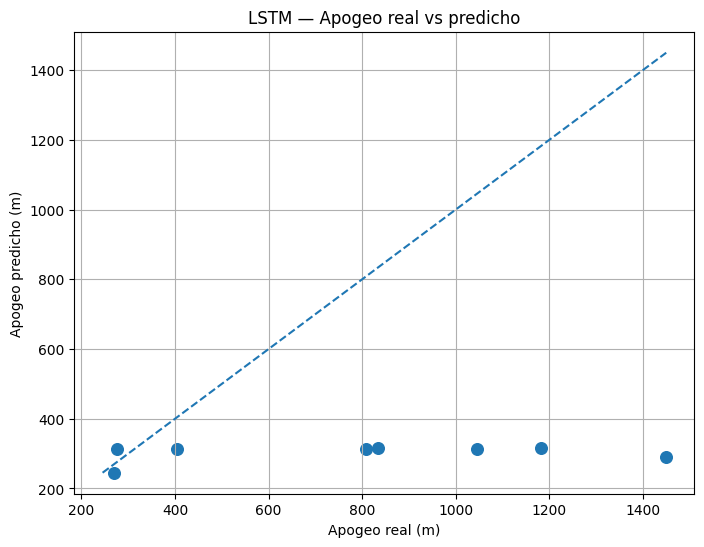

In [130]:
import matplotlib.pyplot as plt
import numpy as np

# PREDICCIONES LSTM VS APOGEO REAL

y_val_pred = model.predict(
    X_lstm_val_scaled,
    verbose=0
).flatten()

plt.figure(figsize=(8, 6))

plt.scatter(
    y_val,
    y_val_pred,
    s=70
)

# Línea ideal: predicción = valor real
min_val = min(y_val.min(), y_val_pred.min())
max_val = max(y_val.max(), y_val_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel("Apogeo real (m)")
plt.ylabel("Apogeo predicho (m)")
plt.title("LSTM — Apogeo real vs predicho")

plt.grid(True)
plt.show()

In [132]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# EVALUACIÓN DEL LSTM SOBRE VALIDACIÓN

# Predicciones
y_val_pred = model.predict(
    X_lstm_val_scaled,
    verbose=0
).flatten()

# Métricas
mae_lstm = mean_absolute_error(y_val, y_val_pred)

rmse_lstm = np.sqrt(
    mean_squared_error(y_val, y_val_pred)
)

r2_lstm = r2_score(
    y_val,
    y_val_pred
)

print("LSTM — RESULTADOS SOBRE VALIDACIÓN")

print(f"MAE  : {mae_lstm:.2f} m")
print(f"RMSE : {rmse_lstm:.2f} m")
print(f"R²   : {r2_lstm:.4f}")

LSTM — RESULTADOS SOBRE VALIDACIÓN
MAE  : 490.50 m
RMSE : 627.73 m
R²   : -1.3530


In [ ]:
#COMO PODEMOS VER,LAS METRICAS OBTENIDAS CON LA PRIMERA ITERACION DE LSTM SON UN POCO MALAS
#AHORA ESTAREMOS HACIENDO UN DIAGNOSTICO DE LOS RESULTADOS OBTENIDOS PARA VER SI PODEMOS MEJORAR 
# EL MODELO,

In [134]:
from sklearn.preprocessing import StandardScaler

# ESCALAMIENTO DEL OBJETIVO PARA LSTM

scaler_y_lstm = StandardScaler()

# Ajustar SOLO con entrenamiento
y_train_scaled = scaler_y_lstm.fit_transform(
    y_train.values.reshape(-1, 1)
).flatten()

# Transformar validación y prueba
y_val_scaled = scaler_y_lstm.transform(
    y_val.values.reshape(-1, 1)
).flatten()

y_test_scaled = scaler_y_lstm.transform(
    y_test.values.reshape(-1, 1)
).flatten()

print("ESCALAMIENTO DEL OBJETIVO")

print("y_train_scaled:", y_train_scaled.shape)
print("y_val_scaled  :", y_val_scaled.shape)
print("y_test_scaled :", y_test_scaled.shape)

print("\nMedia y_train_scaled:")
print(np.mean(y_train_scaled))

print("\nDesviación estándar y_train_scaled:")
print(np.std(y_train_scaled))

print("\nRango original de y_train:")
print(
    y_train.min(),
    "→",
    y_train.max()
)

print("\nRango escalado de y_train:")
print(
    y_train_scaled.min(),
    "→",
    y_train_scaled.max()
)

ESCALAMIENTO DEL OBJETIVO
y_train_scaled: (24,)
y_val_scaled  : (8,)
y_test_scaled : (9,)

Media y_train_scaled:
-9.25185853854297e-18

Desviación estándar y_train_scaled:
0.9999999999999998

Rango original de y_train:
108.39273216893098 → 1500.0953593681722

Rango escalado de y_train:
-0.9958657011282536 → 2.5922898029165764


In [ ]:
#AHORA SE PREGUNTARAN,PARA QUE VOLVIMOS A ESCALAR EL DATASET?
#Y LA RESPUESTA ES QUE, AUNQUE YA TENIAMOS ESCALADO EL DATASET DE ENTRADA,
#COMO PUDIMOS OBSERVAR EN LA GRAFICA ANTERIOR,EL MODELO ESTABA TENIENDO UN SOBREAJUSTE CON RESPECTO
#A LAS ALTURAS PREDECIDAS,ASI CON ESTE ESCALAMIENTO  EL OBJETIVO ES REDUCIR EL OVERFITTING
#Y MEJORAR LA GENERALIZACION DEL MODELO,

In [141]:
from sklearn.preprocessing import StandardScaler
# SCALER DEL OBJETIVO 

scaler_y = StandardScaler()

# Convertir Series de pandas a NumPy
y_train_array = y_train.to_numpy()
y_val_array   = y_val.to_numpy()
y_test_array  = y_test.to_numpy()

# Ajustar SOLO con entrenamiento
scaler_y.fit(y_train_array.reshape(-1, 1))

# Escalar
y_train_scaled = scaler_y.transform(
    y_train_array.reshape(-1, 1)
).ravel()

y_val_scaled = scaler_y.transform(
    y_val_array.reshape(-1, 1)
).ravel()

y_test_scaled = scaler_y.transform(
    y_test_array.reshape(-1, 1)
).ravel()

print("=" * 60)
print("SCALER DEL OBJETIVO")
print("=" * 60)

print("Media:", scaler_y.mean_[0])
print("Desviación estándar:", scaler_y.scale_[0])

print()
print("y_train_scaled:", y_train_scaled.shape)
print("y_val_scaled  :", y_val_scaled.shape)
print("y_test_scaled :", y_test_scaled.shape)

print()
print("Rango escalado de y_train:")
print(
    y_train_scaled.min(),
    "→",
    y_train_scaled.max()
)

SCALER DEL OBJETIVO
Media: 494.6493788040789
Desviación estándar: 387.860176525352

y_train_scaled: (24,)
y_val_scaled  : (8,)
y_test_scaled : (9,)

Rango escalado de y_train:
-0.9958657011282536 → 2.5922898029165764


In [142]:
#AHORA VAMOS CON UNA SEGUNDA ITERACIÓN DEL MODELO LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense

# ============================================================
# LSTM V2 — OBJETIVO ESCALADO
# ============================================================

model_scaled_y = Sequential([
    
    Input(shape=(X_lstm_train_scaled.shape[1],
                 X_lstm_train_scaled.shape[2])),
    
    LSTM(32),
    
    Dropout(0.2),
    
    Dense(16, activation="relu"),
    
    Dense(1)
])

model_scaled_y.compile(
    optimizer="adam",
    loss="mse"
)

model_scaled_y.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 32)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,537 (21.63 KB)

 Trainable params: 5,537 (21.63 KB)

 Non-trainable params: 0 (0.00 B)

In [143]:
from tensorflow.keras.callbacks import EarlyStopping

# ENTRENAMIENTO LSTM V2
# Objetivo: y escalado


early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history_scaled_y = model_scaled_y.fit(
    X_lstm_train_scaled,
    y_train_scaled,
    
    validation_data=(
        X_lstm_val_scaled,
        y_val_scaled
    ),
    
    epochs=300,
    batch_size=4,
    
    callbacks=[early_stopping],
    
    verbose=1
)

print("ENTRENAMIENTO LSTM V2 FINALIZADO")
print("Épocas ejecutadas:", len(history_scaled_y.history["loss"]))
print("Mejor loss entrenamiento:",
      min(history_scaled_y.history["loss"]))
print("Mejor loss validación:",
      min(history_scaled_y.history["val_loss"]))

Epoch 1/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.8414 - val_loss: 1.3093
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.8464 - val_loss: 1.3754
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.5941 - val_loss: 1.3890
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.6037 - val_loss: 1.4300
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.4129 - val_loss: 1.4894
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.4847 - val_loss: 1.6219
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.3760 - val_loss: 1.6099
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.3283 - val_loss: 1.5453
Epoch 9/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.4000 - val_loss: 1.5420
Epoch 10/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.2446 - val_loss: 1.5629
Epoch 11/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.1847 - val_loss: 1.6091
Epoch 12/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1313 - val_lo

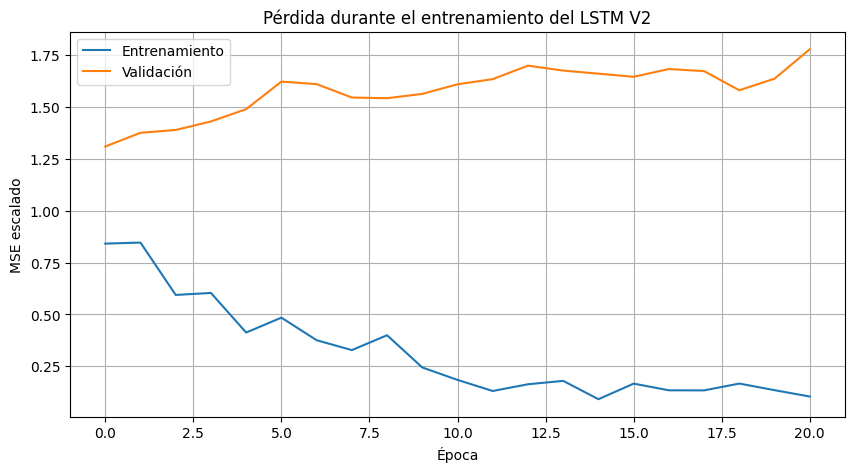

In [144]:
import matplotlib.pyplot as plt

# CURVA DE PÉRDIDA — LSTM V2

plt.figure(figsize=(10, 5))

plt.plot(
    history_scaled_y.history["loss"],
    label="Entrenamiento"
)

plt.plot(
    history_scaled_y.history["val_loss"],
    label="Validación"
)

plt.xlabel("Época")
plt.ylabel("MSE escalado")
plt.title("Pérdida durante el entrenamiento del LSTM V2")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#COMO PODRAN OBSERVAR ,LOS RESULTADOS PARA ESTA ITERACION FUERON CONSIDERABLEMENTE MEJORES 

In [145]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# PREDICCIÓN LSTM V2 — VALIDACIÓN
# Predicción en escala normalizada
y_val_pred_scaled = model_scaled_y.predict(
    X_lstm_val_scaled,
    verbose=0
)

# Convertir de (8, 1) a (8,)
y_val_pred_scaled = y_val_pred_scaled.ravel()

# Regresar predicciones a metros
y_val_pred = scaler_y.inverse_transform(
    y_val_pred_scaled.reshape(-1, 1)
).ravel()
# MÉTRICAS
mae_lstm_v2 = mean_absolute_error(
    y_val,
    y_val_pred
)

rmse_lstm_v2 = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred
    )
)

r2_lstm_v2 = r2_score(
    y_val,
    y_val_pred
)

print("LSTM V2 — RESULTADOS SOBRE VALIDACIÓN")


print(f"MAE  : {mae_lstm_v2:.2f} m")
print(f"RMSE : {rmse_lstm_v2:.2f} m")
print(f"R²   : {r2_lstm_v2:.4f}")

LSTM V2 — RESULTADOS SOBRE VALIDACIÓN
MAE  : 379.68 m
RMSE : 443.81 m
R²   : -0.1762


In [146]:
import pandas as pd
import numpy as np

# LSTM V2 — PREDICCIONES INDIVIDUALES EN VALIDACIÓN

# Predicciones escaladas
y_val_pred_scaled = model_scaled_y.predict(
    X_lstm_val_scaled,
    verbose=0
).ravel()

# Regresar a metros
y_val_pred = scaler_y.inverse_transform(
    y_val_pred_scaled.reshape(-1, 1)
).ravel()

# Crear tabla
resultados_lstm_v2 = pd.DataFrame({
    "Apogeo_real_m": y_val.to_numpy(),
    "Apogeo_predicho_m": y_val_pred
})

resultados_lstm_v2["Error_absoluto_m"] = (
    np.abs(
        resultados_lstm_v2["Apogeo_real_m"] -
        resultados_lstm_v2["Apogeo_predicho_m"]
    )
)

resultados_lstm_v2["Error_porcentual"] = (
    resultados_lstm_v2["Error_absoluto_m"] /
    resultados_lstm_v2["Apogeo_real_m"]
) * 100

resultados_lstm_v2.round(2)

,Apogeo_real_m,Apogeo_predicho_m,Error_absoluto_m,Error_porcentual
0,276.15,505.049988,228.90,82.89
1,403.91,429.869995,25.96,6.43
2,269.51,510.910004,241.40,89.57
3,1450.03,693.900024,756.12,52.15
4,1181.34,549.369995,631.97,53.50
5,807.81,579.179993,228.64,28.30
6,1044.80,499.720001,545.08,52.17
7,834.79,455.440002,379.35,45.44


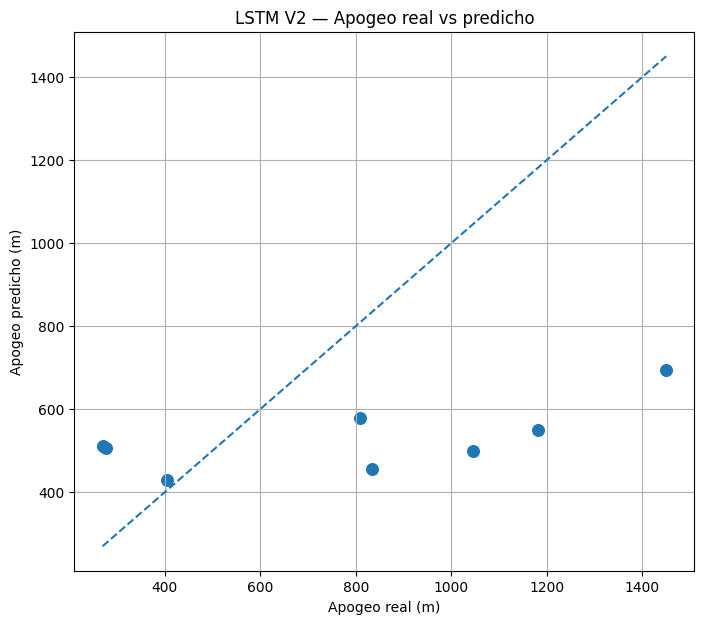

In [148]:
import matplotlib.pyplot as plt
import numpy as np
# LSTM V2 — REAL VS PREDICHO


plt.figure(figsize=(8, 7))

plt.scatter(
    y_val,
    y_val_pred,
    s=70
)

# Línea ideal y = x
min_val = min(y_val.min(), y_val_pred.min())
max_val = max(y_val.max(), y_val_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Apogeo real (m)")
plt.ylabel("Apogeo predicho (m)")
plt.title("LSTM V2 — Apogeo real vs predicho")

plt.grid(True)
plt.show()

In [ ]:
#PODEMOS VER QUE EL MODELO LSTM V2 TIENE UN MEJOR DESEMPEÑO QUE EL MODELO LSTM ORIGINAL,
#SIN EMBARGO SIGUE ESTANDO LEJOS DE SER EL IDEAL,ASI QUE HARENOS UNA NUEVA ITERACION  DEL MODELO
#EN DONDE REDUCIEREMOS SU TAMAÑO A UNA CAPA DE 16 Y CAMBIAREMOS EL MSE POR EL HUBER LOSS
#,QUE ES UNA FUNCION DE PERDIDA QUE COMBINA EL MSE Y EL MAE,

In [149]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
# LSTM V3 
model_v3 = Sequential([
    
    Input(shape=(
        X_lstm_train_scaled.shape[1],
        X_lstm_train_scaled.shape[2]
    )),
    
    LSTM(16),
    
    Dropout(0.30),
    
    Dense(8, activation="relu"),
    
    Dense(1)
])

model_v3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=Huber()
)

model_v3.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 16)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,617 (6.32 KB)

 Trainable params: 1,617 (6.32 KB)

 Non-trainable params: 0 (0.00 B)

In [151]:

# ENTRENAMIENTO LSTM V3

from tensorflow.keras.callbacks import EarlyStopping

early_stopping_v3 = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history_v3 = model_v3.fit(
    X_lstm_train_scaled,
    y_train_scaled,
    validation_data=(
        X_lstm_val_scaled,
        y_val_scaled
    ),
    epochs=300,
    batch_size=4,
    callbacks=[early_stopping_v3],
    verbose=1
)

print("ENTRENAMIENTO LSTM V3")


print("Épocas ejecutadas:", len(history_v3.history["loss"]))

print(
    "Mejor loss entrenamiento:",
    min(history_v3.history["loss"])
)

print(
    "Mejor loss validación:",
    min(history_v3.history["val_loss"])
)

Epoch 1/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.4665 - val_loss: 0.6253
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.4131 - val_loss: 0.6253
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.4064 - val_loss: 0.6299
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.3529 - val_loss: 0.6338
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.3912 - val_loss: 0.6398
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.3834 - val_loss: 0.6409
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.3486 - val_loss: 0.6412
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.3370 - val_loss: 0.6451
Epoch 9/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.3774 - val_loss: 0.6456
Epoch 10/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.2923 - val_loss: 0.6479
Epoch 11/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.2934 - val_loss: 0.6481
Epoch 12/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.2789 - val_lo

In [152]:
# LSTM V3 — PREDICCIÓN SOBRE VALIDACIÓN

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predicción en escala normalizada
y_val_pred_scaled_v3 = model_v3.predict(
    X_lstm_val_scaled,
    verbose=0
)

# Convertir de (8, 1) a (8,)
y_val_pred_scaled_v3 = y_val_pred_scaled_v3.ravel()

# Regresar predicciones a metros
y_val_pred_v3 = scaler_y.inverse_transform(
    y_val_pred_scaled_v3.reshape(-1, 1)
).ravel()

# Métricas en metros
mae_v3 = mean_absolute_error(
    y_val,
    y_val_pred_v3
)

rmse_v3 = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred_v3
    )
)

r2_v3 = r2_score(
    y_val,
    y_val_pred_v3
)

print("LSTM V3 — RESULTADOS SOBRE VALIDACIÓN")

print(f"MAE  : {mae_v3:.2f} m")
print(f"RMSE : {rmse_v3:.2f} m")
print(f"R²   : {r2_v3:.4f}")

LSTM V3 — RESULTADOS SOBRE VALIDACIÓN
MAE  : 408.36 m
RMSE : 495.97 m
R²   : -0.4689


#Nueva Version 


In [154]:

# LSTM — V4

print("DIAGNÓSTICO TEMPORAL DE LOS VUELOS")
# Frecuencia de muestreo
FS = 20          # Hz
DT = 1 / FS      # segundos

print(f"\nFrecuencia de muestreo: {FS} Hz")
print(f"Periodo de muestreo: {DT:.3f} s")

# Número de muestras por vuelo
samples_per_flight = (
    df_model
    .groupby("flight_id")
    .size()
    .sort_values()
)

print("\nMUESTRAS POR VUELO:")
print(samples_per_flight)

# Duración aproximada de cada vuelo

duration_per_flight = samples_per_flight / FS

print("\nDURACIÓN APROXIMADA POR VUELO:")
print(duration_per_flight)

# Estadísticas generales

print("\nESTADÍSTICAS:")
print(f"Número de vuelos : {len(samples_per_flight)}")
print(f"Mínimo muestras  : {samples_per_flight.min()}")
print(f"Máximo muestras  : {samples_per_flight.max()}")
print(f"Media muestras   : {samples_per_flight.mean():.2f}")
print(f"Mediana muestras : {samples_per_flight.median():.2f}")

print(f"\nMínima duración  : {duration_per_flight.min():.2f} s")
print(f"Máxima duración  : {duration_per_flight.max():.2f} s")
print(f"Duración media   : {duration_per_flight.mean():.2f} s")
print(f"Duración mediana : {duration_per_flight.median():.2f} s")

DIAGNÓSTICO TEMPORAL DE LOS VUELOS

Frecuencia de muestreo: 20 Hz
Periodo de muestreo: 0.050 s

MUESTRAS POR VUELO:
flight_id
11_standardized                        327
1_standardized                        1003
19_standardized                       1003
18_standardized                       1003
21_standardized                       1003
2_standardized                        1003
26_standardized                       1003
25_standardized                       1003
7_standardized                        1003
8_standardized                        1003
flightsketch8_standardized            1003
e1_replicated_failure_standardized    1003
6_standardized                        1003
4_standardized                        1003
5_standardized                        1012
12_standardized                       1028
15_standardized                       1066
13_standardized                       1196
3_standardized                        1206
22_standardized                       1224
10_standardize

In [155]:

# DEFINICIÓN DEL HORIZONTE TEMPORAL

FS = 20                    # Hz
PREDICTION_TIME = 6        # segundos

SEQUENCE_LENGTH = int(FS * PREDICTION_TIME)

features_lstm = [
    "baro_altitude",
    "accl_x",
    "accl_y",
    "accl_z",
    "At",
    "P"
]

target = "apogee"

print("CONFIGURACIÓN DEL LSTM")

print(f"\nFrecuencia de muestreo : {FS} Hz")
print(f"Tiempo de observación : {PREDICTION_TIME} s")
print(f"Número de muestras    : {SEQUENCE_LENGTH}")

print("\nVariables de entrada:")
for i, feature in enumerate(features_lstm, 1):
    print(f"{i}. {feature}")

print(f"\nVariable objetivo:")
print(f"1. {target}")

print("\nDimensiones esperadas por vuelo:")
print(f"({SEQUENCE_LENGTH}, {len(features_lstm)})")

CONFIGURACIÓN DEL LSTM

Frecuencia de muestreo : 20 Hz
Tiempo de observación : 6 s
Número de muestras    : 120

Variables de entrada:
1. baro_altitude
2. accl_x
3. accl_y
4. accl_z
5. At
6. P

Variable objetivo:
1. apogee

Dimensiones esperadas por vuelo:
(120, 6)


In [157]:
import numpy as np
import pandas as pd

# MODIFICACION DEL DATASET TEMPORAL PARA PREDICCIÓN EN VUELO

WINDOW_SIZE = 120      # 6 segundos a 20 Hz
STEP_SIZE = 20         # nueva ventana cada 1 segundo

features_lstm = [
    "baro_altitude",
    "accl_x",
    "accl_y",
    "accl_z",
    "At",
    "P"
]

target = "apogee"

X_temporal = []
y_temporal = []

flight_ids_temporal = []
prediction_times = []

# ------------------------------------------------------------
# Procesar cada vuelo por separado
# ------------------------------------------------------------

for flight_id, flight in df_model.groupby("flight_id"):

    # Orden temporal
    flight = flight.sort_values("time").reset_index(drop=True)

    # Verificar número de muestras
    n_samples = len(flight)

    # Necesitamos al menos una ventana completa
    if n_samples < WINDOW_SIZE:
        continue

    # Apogeo final del vuelo
    apogee_value = flight[target].iloc[0]

    # Crear ventanas
    for start in range(0, n_samples - WINDOW_SIZE + 1, STEP_SIZE):

        end = start + WINDOW_SIZE

        window = flight.iloc[start:end]

        # Verificar tamaño
        if len(window) != WINDOW_SIZE:
            continue

        # Variables de entrada
        X_window = window[features_lstm].values

        # Guardar
        X_temporal.append(X_window)
        y_temporal.append(apogee_value)

        flight_ids_temporal.append(flight_id)

        # Tiempo correspondiente al final de la ventana
        prediction_times.append(window["time"].iloc[-1])


# ------------------------------------------------------------
# Convertir a NumPy
# ------------------------------------------------------------

X_temporal = np.array(X_temporal, dtype=np.float32)
y_temporal = np.array(y_temporal, dtype=np.float32)

flight_ids_temporal = np.array(flight_ids_temporal)
prediction_times = np.array(prediction_times)


# ============================================================
# INFORMACIÓN DEL DATASET
# ============================================================
print("NUEVODATASET TEMPORAL PARA PREDICCIÓN DURANTE EL VUELO")

print(f"\nNúmero total de ventanas : {len(X_temporal)}")
print(f"Shape X                  : {X_temporal.shape}")
print(f"Shape y                  : {y_temporal.shape}")

print("\nDimensiones esperadas por ventana:")
print(f"({WINDOW_SIZE}, {len(features_lstm)})")

print("\nVariables:")
for i, feature in enumerate(features_lstm, 1):
    print(f"{i}. {feature}")

print("\nNúmero de vuelos utilizados:")
print(len(np.unique(flight_ids_temporal)))

print("\nVentanas generadas por vuelo:")
print(
    pd.Series(flight_ids_temporal)
    .value_counts()
    .sort_index()
)

NUEVODATASET TEMPORAL PARA PREDICCIÓN DURANTE EL VUELO

Número total de ventanas : 3591
Shape X                  : (3591, 120, 6)
Shape y                  : (3591,)

Dimensiones esperadas por ventana:
(120, 6)

Variables:
1. baro_altitude
2. accl_x
3. accl_y
4. accl_z
5. At
6. P

Número de vuelos utilizados:
48

Ventanas generadas por vuelo:
10_standardized                        59
11_standardized                        11
12_standardized                        46
13_standardized                        54
14_standardized                        69
15_standardized                        48
16_standardized                        62
17_standardized                        64
18_standardized                        45
19_standardized                        45
1_standardized                         45
20_standardized                        89
21_standardized                        45
22_standardized                        56
23_standardized                        94
24_standardized           

In [163]:

# VARIABLES RELACIONADAS CON EL DATASET TEMPORAL
print("Variables disponibles:")

for nombre in [
    "X", "y",
    "X_lstm", "y_lstm",
    "df_window",
    "df_model",
    "df_6s"
]:
    if nombre in globals():
        objeto = globals()[nombre]
        print(f"{nombre:12} -> {type(objeto).__name__} | shape: {getattr(objeto, 'shape', 'N/A')}")
        print("\nVariables que contienen 'flight':")

for nombre in globals():
    if "flight" in nombre.lower():
        print(nombre)

Variables disponibles:
X            -> DataFrame | shape: (41, 17)

Variables que contienen 'flight':
y            -> Series | shape: (41,)

Variables que contienen 'flight':
df_window    -> DataFrame | shape: (121, 16)

Variables que contienen 'flight':
df_model     -> DataFrame | shape: (77035, 16)

Variables que contienen 'flight':
df_6s        -> DataFrame | shape: (41, 23)

Variables que contienen 'flight':
flight_files
flight_info
df_flight_info
excluded_flights
processed_flights
flight_id
flight_stats
df_flight_stats
df_flight_stats_sorted
apogee_by_flight
flight_summary
flight_dfs
flight
df_flight
flights_to_remove
flight_summary_ml
short_flights
flight_df
samples_per_flight
valid_flights
flight_ids_sequences
flight_data
flight_ids_lstm
duration_per_flight
flight_ids_temporal


In [162]:
# VERIFICACIÓN DE IDENTIFICADORES TEMPORALES
print("Tipo:", type(flight_ids_temporal))
print("Shape:", np.shape(flight_ids_temporal))
print("Número de IDs:", len(flight_ids_temporal))

print("\nPrimeros 20 IDs:")
print(flight_ids_temporal[:20])

print("\nNúmero de vuelos únicos:")
print(len(np.unique(flight_ids_temporal)))

print("\nVuelos únicos:")
print(np.unique(flight_ids_temporal))

Tipo: <class 'numpy.ndarray'>
Shape: (3591,)
Número de IDs: 3591

Primeros 20 IDs:
['10_standardized' '10_standardized' '10_standardized' '10_standardized'
 '10_standardized' '10_standardized' '10_standardized' '10_standardized'
 '10_standardized' '10_standardized' '10_standardized' '10_standardized'
 '10_standardized' '10_standardized' '10_standardized' '10_standardized'
 '10_standardized' '10_standardized' '10_standardized' '10_standardized']

Número de vuelos únicos:
48

Vuelos únicos:
['10_standardized' '11_standardized' '12_standardized' '13_standardized'
 '14_standardized' '15_standardized' '16_standardized' '17_standardized'
 '18_standardized' '19_standardized' '1_standardized' '20_standardized'
 '21_standardized' '22_standardized' '23_standardized' '24_standardized'
 '25_standardized' '26_standardized' '27_standardized' '28_standardized'
 '29_standardized' '2_standardized' '30_standardized' '31_standardized'
 '32_standardized' '33_standardized' '34_standardized' '35_standardize

In [166]:
from sklearn.model_selection import train_test_split
import numpy as np

# DIVISIÓN TEMPORAL POR VUELO
# 60% ENTRENAMIENTO / 20% VALIDACIÓN / 20% PRUEBA

# Vuelos únicos
unique_flights = np.unique(flight_ids_temporal)

print("Número total de vuelos:", len(unique_flights))

# 60% entrenamiento / 40% temporal

flights_train, flights_temp = train_test_split(
    unique_flights,
    test_size=0.40,
    random_state=42
)

# Dividir el 40% restante en:
# 20% validación / 20% prueba

flights_val, flights_test = train_test_split(
    flights_temp,
    test_size=0.50,
    random_state=42
)

# RESULTADOS


print("DIVISIÓN POR VUELO")

print("\nVuelos de entrenamiento:", len(flights_train))
print("Vuelos de validación   :", len(flights_val))
print("Vuelos de prueba       :", len(flights_test))

print("\nTotal:")
print(len(flights_train) + len(flights_val) + len(flights_test))

Número total de vuelos: 48
DIVISIÓN POR VUELO

Vuelos de entrenamiento: 28
Vuelos de validación   : 10
Vuelos de prueba       : 10

Total:
48


In [167]:
# BUSCAR DATASET TEMPORAL

nombres = list(globals().keys())

encontrados = []

for nombre in nombres:
    try:
        obj = globals()[nombre]

        if hasattr(obj, "shape"):
            if obj.shape == (3591, 120, 6):
                encontrados.append(nombre)

    except:
        pass

print("Arrays encontrados con shape (3591, 120, 6):")

for nombre in encontrados:
    print(f" - {nombre}")

Arrays encontrados con shape (3591, 120, 6):
 - X_temporal


In [168]:
# CREAR DATASETS LSTM
# DIVISIÓN POR VUELO
# Máscaras según el vuelo
train_mask = np.isin(flight_ids_temporal, flights_train)
val_mask   = np.isin(flight_ids_temporal, flights_val)
test_mask  = np.isin(flight_ids_temporal, flights_test)

# Crear X
X_train_temporal = X_temporal[train_mask]
X_val_temporal   = X_temporal[val_mask]
X_test_temporal  = X_temporal[test_mask]

# Crear y
y_train_temporal = y_temporal[train_mask]
y_val_temporal   = y_temporal[val_mask]
y_test_temporal  = y_temporal[test_mask]
# RESULTADOS

print("DATASET LSTM ")

print("\nENTRENAMIENTO:")
print("X_train:", X_train_temporal.shape)
print("y_train:", y_train_temporal.shape)

print("\nVALIDACIÓN:")
print("X_val:", X_val_temporal.shape)
print("y_val:", y_val_temporal.shape)

print("\nPRUEBA:")
print("X_test:", X_test_temporal.shape)
print("y_test:", y_test_temporal.shape)

DATASET LSTM 

ENTRENAMIENTO:
X_train: (2124, 120, 6)
y_train: (2124,)

VALIDACIÓN:
X_val: (623, 120, 6)
y_val: (623,)

PRUEBA:
X_test: (844, 120, 6)
y_test: (844,)


In [169]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# ESCALAMIENTO DE VARIABLES DE ENTRADA (X)

n_train, n_timesteps, n_features = X_train_temporal.shape

# Crear scaler
scaler_X_temporal = StandardScaler()

# Para escalar un dataset 3D necesitamos convertirlo
# temporalmente a 2D

X_train_2d = X_train_temporal.reshape(-1, n_features)

X_val_2d = X_val_temporal.reshape(-1, n_features)

X_test_2d = X_test_temporal.reshape(-1, n_features)

# AJUSTAR SOLO CON ENTRENAMIENTO

scaler_X_temporal.fit(X_train_2d)

# Transformar

X_train_temporal_scaled = scaler_X_temporal.transform(
    X_train_2d
)

X_val_temporal_scaled = scaler_X_temporal.transform(
    X_val_2d
)

X_test_temporal_scaled = scaler_X_temporal.transform(
    X_test_2d
)
# Regresar a formato 3D

X_train_temporal_scaled = X_train_temporal_scaled.reshape(
    X_train_temporal.shape
)

X_val_temporal_scaled = X_val_temporal_scaled.reshape(
    X_val_temporal.shape
)

X_test_temporal_scaled = X_test_temporal_scaled.reshape(
    X_test_temporal.shape
)
# VERIFICACIÓN

print("ESCALAMIENTO DEL DATASET TEMPORAL")
print("\nX_train_scaled:", X_train_temporal_scaled.shape)
print("X_val_scaled  :", X_val_temporal_scaled.shape)
print("X_test_scaled :", X_test_temporal_scaled.shape)

# Media y desviación estándar del entrenamiento
train_flat = X_train_temporal_scaled.reshape(-1, n_features)

print("\nMedia de X_train_scaled:")
print(train_flat.mean(axis=0))

print("\nDesviación estándar de X_train_scaled:")
print(train_flat.std(axis=0))

ESCALAMIENTO DEL DATASET TEMPORAL

X_train_scaled: (2124, 120, 6)
X_val_scaled  : (623, 120, 6)
X_test_scaled : (844, 120, 6)

Media de X_train_scaled:
[ 1.2064910e-05  8.4066684e-08  1.5309982e-06 -2.0447892e-07
 -8.5133257e-07  2.6643735e-05]

Desviación estándar de X_train_scaled:
[1.0000192 0.999975  0.9999513 0.9999251 0.9999598 1.0000252]


In [173]:
from sklearn.preprocessing import StandardScaler

# ESCALAMIENTO DEL OBJETIVO PARA LSTM TEMPORAL (Y)


scaler_y_temporal = StandardScaler()

# Convertir a 2D
y_train_temporal_2d = y_train_temporal.reshape(-1, 1)
y_val_temporal_2d   = y_val_temporal.reshape(-1, 1)
y_test_temporal_2d  = y_test_temporal.reshape(-1, 1)

# Ajustar SOLO con entrenamiento
scaler_y_temporal.fit(y_train_temporal_2d)

# Transformar
y_train_temporal_scaled = scaler_y_temporal.transform(
    y_train_temporal_2d
).ravel()

y_val_temporal_scaled = scaler_y_temporal.transform(
    y_val_temporal_2d
).ravel()

y_test_temporal_scaled = scaler_y_temporal.transform(
    y_test_temporal_2d
).ravel()

# ============================================================
# VERIFICACIÓN
# ============================================================

print("="*60)
print("ESCALAMIENTO DEL OBJETIVO — LSTM TEMPORAL")
print("="*60)

print("\ny_train_temporal_scaled:", 
      y_train_temporal_scaled.shape)

print("y_val_temporal_scaled  :", 
      y_val_temporal_scaled.shape)

print("y_test_temporal_scaled :", 
      y_test_temporal_scaled.shape)

print("\nMedia entrenamiento:")
print(y_train_temporal_scaled.mean())

print("\nDesviación estándar entrenamiento:")
print(y_train_temporal_scaled.std())

print("\nRango original:")
print(
    y_train_temporal.min(),
    "→",
    y_train_temporal.max()
)

print("\nRango escalado:")
print(
    y_train_temporal_scaled.min(),
    "→",
    y_train_temporal_scaled.max()
)

ESCALAMIENTO DEL OBJETIVO — LSTM TEMPORAL

y_train_temporal_scaled: (2124,)
y_val_temporal_scaled  : (623,)
y_test_temporal_scaled : (844,)

Media entrenamiento:
0.0

Desviación estándar entrenamiento:
0.99999994

Rango original:
108.39273 → 1975.3291

Rango escalado:
-1.289287 → 2.0493042


In [174]:
#AHORA PROCEDEREMOS A HACER LA SIGUIENTE ITERACIÓN DE LSTM 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense
# LSTM V3 
model_temporal_v1 = Sequential([
    
    Input(shape=(
        X_train_temporal_scaled.shape[1],
        X_train_temporal_scaled.shape[2]
    )),
    
    LSTM(32),
    
    Dropout(0.2),
    
    Dense(16, activation="relu"),
    
    Dense(1)
])

# COMPILACIÓN

model_temporal_v1.compile(
    optimizer="adam",
    loss="mse"
)
# RESUMEN
model_temporal_v1.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 32)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,537 (21.63 KB)

 Trainable params: 5,537 (21.63 KB)

 Non-trainable params: 0 (0.00 B)

In [175]:
from tensorflow.keras.callbacks import EarlyStopping

# ENTRENAMIENTO — LSTM V3

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history_temporal_v1 = model_temporal_v1.fit(
    X_train_temporal_scaled,
    y_train_temporal_scaled,
    
    validation_data=(
        X_val_temporal_scaled,
        y_val_temporal_scaled
    ),
    
    epochs=150,
    batch_size=32,
    
    callbacks=[early_stopping],
    
    verbose=1
)
# RESUMEN DEL ENTRENAMIENTO

print("ENTRENAMIENTO LSTM V3 ")

print(
    "\nÉpocas ejecutadas:",
    len(history_temporal_v1.history["loss"])
)

print(
    "Mejor loss entrenamiento:",
    min(history_temporal_v1.history["loss"])
)

print(
    "Mejor loss validación:",
    min(history_temporal_v1.history["val_loss"])
)

Epoch 1/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.6113 - val_loss: 0.3439
Epoch 2/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.4233 - val_loss: 0.4755
Epoch 3/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.3366 - val_loss: 0.3817
Epoch 4/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.2860 - val_loss: 0.2852
Epoch 5/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.2706 - val_loss: 0.3676
Epoch 6/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.3852 - val_loss: 0.4153
Epoch 7/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.3228 - val_loss: 0.3534
Epoch 8/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - loss: 0.2874 - val_loss: 0.2889
Epoch 9/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 0.2823 - val_loss: 0.2931
Epoch 10/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 0.3110 - val_loss: 0.3163
Epoch 11/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 0.2560 - val_loss: 0.2916
Epoch 12/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step

In [176]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# PREDICCIÓN SOBRE VALIDACIÓN

y_val_pred_scaled = model_temporal_v1.predict(
    X_val_temporal_scaled,
    verbose=0
).ravel()

# REGRESAR A METROS

y_val_pred = scaler_y_temporal.inverse_transform(
    y_val_pred_scaled.reshape(-1, 1)
).ravel()

# MÉTRICAS

mae_val = mean_absolute_error(
    y_val_temporal,
    y_val_pred
)

rmse_val = np.sqrt(
    mean_squared_error(
        y_val_temporal,
        y_val_pred
    )
)

r2_val = r2_score(
    y_val_temporal,
    y_val_pred
)
# RESULTADOS
print("="*60)
print("LSTM V3 — RESULTADOS SOBRE VALIDACIÓN")
print("="*60)

print(f"\nMAE  : {mae_val:.2f} m")
print(f"RMSE : {rmse_val:.2f} m")
print(f"R²   : {r2_val:.4f}")

LSTM V3 — RESULTADOS SOBRE VALIDACIÓN

MAE  : 227.16 m
RMSE : 298.66 m
R²   : 0.2568


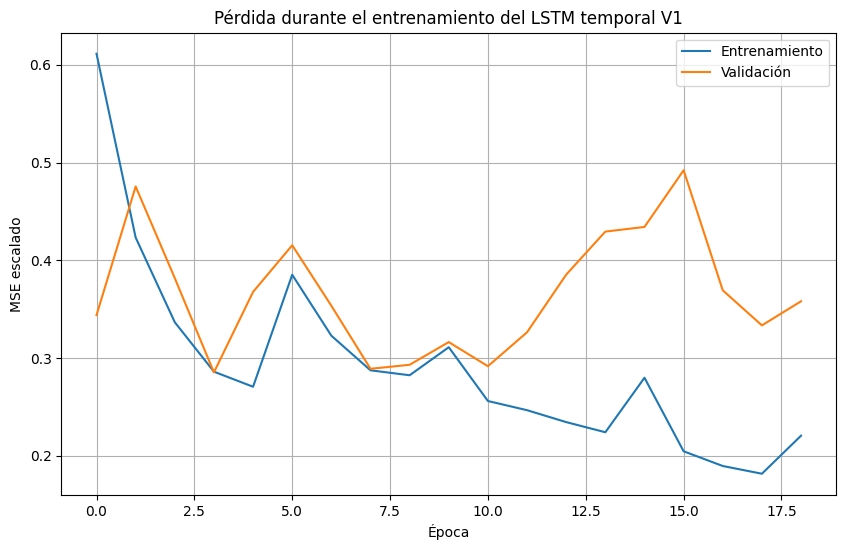

In [177]:
import matplotlib.pyplot as plt
# CURVA DE APRENDIZAJE 
plt.figure(figsize=(10, 6))

plt.plot(
    history_temporal_v1.history["loss"],
    label="Entrenamiento"
)

plt.plot(
    history_temporal_v1.history["val_loss"],
    label="Validación"
)

plt.xlabel("Época")
plt.ylabel("MSE escalado")
plt.title("Pérdida durante el entrenamiento del LSTM temporal V1")

plt.legend()
plt.grid(True)

plt.show()

In [178]:
# EVALUACIÓN FINAL — LSTM V3

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Predicciones sobre TEST
y_test_pred_scaled = model.predict(
    X_test_temporal_scaled,
    verbose=0
).ravel()
# Regresar a metros
y_test_pred = scaler_y_temporal.inverse_transform(
    y_test_pred_scaled.reshape(-1, 1)
).ravel()

y_test_real = scaler_y_temporal.inverse_transform(
    y_test_temporal_scaled.reshape(-1, 1)
).ravel()

# Métricas
mae_test = mean_absolute_error(
    y_test_real,
    y_test_pred
)

rmse_test = np.sqrt(
    mean_squared_error(
        y_test_real,
        y_test_pred
    )
)

r2_test = r2_score(
    y_test_real,
    y_test_pred
)

print("LSTM TEMPORAL V3")

print(f"MAE  : {mae_test:.2f} m")
print(f"RMSE : {rmse_test:.2f} m")
print(f"R²   : {r2_test:.4f}")

LSTM TEMPORAL V3
MAE  : 58586.58 m
RMSE : 86993.61 m
R²   : -40309.4727


In [179]:

# DIAGNÓSTICO DE PREDICCIONES — LSTM V3

import numpy as np

print("=" * 60)
print("DIAGNÓSTICO DE PREDICCIONES")
print("=" * 60)
# 1. Predicciones escaladas

y_test_pred_scaled = model.predict(
    X_test_temporal_scaled,
    verbose=0
).ravel()

print("\nPREDICCIONES ESCALADAS")
print("Shape:", y_test_pred_scaled.shape)
print("Mínimo:", np.min(y_test_pred_scaled))
print("Máximo:", np.max(y_test_pred_scaled))
print("Media :", np.mean(y_test_pred_scaled))
print("Std   :", np.std(y_test_pred_scaled))
# 2. Objetivo real escalado
print("\nOBJETIVO TEST ESCALADO")
print("Shape:", y_test_temporal_scaled.shape)
print("Mínimo:", np.min(y_test_temporal_scaled))
print("Máximo:", np.max(y_test_temporal_scaled))
print("Media :", np.mean(y_test_temporal_scaled))
print("Std   :", np.std(y_test_temporal_scaled))
# 3. Inversión a metros

y_test_pred = scaler_y_temporal.inverse_transform(
    y_test_pred_scaled.reshape(-1, 1)
).ravel()

y_test_real = scaler_y_temporal.inverse_transform(
    y_test_temporal_scaled.reshape(-1, 1)
).ravel()

print("\nPREDICCIONES EN METROS")
print("Mínimo:", np.min(y_test_pred))
print("Máximo:", np.max(y_test_pred))
print("Media :", np.mean(y_test_pred))
print("Std   :", np.std(y_test_pred))

print("\nOBJETIVO REAL EN METROS")
print("Mínimo:", np.min(y_test_real))
print("Máximo:", np.max(y_test_real))
print("Media :", np.mean(y_test_real))
print("Std   :", np.std(y_test_real))

# 4. Primeras 20 predicciones

print("\nPRIMERAS 20 COMPARACIONES")
print("-" * 60)

for i in range(min(20, len(y_test_real))):
    print(
        f"{i:3d} | "
        f"Real: {y_test_real[i]:8.2f} m | "
        f"Pred: {y_test_pred[i]:8.2f} m"
    )

DIAGNÓSTICO DE PREDICCIONES

PREDICCIONES ESCALADAS
Shape: (844,)
Mínimo: 0.35080373
Máximo: 315.38165
Media : 104.43727
Std   : 115.40137

OBJETIVO TEST ESCALADO
Shape: (844,)
Mínimo: -1.0790428
Máximo: 1.1099205
Media : -0.27894038
Std   : 0.7748403

PREDICCIONES EN METROS
Mínimo: 1025.5295
Máximo: 177190.42
Media : 59230.56
Std   : 64532.31

OBJETIVO REAL EN METROS
Mínimo: 225.961
Máximo: 1450.0267
Media : 673.3774
Std   : 433.28976

PRIMERAS 20 COMPARACIONES
------------------------------------------------------------
  0 | Real:   263.16 m | Pred:  1046.28 m
  1 | Real:   263.16 m | Pred:  1051.09 m
  2 | Real:   263.16 m | Pred:  1087.07 m
  3 | Real:   263.16 m | Pred:  1082.43 m
  4 | Real:   263.16 m | Pred:  1079.28 m
  5 | Real:   263.16 m | Pred:  1078.33 m
  6 | Real:   263.16 m | Pred:  1078.90 m
  7 | Real:   263.16 m | Pred:  1081.23 m
  8 | Real:   263.16 m | Pred: 131881.33 m
  9 | Real:   263.16 m | Pred: 146448.97 m
 10 | Real:   263.16 m | Pred: 123111.58 m
 11 | R

In [180]:
# ============================================================
# COMPROBACIÓN DEL MODELO ACTUAL
# ============================================================

print("=" * 60)
print("MODELO ACTUAL")
print("=" * 60)

print("Objeto model:")
print(model)

print("\nResumen:")
model.summary()

MODELO ACTUAL
Objeto model:
<Sequential name=sequential_2, built=True>

Resumen:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 32)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,613 (64.90 KB)

 Trainable params: 5,537 (21.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,076 (43.27 KB)

In [181]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 32)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,613 (64.90 KB)

 Trainable params: 5,537 (21.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,076 (43.27 KB)

In [182]:
y_val_pred_scaled_check = model.predict(
    X_val_temporal_scaled,
    verbose=0
).ravel()

print("Mínimo:", np.min(y_val_pred_scaled_check))
print("Máximo:", np.max(y_val_pred_scaled_check))
print("Media :", np.mean(y_val_pred_scaled_check))
print("Std   :", np.std(y_val_pred_scaled_check))

Mínimo: 0.3849972
Máximo: 287.07034
Media : 98.059
Std   : 110.70833


In [184]:
# DIAGNÓSTICO DEL MODELO ACTUAL
print("DIAGNÓSTICO DEL MODELO LSTM ACTUAL")

print("\nMODELO:")
model.summary()

print("\n------------------------------------------------------------")
print("DIMENSIONES DE ENTRADA")
print("------------------------------------------------------------")

print("X_train_scaled:", X_train_temporal_scaled.shape)
print("X_val_scaled  :", X_val_temporal_scaled.shape)
print("X_test_scaled :", X_test_temporal_scaled.shape)

print("\n------------------------------------------------------------")
print("DIMENSIONES DEL OBJETIVO")
print("------------------------------------------------------------")

print("y_train_scaled:", y_train_temporal_scaled.shape)
print("y_val_scaled  :", y_val_temporal_scaled.shape)
print("y_test_scaled :", y_test_temporal_scaled.shape)

print("\n------------------------------------------------------------")
print("RANGO DEL OBJETIVO ESCALADO")
print("------------------------------------------------------------")

print("Train:")
print(" Min:", np.min(y_train_temporal_scaled))
print(" Max:", np.max(y_train_temporal_scaled))
print(" Mean:", np.mean(y_train_temporal_scaled))
print(" Std:", np.std(y_train_temporal_scaled))

print("\nValidation:")
print(" Min:", np.min(y_val_temporal_scaled))
print(" Max:", np.max(y_val_temporal_scaled))
print(" Mean:", np.mean(y_val_temporal_scaled))
print(" Std:", np.std(y_val_temporal_scaled))

print("\nTest:")
print(" Min:", np.min(y_test_temporal_scaled))
print(" Max:", np.max(y_test_temporal_scaled))
print(" Mean:", np.mean(y_test_temporal_scaled))
print(" Std:", np.std(y_test_temporal_scaled))

print("\n------------------------------------------------------------")
print("PREDICCIONES DEL MODELO")
print("------------------------------------------------------------")

pred_train = model.predict(
    X_train_temporal_scaled,
    verbose=0
).ravel()

pred_val = model.predict(
    X_val_temporal_scaled,
    verbose=0
).ravel()

pred_test = model.predict(
    X_test_temporal_scaled,
    verbose=0
).ravel()

print("\nTRAIN:")
print(" Min:", np.min(pred_train))
print(" Max:", np.max(pred_train))
print(" Mean:", np.mean(pred_train))
print(" Std:", np.std(pred_train))

print("\nVALIDACIÓN:")
print(" Min:", np.min(pred_val))
print(" Max:", np.max(pred_val))
print(" Mean:", np.mean(pred_val))
print(" Std:", np.std(pred_val))

print("\nTEST:")
print(" Min:", np.min(pred_test))
print(" Max:", np.max(pred_test))
print(" Mean:", np.mean(pred_test))
print(" Std:", np.std(pred_test))

print("\n------------------------------------------------------------")
print("PRIMERAS 20 PREDICCIONES VS OBJETIVO")
print("------------------------------------------------------------")

for i in range(min(20, len(pred_test))):
    print(
        f"{i:3d} | "
        f"Real: {y_test_temporal_scaled[i]:8.4f} | "
        f"Pred: {pred_test[i]:8.4f}"
    )

DIAGNÓSTICO DEL MODELO LSTM ACTUAL

MODELO:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 32)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,613 (64.90 KB)

 Trainable params: 5,537 (21.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,076 (43.27 KB)


------------------------------------------------------------
DIMENSIONES DE ENTRADA
------------------------------------------------------------
X_train_scaled: (2124, 120, 6)
X_val_scaled  : (623, 120, 6)
X_test_scaled : (844, 120, 6)

------------------------------------------------------------
DIMENSIONES DEL OBJETIVO
------------------------------------------------------------
y_train_scaled: (2124,)
y_val_scaled  : (623,)
y_test_scaled : (844,)

------------------------------------------------------------
RANGO DEL OBJETIVO ESCALADO
------------------------------------------------------------
Train:
 Min: -1.289287
 Max: 2.0493042
 Mean: 0.0
 Std: 0.99999994

Validation:
 Min: -1.1810718
 Max: 0.38525814
 Mean: -0.37655392
 Std: 0.61951977

Test:
 Min: -1.0790428
 Max: 1.1099205
 Mean: -0.27894038
 Std: 0.7748403

------------------------------------------------------------
PREDICCIONES DEL MODELO
------------------------------------------------------------

TRAIN:
 Min: 0.365766

In [188]:
# DIAGNÓSTICO DEL MODELO Y TIPOS DE DATOS

import numpy as np
import tensorflow as tf
print("DIAGNÓSTICO DEL MODELO")
print("\nMODELO:")
print(model)

print("\nNombre del modelo:")
print(model.name)

print("\nInput shape del modelo:")
print(model.input_shape)

print("\nOutput shape del modelo:")
print(model.output_shape)

print("\nParámetros:")
print(model.count_params())

print("\n------------------------------------------------------------")
print("TIPOS DE DATOS")
print("------------------------------------------------------------")

print("X_train_temporal_scaled:")
print(" Tipo:", type(X_train_temporal_scaled))
print(" Shape:", X_train_temporal_scaled.shape)
print(" Dtype:", X_train_temporal_scaled.dtype)

print("\nX_val_temporal_scaled:")
print(" Tipo:", type(X_val_temporal_scaled))
print(" Shape:", X_val_temporal_scaled.shape)
print(" Dtype:", X_val_temporal_scaled.dtype)

print("\nX_test_temporal_scaled:")
print(" Tipo:", type(X_test_temporal_scaled))
print(" Shape:", X_test_temporal_scaled.shape)
print(" Dtype:", X_test_temporal_scaled.dtype)

print("\ny_train_temporal_scaled:")
print(" Tipo:", type(y_train_temporal_scaled))
print(" Shape:", y_train_temporal_scaled.shape)
print(" Dtype:", y_train_temporal_scaled.dtype)

print("\n------------------------------------------------------------")
print("CONVERSIÓN A NUMPY FLOAT32")
print("------------------------------------------------------------")

X_train_check = np.asarray(
    X_train_temporal_scaled,
    dtype=np.float32
)

X_val_check = np.asarray(
    X_val_temporal_scaled,
    dtype=np.float32
)

X_test_check = np.asarray(
    X_test_temporal_scaled,
    dtype=np.float32
)

y_train_check = np.asarray(
    y_train_temporal_scaled,
    dtype=np.float32
)

y_val_check = np.asarray(
    y_val_temporal_scaled,
    dtype=np.float32
)

y_test_check = np.asarray(
    y_test_temporal_scaled,
    dtype=np.float32
)

print("X_train_check:", X_train_check.shape, X_train_check.dtype)
print("X_val_check:  ", X_val_check.shape, X_val_check.dtype)
print("X_test_check: ", X_test_check.shape, X_test_check.dtype)

print("y_train_check:", y_train_check.shape, y_train_check.dtype)
print("y_val_check:  ", y_val_check.shape, y_val_check.dtype)
print("y_test_check: ", y_test_check.shape, y_test_check.dtype)

print("\n------------------------------------------------------------")
print("COMPROBACIÓN DE NaN / INFINITOS")
print("------------------------------------------------------------")

print(
    "NaN X_train:",
    np.isnan(X_train_check).sum(),
    "| Inf:",
    np.isinf(X_train_check).sum()
)

print(
    "NaN y_train:",
    np.isnan(y_train_check).sum(),
    "| Inf:",
    np.isinf(y_train_check).sum()
)

print(
    "NaN X_val:",
    np.isnan(X_val_check).sum(),
    "| Inf:",
    np.isinf(X_val_check).sum()
)

print(
    "NaN y_val:",
    np.isnan(y_val_check).sum(),
    "| Inf:",
    np.isinf(y_val_check).sum()
)

print(
    "NaN X_test:",
    np.isnan(X_test_check).sum(),
    "| Inf:",
    np.isinf(X_test_check).sum()
)

print(
    "NaN y_test:",
    np.isnan(y_test_check).sum(),
    "| Inf:",
    np.isinf(y_test_check).sum()
)
print("\n------------------------------------------------------------")
print("PRUEBA DE PREDICCIÓN")
print("------------------------------------------------------------")

pred_check = model.predict(
    X_test_check,
    verbose=0
).ravel()

print("Shape predicciones:", pred_check.shape)

print("Min:", np.min(pred_check))
print("Max:", np.max(pred_check))
print("Mean:", np.mean(pred_check))
print("Std:", np.std(pred_check))

print("\nPrimeras 10:")
for i in range(10):
    print(
        f"{i:2d} | "
        f"Real: {y_test_check[i]:8.4f} | "
        f"Pred: {pred_check[i]:8.4f}"
    )

DIAGNÓSTICO DEL MODELO

MODELO:
<Sequential name=sequential_2, built=True>

Nombre del modelo:
sequential_2

Input shape del modelo:
(None, 121, 6)

Output shape del modelo:
(None, 1)

Parámetros:
5537

------------------------------------------------------------
TIPOS DE DATOS
------------------------------------------------------------
X_train_temporal_scaled:
 Tipo: <class 'numpy.ndarray'>
 Shape: (2124, 120, 6)
 Dtype: float32

X_val_temporal_scaled:
 Tipo: <class 'numpy.ndarray'>
 Shape: (623, 120, 6)
 Dtype: float32

X_test_temporal_scaled:
 Tipo: <class 'numpy.ndarray'>
 Shape: (844, 120, 6)
 Dtype: float32

y_train_temporal_scaled:
 Tipo: <class 'numpy.ndarray'>
 Shape: (2124,)
 Dtype: float32

------------------------------------------------------------
CONVERSIÓN A NUMPY FLOAT32
------------------------------------------------------------
X_train_check: (2124, 120, 6) float32
X_val_check:   (623, 120, 6) float32
X_test_check:  (844, 120, 6) float32
y_train_check: (2124,) floa

In [190]:
import numpy as np
print("VERIFICACIÓN DEFINITIVA ")
print("\nENTRADAS")
print("X_train:", X_train_temporal_scaled.shape)
print("X_val  :", X_val_temporal_scaled.shape)
print("X_test :", X_test_temporal_scaled.shape)

print("\nOBJETIVOS")
print("y_train:", y_train_temporal_scaled.shape)
print("y_val  :", y_val_temporal_scaled.shape)
print("y_test :", y_test_temporal_scaled.shape)

print("\nTIPOS")
print("X_train:", X_train_temporal_scaled.dtype)
print("y_train:", y_train_temporal_scaled.dtype)

print("\nRANGO Y_TRAIN ESCALADO")
print("Min:", np.min(y_train_temporal_scaled))
print("Max:", np.max(y_train_temporal_scaled))
print("Mean:", np.mean(y_train_temporal_scaled))
print("Std:", np.std(y_train_temporal_scaled))

print("\nNaN / INF")

print(
    "X_train:",
    np.isnan(X_train_temporal_scaled).sum(),
    np.isinf(X_train_temporal_scaled).sum()
)

print(
    "y_train:",
    np.isnan(y_train_temporal_scaled).sum(),
    np.isinf(y_train_temporal_scaled).sum()
)

VERIFICACIÓN DEFINITIVA 

ENTRADAS
X_train: (2124, 120, 6)
X_val  : (623, 120, 6)
X_test : (844, 120, 6)

OBJETIVOS
y_train: (2124,)
y_val  : (623,)
y_test : (844,)

TIPOS
X_train: float32
y_train: float32

RANGO Y_TRAIN ESCALADO
Min: -1.289287
Max: 2.0493042
Mean: 0.0
Std: 0.99999994

NaN / INF
X_train: 0 0
y_train: 0 0


In [ ]:
#EL MODELO DESARROLLADO ANTERIORMENTE TUVO UNOS DATOAS MUY FUERA DE PARAMETROS TAL COMO SE PUEDE VER 
#EN SUS METRICAS,ES POR ESTO QUE SE HICIERON TODAS ESAS VERIFICACIONES Y PRUEBAS PARA ASEGURAR 
#QUE EL MODELO FUNCIONARA CORRECTAMENTE,Y QUE EL DATASET USADO FUERA EL CORRECCTO 
#AHORA PROCEDEREMOS A HACER OTRA ITERACIÓN DEL MODELO LSTM

In [194]:
import numpy as np

print("VERIFICACIÓN ANTES DEL ENTRENAMIENTO")

print("\nX_train_scaled")
print("Tipo:", type(X_train_scaled))
print("Shape:", X_train_scaled.shape)
print("Dtype:", X_train_scaled.dtype)

print("\ny_train_scaled")
print("Tipo:", type(y_train_scaled))
print("Shape:", y_train_scaled.shape)
print("Dtype:", y_train_scaled.dtype)

print("\nX_val_scaled")
print("Tipo:", type(X_val_scaled))
print("Shape:", X_val_scaled.shape)
print("Dtype:", X_val_scaled.dtype)

print("\ny_val_scaled")
print("Tipo:", type(y_val_scaled))
print("Shape:", y_val_scaled.shape)
print("Dtype:", y_val_scaled.dtype)

print("\n¿NaN?")
print("X_train:", np.isnan(X_train_scaled).sum())
print("y_train:", np.isnan(y_train_scaled).sum())
print("X_val:", np.isnan(X_val_scaled).sum())
print("y_val:", np.isnan(y_val_scaled).sum())

print("\n¿Inf?")
print("X_train:", np.isinf(X_train_scaled).sum())
print("y_train:", np.isinf(y_train_scaled).sum())
print("X_val:", np.isinf(X_val_scaled).sum())
print("y_val:", np.isinf(y_val_scaled).sum())


VERIFICACIÓN ANTES DEL ENTRENAMIENTO

X_train_scaled
Tipo: <class 'numpy.ndarray'>
Shape: (24, 11)
Dtype: float64

y_train_scaled
Tipo: <class 'numpy.ndarray'>
Shape: (24,)
Dtype: float64

X_val_scaled
Tipo: <class 'numpy.ndarray'>
Shape: (8, 11)
Dtype: float64

y_val_scaled
Tipo: <class 'numpy.ndarray'>
Shape: (8,)
Dtype: float64

¿NaN?
X_train: 0
y_train: 0
X_val: 0
y_val: 0

¿Inf?
X_train: 0
y_train: 0
X_val: 0
y_val: 0


In [197]:
# CONVERSIÓN DEFINITIVA A NUMPY FLOAT32

X_train_v4 = np.asarray(
    X_train_scaled,
    dtype=np.float32
)

X_val_v4 = np.asarray(
    X_val_scaled,
    dtype=np.float32
)

y_train_v4 = np.asarray(
    y_train_scaled,
    dtype=np.float32
).reshape(-1)

y_val_v4 = np.asarray(
    y_val_scaled,
    dtype=np.float32
).reshape(-1)

print("DATOS LSTM V4")

print("X_train:", X_train_v4.shape, X_train_v4.dtype)
print("y_train:", y_train_v4.shape, y_train_v4.dtype)

print("X_val  :", X_val_v4.shape, X_val_v4.dtype)
print("y_val  :", y_val_v4.shape, y_val_v4.dtype)

DATOS LSTM V4
X_train: (24, 11) float32
y_train: (24,) float32
X_val  : (8, 11) float32
y_val  : (8,) float32


In [202]:
import numpy as np
import tensorflow as tf

X_train_v4 = np.asarray(X_train_v4, dtype=np.float32)
X_val_v4   = np.asarray(X_val_v4, dtype=np.float32)
X_test_v4  = np.asarray(X_test_v4, dtype=np.float32)

y_train_v4 = np.asarray(y_train_v4, dtype=np.float32).reshape(-1, 1)
y_val_v4   = np.asarray(y_val_v4, dtype=np.float32).reshape(-1, 1)
y_test_v4  = np.asarray(y_test_v4, dtype=np.float32).reshape(-1, 1)

# Convertir explícitamente a tensores
X_train_v4 = tf.convert_to_tensor(X_train_v4, dtype=tf.float32)
X_val_v4   = tf.convert_to_tensor(X_val_v4, dtype=tf.float32)
X_test_v4  = tf.convert_to_tensor(X_test_v4, dtype=tf.float32)

y_train_v4 = tf.convert_to_tensor(y_train_v4, dtype=tf.float32)
y_val_v4   = tf.convert_to_tensor(y_val_v4, dtype=tf.float32)
y_test_v4  = tf.convert_to_tensor(y_test_v4, dtype=tf.float32)

print("VERIFICACIÓNDE DATOS V4")
print("\nX_train:", X_train_v4.shape, X_train_v4.dtype)
print("y_train:", y_train_v4.shape, y_train_v4.dtype)

print("\nX_val:", X_val_v4.shape, X_val_v4.dtype)
print("y_val:", y_val_v4.shape, y_val_v4.dtype)

print("\nX_test:", X_test_v4.shape, X_test_v4.dtype)
print("y_test:", y_test_v4.shape, y_test_v4.dtype)

print("\nNaN / Inf:")
print("Train X:", tf.math.count_nonzero(tf.math.is_nan(X_train_v4)).numpy(),
      tf.math.count_nonzero(tf.math.is_inf(X_train_v4)).numpy())

print("Train y:", tf.math.count_nonzero(tf.math.is_nan(y_train_v4)).numpy(),
      tf.math.count_nonzero(tf.math.is_inf(y_train_v4)).numpy())

print("Val X:", tf.math.count_nonzero(tf.math.is_nan(X_val_v4)).numpy(),
      tf.math.count_nonzero(tf.math.is_inf(X_val_v4)).numpy())

print("Val y:", tf.math.count_nonzero(tf.math.is_nan(y_val_v4)).numpy(),
      tf.math.count_nonzero(tf.math.is_inf(y_val_v4)).numpy())

VERIFICACIÓNDE DATOS V4

X_train: (2124, 120, 6) <dtype: 'float32'>
y_train: (2124, 1) <dtype: 'float32'>

X_val: (623, 120, 6) <dtype: 'float32'>
y_val: (623, 1) <dtype: 'float32'>

X_test: (844, 120, 6) <dtype: 'float32'>
y_test: (844, 1) <dtype: 'float32'>

NaN / Inf:
Train X: 0 0
Train y: 0 0
Val X: 0 0
Val y: 0 0


In [203]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense

# LSTM V4 — CREACION DEL MODELO NUEVO


model_v4 = Sequential([
    
    Input(shape=(120, 6)),
    
    LSTM(32),
    
    Dropout(0.2),
    
    Dense(16, activation="relu"),
    
    Dense(1)
])

model_v4.compile(
    optimizer="adam",
    loss="mse"
)
print("LSTM V4")

model_v4.summary()

LSTM V4


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 32)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,537 (21.63 KB)

 Trainable params: 5,537 (21.63 KB)

 Non-trainable params: 0 (0.00 B)

In [205]:
# PRUEBA DEL MODELO V4
pred_test_check = model_v4(X_test_v4[:5])

print("PRUEBA DEL MODELO V4")

print("Entrada:", X_test_v4[:5].shape)
print("Salida :", pred_test_check.shape)
print("\nPredicciones:")
print(pred_test_check.numpy().ravel())

PRUEBA DEL MODELO V4
Entrada: (5, 120, 6)
Salida : (5, 1)

Predicciones:
[ 0.3336377   0.32477966 -0.11005484 -0.07098252 -0.02509519]


In [206]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ENTRENAMIENTO LSTM TEMPORAL V4

early_stop_v4 = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_v4 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=6,
    min_lr=1e-6,
    verbose=1
)

print("ENTRENAMIENTO LSTM V4")

history_v4 = model_v4.fit(
    X_train_v4,
    y_train_v4,
    validation_data=(X_val_v4, y_val_v4),
    epochs=150,
    batch_size=32,
    callbacks=[
        early_stop_v4,
        reduce_lr_v4
    ],
    verbose=1
)

print("\n")
print("RESUMEN DEL ENTRENAMIENTO")

print("Épocas ejecutadas:",
      len(history_v4.history["loss"]))

print("Mejor loss entrenamiento:",
      min(history_v4.history["loss"]))

print("Mejor loss validación:",
      min(history_v4.history["val_loss"]))

ENTRENAMIENTO LSTM V4
Epoch 1/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.5438 - val_loss: 0.3308 - learning_rate: 0.0010
Epoch 2/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.3734 - val_loss: 0.3574 - learning_rate: 0.0010
Epoch 3/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.2995 - val_loss: 0.4143 - learning_rate: 0.0010
Epoch 4/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.2652 - val_loss: 0.4926 - learning_rate: 0.0010
Epoch 5/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.2702 - val_loss: 0.4267 - learning_rate: 0.0010
Epoch 6/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.2460 - val_loss: 0.5690 - learning_rate: 0.0010
Epoch 7/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2159
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.2159 - val_loss: 0.6056 - learning_rate: 0.0010
Epoch 8/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.1772 - val_loss

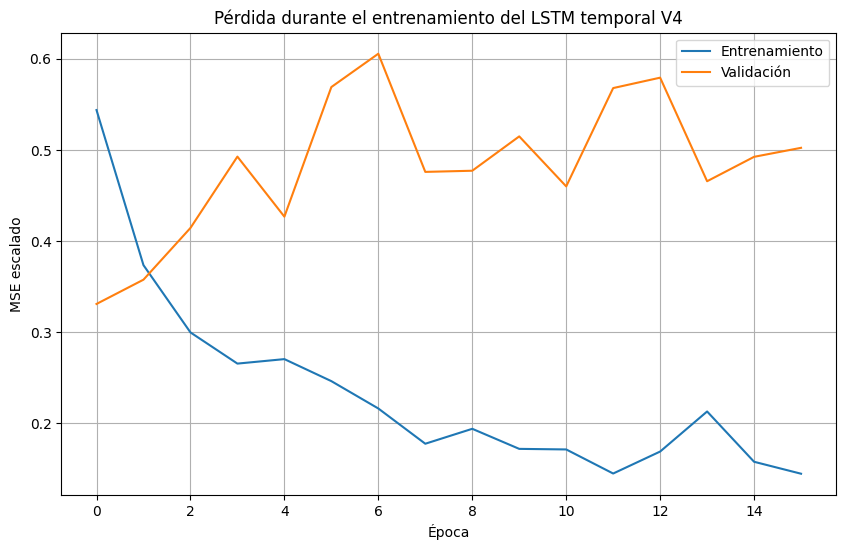

In [207]:
import matplotlib.pyplot as plt
# CURVA DE APRENDIZAJE — LSTM V4
plt.figure(figsize=(10, 6))

plt.plot(
    history_v4.history["loss"],
    label="Entrenamiento"
)

plt.plot(
    history_v4.history["val_loss"],
    label="Validación"
)

plt.xlabel("Época")
plt.ylabel("MSE escalado")
plt.title("Pérdida durante el entrenamiento del LSTM temporal V4")

plt.grid(True)
plt.legend()

plt.show()

In [208]:

# PREDICCIONES — VALIDACIÓN

y_val_pred_scaled_v4 = model_v4.predict(
    X_val_v4,
    verbose=0
).ravel()

y_val_real_scaled_v4 = y_val_v4.numpy().ravel()

print("PREDICCIONES LSTM V4")

print("\nShape predicciones:",
      y_val_pred_scaled_v4.shape)

print("\nPREDICCIONES ESCALADAS")
print("Mínimo:", y_val_pred_scaled_v4.min())
print("Máximo:", y_val_pred_scaled_v4.max())
print("Media :", y_val_pred_scaled_v4.mean())
print("Std   :", y_val_pred_scaled_v4.std())

print("\nOBJETIVO VALIDACIÓN ESCALADO")
print("Mínimo:", y_val_real_scaled_v4.min())
print("Máximo:", y_val_real_scaled_v4.max())
print("Media :", y_val_real_scaled_v4.mean())
print("Std   :", y_val_real_scaled_v4.std())

print("\nPRIMERAS 20")
print("-" * 60)

for i in range(min(20, len(y_val_pred_scaled_v4))):
    print(
        f"{i:3d} | "
        f"Real: {y_val_real_scaled_v4[i]:8.4f} | "
        f"Pred: {y_val_pred_scaled_v4[i]:8.4f}"
    )

PREDICCIONES LSTM V4

Shape predicciones: (623,)

PREDICCIONES ESCALADAS
Mínimo: -0.93583417
Máximo: 1.4878467
Media : -0.047020774
Std   : 0.5754061

OBJETIVO VALIDACIÓN ESCALADO
Mínimo: -1.1810718
Máximo: 0.38525814
Media : -0.37655392
Std   : 0.61951977

PRIMERAS 20
------------------------------------------------------------
  0 | Real:  -0.9893 | Pred:   0.0902
  1 | Real:  -0.9893 | Pred:  -0.0202
  2 | Real:  -0.9893 | Pred:  -0.3934
  3 | Real:  -0.9893 | Pred:  -0.5413
  4 | Real:  -0.9893 | Pred:  -0.5801
  5 | Real:  -0.9893 | Pred:  -0.4232
  6 | Real:  -0.9893 | Pred:   0.1788
  7 | Real:  -0.9893 | Pred:   0.3583
  8 | Real:  -0.9893 | Pred:   0.1114
  9 | Real:  -0.9893 | Pred:   0.3247
 10 | Real:  -0.9893 | Pred:  -0.1283
 11 | Real:  -0.9893 | Pred:  -0.1624
 12 | Real:  -0.9893 | Pred:  -0.0355
 13 | Real:  -0.9893 | Pred:  -0.0964
 14 | Real:  -0.9893 | Pred:  -0.3150
 15 | Real:  -0.9893 | Pred:  -0.2366
 16 | Real:  -0.9893 | Pred:  -0.2050
 17 | Real:  -0.9893 | 

In [209]:
print("VERIFICACIÓN FINAL DE VUELOS EN CADA CONJUNTO")


# Buscar automáticamente posibles arrays de IDs
for nombre in [
    "flight_ids_train_temporal",
    "flight_ids_val_temporal",
    "flight_ids_test_temporal",
    "flight_ids_temporal"
]:
    if nombre in globals():
        obj = globals()[nombre]
        print(f"\n{nombre}")
        print("Tipo:", type(obj))
        print("Shape:", np.shape(obj))

        try:
            print("Vuelos únicos:", len(np.unique(obj)))
            print(np.unique(obj))
        except:
            pass

VERIFICACIÓN FINAL DE VUELOS EN CADA CONJUNTO

flight_ids_temporal
Tipo: <class 'numpy.ndarray'>
Shape: (3591,)
Vuelos únicos: 48
['10_standardized' '11_standardized' '12_standardized' '13_standardized'
 '14_standardized' '15_standardized' '16_standardized' '17_standardized'
 '18_standardized' '19_standardized' '1_standardized' '20_standardized'
 '21_standardized' '22_standardized' '23_standardized' '24_standardized'
 '25_standardized' '26_standardized' '27_standardized' '28_standardized'
 '29_standardized' '2_standardized' '30_standardized' '31_standardized'
 '32_standardized' '33_standardized' '34_standardized' '35_standardized'
 '36_standardized' '37_standardized' '38_standardized' '39_standardized'
 '3_standardized' '4_standardized' '5_standardized' '6_standardized'
 '7_standardized' '8_standardized' '9_standardized'
 'e1_replicated_failure_standardized' 'flightsketch1_standardized'
 'flightsketch2_standardized' 'flightsketch3_standardized'
 'flightsketch4_standardized' 'flightsket

In [210]:

print("COMPROBACIÓN DE SOLAPAMIENTO ENTRE VUELOS")

if (
    "flight_ids_train_temporal" in globals()
    and "flight_ids_val_temporal" in globals()
    and "flight_ids_test_temporal" in globals()
):

    train_flights = set(np.unique(flight_ids_train_temporal))
    val_flights   = set(np.unique(flight_ids_val_temporal))
    test_flights  = set(np.unique(flight_ids_test_temporal))

    print("TRAIN:", len(train_flights))
    print("VAL  :", len(val_flights))
    print("TEST :", len(test_flights))

    print("\nSolapamiento TRAIN-VAL:")
    print(train_flights.intersection(val_flights))

    print("\nSolapamiento TRAIN-TEST:")
    print(train_flights.intersection(test_flights))

    print("\nSolapamiento VAL-TEST:")
    print(val_flights.intersection(test_flights))

    print("\nTOTAL DE VUELOS:")
    print(len(train_flights | val_flights | test_flights))

else:
    print("No se encontraron los arrays de IDs separados.")
    print("Necesitamos localizar cómo se guardaron los IDs.")

COMPROBACIÓN DE SOLAPAMIENTO ENTRE VUELOS
No se encontraron los arrays de IDs separados.
Necesitamos localizar cómo se guardaron los IDs.
